In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pulp
#for davis dataset 
#rabi=pd.read_csv(r"E:\network restructurong\data_set_new\crop\correct_crop_dacnet\Rabi_fertilizer_data_merged_dacnet_2009_2017_farmer_cost_davis_waer.csv")#davis data 
#for davis 
#kharif=pd.read_csv(r"E:\network restructurong\data_set_new\crop\correct_crop_dacnet\kharif_fertilizer_data_merged_dacnet_2009_2017_farmer_cost_davis_waer.csv")

#adding water in using hoestra data 
kharif=pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\kharif_waterdemand.csv")
rabi=pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\rabi_waterdemand.csv")
CoP= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\cost_of_production.csv")
bnf_applied= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\bnf\bnf_app.csv")

# Convert 'State' and 'Crop' column values to lowercase
CoP['State'] = CoP['State'].str.strip().str.lower()
CoP['Crop'] = CoP['Crop'].str.strip().str.lower()

# Now, the 'State' and 'Crop' columns in CoP DataFrame have all their values in lowercase
# Rename the columns in CoP to match kharif DataFrame for a consistent merge
CoP_renamed = CoP.rename(columns={"Crop": "crop", "State": "state", "CostofProduction_rs_Quintal": "Cost_of_Production_rs_Quintal"})


In [2]:
# Perform the merge
rabi = pd.merge(rabi, CoP_renamed, how='left', on=['state', 'Year', 'crop'])


In [49]:
rabi

,state,district,Year,Season,crop,Area (Hectare),Production (Tonnes),Yield (Tonnes/Hectare),N_applied(kg/ha),P_applied(kg/ha),...,atm_depo,BNF_kg_per_hec,fn2o,fno3,Manure (N_kg/ha),Manure (P_kg/ha),net_N_applied(kg/ha),net_P_applied(kg/ha),n_removed_rate,p_removed_rate
0,andaman and nicobar,NaN,2009,Rabi,maize,163.00,405.00,2.48,NaN,NaN,...,0.00,24.21,0.04,0.54,NaN,NaN,NaN,NaN,0.01,0.00
1,andaman and nicobar,nicobars,2010,Rabi,maize,3.84,18.22,4.74,NaN,NaN,...,0.00,27.26,0.04,0.54,NaN,NaN,NaN,NaN,0.01,0.00
2,andaman and nicobar,nicobars,2011,Rabi,maize,4.00,2.70,0.68,NaN,NaN,...,0.00,27.86,0.04,0.54,NaN,NaN,NaN,NaN,0.01,0.00
3,andaman and nicobar,nicobars,2013,Rabi,maize,9.70,5.10,0.53,NaN,NaN,...,0.00,29.21,0.04,0.54,NaN,NaN,NaN,NaN,0.01,0.00
4,andaman and nicobar,nicobars,2014,Rabi,maize,0.60,5.50,9.17,NaN,NaN,...,0.00,28.45,0.04,0.54,NaN,NaN,NaN,NaN,0.01,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16555,west bengal,puruliya,2018,Rabi,rice,378.00,"1,144.00",3.03,45.33,20.73,...,2.36,31.61,0.04,0.53,13.89,5.56,93.19,26.29,0.01,0.00
16556,west bengal,purulia,2018,Rabi,wheat,833.00,"2,114.00",2.54,60.74,44.12,...,2.36,31.61,0.04,0.53,9.97,3.99,104.68,48.11,0.02,0.00
16557,west bengal,purulia,2019,Rabi,maize,295.00,835.00,2.83,NaN,NaN,...,2.36,30.01,0.04,0.53,NaN,NaN,NaN,NaN,0.01,0.00
16558,west bengal,puruliya,2019,Rabi,rice,544.00,"1,644.00",3.02,47.69,20.61,...,2.36,30.01,0.04,0.53,16.20,6.48,96.26,27.09,0.01,0.00


In [3]:
import pandas as pd

# Sample data to illustrate the process. The actual data is not shown due to the format of the question.
# These dictionaries represent the mapping from atm['State'] to kharif['state'] based on the provided examples.
state_name_mapping = {
    'Andaman and Nicobar': 'andaman and nicobar',
    'Andhra Pradesh': 'andhra pradesh',
    'Arunachal Pradesh': 'arunachal pradesh',
    'Assam': 'assam',
    'Bihar': 'bihar',
    'Chandigarh': 'chandigarh',
    'Chhattisgarh': 'chhattisgarh',
    'Dadra and Nagar Haveli': 'dadra and nagar haveli',
    'Daman and Diu': 'the dadra and nagar haveli and daman and diu', # Assuming both to be mapped to the single entry in kharif
    'Delhi': 'delhi', # Not present in the provided kharif states list, but added for completeness
    'Goa': 'goa', # Not present in the provided list, but added for completeness
    'Gujarat': 'gujarat',
    'Haryana': 'haryana',
    'Himachal Pradesh': 'himachal pradesh',
    'Jammu and Kashmir': 'jammu and kashmir',
    'Jharkhand': 'jharkhand',
    'Karnataka': 'karnataka',
    'Kerala': 'kerala',
    'Lakshadweep': 'lakshadweep', # Not present, but added for completeness
    'Madhya Pradesh': 'madhya pradesh',
    'Maharashtra': 'maharashtra',
    'Manipur': 'manipur',
    'Meghalaya': 'meghalaya',
    'Mizoram': 'mizoram',
    'Nagaland': 'nagaland',
    'Orissa': 'odisha',
    'Puducherry': 'puducherry',
    'Punjab': 'punjab',
    'Rajasthan': 'rajasthan',
    'Sikkim': 'sikkim',
    'Tamil Nadu': 'tamil nadu',
    'Telangana': 'telangana',
    'Tripura': 'tripura',
    'Uttar Pradesh': 'uttar pradesh',
    'Uttaranchal': 'uttarakhand', # Mapped to 'uttarakhand' as per provided list
    'West Bengal': 'west bengal',
}

# Assume atm_df and kharif_df are the DataFrames for the 'atm' and 'kharif' datasets, respectively.
# This code will update the 'State' column in atm_df to match the 'state' values in kharif_df.

# Example atm_df DataFrame creation
# This is a placeholder and should be replaced with the actual atm DataFrame in practice.
atm_df= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\atmospheric_depo_isimip_2a.csv")   # kg/ha

# Update 'State' in atm_df to match 'state' in kharif_df using the mapping
atm_df['State'] = atm_df['State'].map(state_name_mapping)
# Renaming 'State' in atm_df to 'state' to match kharif_df column name for a consistent merge
atm_df.rename(columns={'State': 'state'}, inplace=True)
# Assuming kharif_df exists, the merge operation would look like this:
# merged_df = pd.merge(kharif_df, atm_df, left_on='state', right_on='State')

# Displaying the updated atm_df for verification
atm_df


# Performing the merge based on 'state' and 'Year'
rabi = pd.merge(rabi, atm_df, on=['state', 'Year'], how='left')
rabi = pd.merge(rabi, bnf_applied, on=[ 'Year'], how='left')


In [4]:
#coeff from image mmodel 
import pandas as pd 
image_coeff= pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\trial_analysis\image_coeff.csv")
image_coeff.rename(columns={'fN2O[% of Nsurplus]': 'fn2o', 'fNO3_leaching_to_GW[% of Nsurplus]': 'fno3'}, inplace=True)
image_coeff['State'] = image_coeff['State'].str.lower().str.strip()
image_coeff.rename(columns={'fN2O[% of Nsurplus]': 'fn2o', 'fNO3_leaching_to_GW[% of Nsurplus]': 'fno3'}, inplace=True)
image_coeff['fn2o'] = image_coeff['fn2o'] / 100    # as the value provided is in percentage 
image_coeff['fno3'] = image_coeff['fno3'] / 100

#image_coeff.rename(columns={'State':'state'}, inplace=True)
# Create a mapping dictionary from the abbreviated state names to the full state names
state_mapping = {
     'the dadra and nagar haveli and daman and diu':'dadra and nagar haveli',
    'andaman and nicobar islands':'andaman and nicobar'
}

# Use the 'replace' method to update the 'State' column in cwc_crop
image_coeff['State'] = image_coeff['State'].replace(state_mapping)
image_coeff.rename(columns={'State': 'state'}, inplace=True)


rabi = pd.merge(rabi, image_coeff, on=[ 'state'], how='left')

In [5]:

del kharif['Unnamed: 0']
del rabi['Unnamed: 0']
#manure nitrogen and P 
kharif['Manure (N_kg/ha)']=kharif['Manure (kg/ha)']*.005   #  https://agritech.tnau.ac.in/org_farm/orgfarm_manure.html
kharif['Manure (P_kg/ha)']=kharif['Manure (kg/ha)']*.002

rabi['Manure (N_kg/ha)']=rabi['Manure (kg/ha)']*.005
rabi['Manure (P_kg/ha)']=rabi['Manure (kg/ha)']*.002
#decadal scale maximum area  in of a rabi crop in a district 
rabi_max=pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\data_set_new\crop\rabi_max.csv")


# Ensure columns are numeric
rabi['N_applied(kg/ha)'] = pd.to_numeric(rabi['N_applied(kg/ha)'], errors='coerce')
rabi['Manure (N_kg/ha)'] = pd.to_numeric(rabi['Manure (N_kg/ha)'], errors='coerce')
rabi['P_applied(kg/ha)'] = pd.to_numeric(rabi['P_applied(kg/ha)'], errors='coerce')
rabi['Manure (P_kg/ha)'] = pd.to_numeric(rabi['Manure (P_kg/ha)'], errors='coerce')
rabi['Manure (N_kg/ha)'] = pd.to_numeric(rabi['Manure (N_kg/ha)'], errors='coerce')
rabi['CWR m3/ha'] = pd.to_numeric(rabi['CWR m3/ha'], errors='coerce')
rabi['CWU green m3/ha'] = pd.to_numeric(rabi['CWU green m3/ha'], errors='coerce')
rabi['CWU blue m3/ha'] = pd.to_numeric(rabi['CWU blue m3/ha'], errors='coerce')
# Replace 0 with np.nan using np.where
rabi['N_applied(kg/ha)'] = np.where(rabi['N_applied(kg/ha)'] == 0, np.nan, rabi['N_applied(kg/ha)'])
rabi['Manure (N_kg/ha)'] = np.where(rabi['Manure (N_kg/ha)'] == 0, np.nan, rabi['Manure (N_kg/ha)'])
rabi['P_applied(kg/ha)'] = np.where(rabi['P_applied(kg/ha)'] == 0, np.nan, rabi['P_applied(kg/ha)'])
rabi['Manure (P_kg/ha)'] = np.where(rabi['Manure (P_kg/ha)'] == 0, np.nan, rabi['Manure (P_kg/ha)'])
rabi['CWR m3/ha']  = np.where(rabi['CWR m3/ha'] == 0, np.nan, rabi['CWR m3/ha'])
rabi['CWU green m3/ha'] = np.where(rabi['CWU green m3/ha'] == 0, np.nan, rabi['CWU green m3/ha'])
rabi['CWU blue m3/ha'] = np.where(rabi['CWU blue m3/ha'] == 0, np.nan, rabi['CWU blue m3/ha'])

#calculating n app rate 
#calculating n app rate 
#kharif['net_N_applied(kg/ha)']=kharif['N_applied(kg/ha)']+kharif['Manure (N_kg/ha)'] + kharif['atm_depo'] +kharif['BNF_kg_per_hec'] 

#kharif['net_P_applied(kg/ha)']=kharif['P_applied(kg/ha)']+kharif['Manure (P_kg/ha)'] 

#calculating n app rate 
rabi['net_N_applied(kg/ha)']=rabi['N_applied(kg/ha)']+rabi['Manure (N_kg/ha)'] + rabi['atm_depo'] +rabi['BNF_kg_per_hec'] 
rabi['net_P_applied(kg/ha)']=rabi['P_applied(kg/ha)']+rabi['Manure (P_kg/ha)']


In [6]:
# Selecting the columns needed for the calculation
columns_of_interest = [
    'state', 'district', 'crop', 'N_applied(kg/ha)', 'P_applied(kg/ha)', 
    'K_applied(kg/ha)', 'Manure (kg/ha)', 'calorie_per_100g', 'MSP_RsperQntl', 
    'CostofCultivation_rs_ha','CWR m3/ha', 'CWR_y', 'CWU green_y', 'CWU blue_y','CWR m3/ha',	'CWU green m3/ha',	'CWU blue m3/ha'
]

# Replacing infinite values with NaNs in these columns
for col in columns_of_interest:
    rabi[col].replace([float('inf'), float('-inf')], pd.NA, inplace=True)

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2621698038.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rabi[col].replace([float('inf'), float('-inf')], pd.NA, inplace=True)


In [7]:
#takeb from https://link.springer.com/article/10.1007/bf03187117    
#Surface N balances and reactive N loss to the environment from global intensive agricultural production systems for the period 1970–2030

# Define the nitrogen content dictionary (as provided previously)  # value in kg per kg product
#crop_nitrogen_content = {
#    'rice': .013,
#   'wheat': .019,
#    'jowar': .015,
#    'bajra': .015,
#    'maize': .014,
#    'ragi': .015,
#    'barley': .017
#}
#https://www.fao.org/faostat/en/#data/ESB
crop_nitrogen_content = {
    'rice': .0129,
    'jowar': .0146,   # SORGHUM
    'bajra': .0204,
    'maize': .0124,
    'ragi': .0204
    ,'wheat':.0209
    #,'barley':.018
}
# Create the n_removed column by multiplying PRODUCTION (kg) by nitrogen content
rabi['n_removed_rate'] = rabi.apply(lambda row:crop_nitrogen_content.get(row['crop'], 0), axis=1)

crop_phosphorous_content = {
    'rice': .0028,
    'jowar': .0045,   # SORGHUM
    'bajra': .0042,
    'maize': .0034,
    'ragi': .0042
    ,'wheat':.0042
   # ,'barley':.0032
    
}
# Create the n_removed column by multiplying PRODUCTION (kg) by nitrogen content
rabi['n_removed_rate'] = rabi.apply(lambda row:crop_nitrogen_content.get(row['crop'], 0), axis=1)

# Create the p_removed column by multiplying PRODUCTION (kg) by nitrogen content
rabi['p_removed_rate'] = rabi.apply(lambda row:crop_phosphorous_content.get(row['crop'], 0), axis=1)




In [8]:
#getting year specific data 
rabi_2017 = rabi[rabi['Year'].isin([2017])]
# Calculate the crop-specific average values for each nutrient
avg_nutrients = rabi_2017.groupby('crop')[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']].transform('mean')

# Fill NaN values in kharif with the crop-specific average values
rabi_2017[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']] = rabi_2017[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']].fillna(avg_nutrients)

avg_wat=rabi_2017.groupby(['state','crop'])[['CWR m3/ha', 'CWU green m3/ha','CWU blue m3/ha']].transform('mean')
rabi_2017[['CWR m3/ha', 'CWU green m3/ha','CWU blue m3/ha']] = rabi_2017[['CWR m3/ha', 'CWU green m3/ha','CWU blue m3/ha']].fillna(avg_wat)


C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\3859357323.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rabi_2017[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']] = rabi_2017[['N_applied(kg/ha)', 'P_applied(kg/ha)', 'K_applied(kg/ha)', 'Manure (kg/ha)','Cost_of_Production_rs_Quintal']].fillna(avg_nutrients)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\3859357323.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rabi_2017[['C

In [9]:
# Assuming rabi_2017 is your DataFrame
rabi_2017['Manure (N_kg/ha)'].fillna(0, inplace=True)
rabi_2017['Manure (P_kg/ha)'].fillna(0, inplace=True)

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2949772799.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  rabi_2017['Manure (N_kg/ha)'].fillna(0, inplace=True)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2949772799.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rabi_2017['Manure (N_kg/ha)'].fillna(0, inplace=True)
C:\User

In [10]:
#calculating n app rate 
#calculating n app rate 
rabi_2017['net_N_applied(kg/ha)']=rabi_2017['N_applied(kg/ha)']+rabi_2017['Manure (N_kg/ha)'] + rabi_2017['atm_depo'] +rabi_2017['BNF_kg_per_hec'] 
rabi_2017['net_P_applied(kg/ha)']=rabi_2017['P_applied(kg/ha)']+rabi_2017['Manure (P_kg/ha)']


C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2943216237.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rabi_2017['net_N_applied(kg/ha)']=rabi_2017['N_applied(kg/ha)']+rabi_2017['Manure (N_kg/ha)'] + rabi_2017['atm_depo'] +rabi_2017['BNF_kg_per_hec']
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2943216237.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rabi_2017['net_P_applied(kg/ha)']=rabi_2017['P_applied(kg/ha)']+rabi_2017['Manure (P_kg/ha)']


In [11]:
#finding historical area 
# Grouping the data by state, district, and crop and summing the area
historical_cereal_area = rabi.groupby(['state', 'district', 'crop'])['Area (Hectare)'].mean()

# Convert the grouped data to a dictionary
historical_cereal_area_dict = historical_cereal_area.to_dict()

In [12]:
#historiccally maximum area 
# Grouping the data by state and district and summing the area to find the maximum historical area
total_historical_area_district = rabi.groupby(['state', 'district','Year'])['Area (Hectare)'].sum()
max_historical_area_district = rabi.groupby(['state', 'district'])['Area (Hectare)'].mean()

# Convert the grouped data to a dictionary
max_historical_area_district_dict = max_historical_area_district.to_dict()

# Display the first few elements of the dictionary to verify
list(max_historical_area_district_dict.items())[:5]


[(('andaman and nicobar', 'nicobars'), 3.728),
 (('andaman and nicobar', 'north and middle andaman'), 59.58200000000001),
 (('andaman and nicobar', 'south andamans'), 44.492000000000004),
 (('andhra pradesh', 'adilabad'), 9256.736842105263),
 (('andhra pradesh', 'anantapur'), 4664.706896551724)]

In [39]:
df = rabi_2017
#del df['Unnamed: 0']
# Renaming the column
df.rename(columns={'district': 'District'}, inplace=True)
df.rename(columns={'state': 'State'}, inplace=True)
df.rename(columns={'crop': 'Crop'}, inplace=True)


#finding maximum area 
rabi_max.rename(columns={'district': 'District'}, inplace=True)
rabi_max.rename(columns={'state': 'State'}, inplace=True)
rabi_max.rename(columns={'crop': 'Crop'}, inplace=True)
rabi_max['Crop'] = rabi_max['Crop'].str.lower().str.strip()




 #  only rabi crop 
# Step 1: Filter the DataFrame
selected_crops = ['bajra', 'jowar', 'ragi', 'rice'
                  ,'maize','wheat'
                  ]
df = df[df['Crop'].isin(selected_crops)]
rabi_max = rabi_max[rabi_max['Crop'].isin(selected_crops)]


# Step 2: Create a dictionary for maximum area constraints
max_area_constraints = rabi_max.set_index(['State','District', 'Crop'])['Area (Hectare)'].to_dict()

# Convert to lowercase and strip whitespace
df['District'] = df['District'].str.lower().str.strip()
df['State'] = df['State'].str.lower().str.strip()
df['Crop'] = df['Crop'].str.lower().str.strip()

#fillin nan value in applied n with national avg 
#filling the nan values in the n application rate with state and crop avg value 
# Compute the average for 'N_applied(kg/ha)' grouped by 'State' and 'Crop'
avg_N_applied = df.groupby(['Crop'])['net_N_applied(kg/ha)'].transform('mean')
global_avg=rabi.groupby(['crop'])['net_N_applied(kg/ha)'].transform('mean')
# Replace NaN values in 'net_N_applied(kg/ha)' with the computed average
df['net_N_applied(kg/ha)'].fillna(avg_N_applied, inplace=True)
if df['net_N_applied(kg/ha)'].isnull().any():
    df['net_N_applied(kg/ha)'].fillna(global_avg, inplace=True)  # Fallback to global average if needed

#fillin nan value in applied p with national avg 
avg_P_applied = df.groupby(['Crop'])['net_P_applied(kg/ha)'].transform('mean')
global_avg_P=rabi.groupby(['crop'])['net_P_applied(kg/ha)'].transform('mean')
# Replace NaN values in 'net_P_applied(kg/ha)' with the computed average
df['net_P_applied(kg/ha)'].fillna(avg_P_applied, inplace=True)
if df['net_P_applied(kg/ha)'].isnull().any():
    df['net_P_applied(kg/ha)'].fillna(global_avg_P, inplace=True)  # Fallback to global average if needed


#filling cost of cultivattion with avg vallue 
# Step 1
avg_cost_cult = df.groupby('Crop')['Cost_of_Production_rs_Quintal'].transform('mean')

# Step 2
df['Cost_of_Production_rs_Quintal'].fillna(avg_cost_cult, inplace=True)

# Step 3
if df['Cost_of_Production_rs_Quintal'].isnull().any():
    print("NaN values present after local crop average fill")

    # Step 4
    global_avg_cost_cult = rabi.groupby('crop')['Cost_of_Production_rs_Quintal'].transform('mean')

    # Step 5
    df['Cost_of_Production_rs_Quintal'].fillna(global_avg_cost_cult, inplace=True)

# Step 6
if df['Cost_of_Production_rs_Quintal'].isnull().any():
    print("NaN values present after global average fill")
else:
    print("All NaN values filled")
    
# replace all occurrences of -1 in the 'AREA (1000 ha)' and 'PRODUCTION (1000 tons)' columns with zero   which signifies missing values 
df['Area (Hectare)'] = df['Area (Hectare)'].replace(-1, 0)
df['Production (Tonnes)'] = df['Production (Tonnes)'].replace(-1, 0)
df['YIELD (Kg per ha)'] = 1000*df['Yield (Tonnes/Hectare)'].replace(-1, 0)
#compute avg water requiremment 
avg_applied_CWR = df.groupby(['Crop'])['CWR m3/ha'].transform('mean')
global_avg_cwr=rabi.groupby(['crop'])['CWR m3/ha'].transform('mean')
# Replace NaN values in 'CWR m3/ha' with the computed average
df['CWR m3/ha'].fillna(avg_applied_CWR, inplace=True)
if df['CWR m3/ha'].isnull().any():
    df['CWR m3/ha'].fillna(global_avg_cwr, inplace=True)  # Fallback to global average if needed

df['CWR m3/ha'] = df['CWR m3/ha'].fillna(0)

#setting yield 
yield_data = df.set_index(['State','District', 'Crop'])['YIELD (Kg per ha)'].to_dict()

# Calorie data (converted to per tonne)  
# in kcal 
#calorie_per_100g = {
    #'ragi': 328,
    #'bajra': 361,
    #'rice': 345,
    #'jowar': 349,
    #'wheat': 346,
    #'maize': 342
    #,'barley': 352
#}
calorie_per_100g = {
    'ragi': 321,
    'bajra': 348,
    'rice': 356,
    'jowar': 334,
    'wheat': 322
    ,'maize': 342
    #,'barley': 352
}
#calorie_per_tonne = {cereal: value * 10000 for cereal, value in calorie_per_100g.items()}   # in 1000TONNE   chnage  calorie_per_tonneto  calorie_per_kg
calorie_per_kg = {cereal: value * 10 for cereal, value in calorie_per_100g.items()}   # in kg   chnage  calorie_per_tonneto  calorie_per_kg


#aghg Per-Area Total (Mg CO2e ha-1) 2017
# Dictionary mapping crop names to their corresponding values   
crop_co2e = { 
    'bajra': 0.098603856,
    'ragi': 0.098603856,
    'rice': 8.213913103,
    'jowar': 0.154967254,
    'wheat': 0.729809876,
    'maize': 0.889859651
}

AGHG_per_ha = {cereal: value for cereal, value in crop_co2e.items()}   # in (Mg CO2e ha-1)


# Calculate Total Calorie Supply for Each District-Cereal Combination
#df['Calorie Supply (per tonne)'] = df['Crop'].map(calorie_per_tonne)
df['Calorie Supply (per KG)'] = df['Crop'].map(calorie_per_kg)   # crop wise calorie mapping
#total aghg produced in india 
df['AGHG_produced (per ha)'] = df['Crop'].map(AGHG_per_ha)   # crop wise aghg mapping (Mg CO2e ha-1) 2017

df['Total Calorie Supply'] =1000*df['Production (Tonnes)'] * df['Calorie Supply (per KG)']   # IN KG
df['Total Farmer Cost'] = 10*df['Production (Tonnes)'] * df['Cost_of_Production_rs_Quintal']  # as area is in 1000ha    

#calculate total selling price for each district-cereal combination
#data['MSP Supply (per tonne)'] = data['Crop'].map(msp_per_tonne)
df['Total MSP Supply'] = 10*df['Production (Tonnes)'] * df['MSP_RsperQntl']  # tonne to qut factor is 10 10000 to convert 1000ton
df['Total initial profit']=df['Total MSP Supply'] - df['Total Farmer Cost']
#data.head(4)

# Extract Data into Dictionaries
districts = df['District'].unique().tolist()
states = df['State'].unique().tolist()
cereals = df['Crop'].unique().tolist()


#current_area = df.set_index('District')['AREA (1000 ha)'].to_dict()  # this was wrong as it was giving only last district area 
current_area = df.groupby(['State','District'])['Area (Hectare)'].sum().to_dict() # this gives sum of all the area of all crops in the district

#nitrogen_rate = data.groupby('Crop')['N_applied(kg/ha)'].mean().to_dict()   #need to change 
#in this synthetic + manure + atm+bnf applied value is to be used   application rate 
nitrogen_rate = df.set_index(['State','District', 'Crop'])['net_N_applied(kg/ha)'].to_dict()
nitrogen_removal_rate_perkg=  df.set_index(['State','District', 'Crop'])['n_removed_rate'].to_dict()
#NITROGEN LEACH 
nitrogen_leach_rate_perkg=df.set_index(['State','District', 'Crop'])['fno3'].to_dict()   # this is to be multipkied by the surplus value that we are getting for each disstrict as we are assuming the leaching is same 
#nitrogen emission 
nitrogen_emission_rate_perkg=df.set_index(['State','District', 'Crop'])['fn2o'].to_dict()
#AGHG_rate                                       #Mg CO2e ha-1
#phosphorous_rate = data.groupby('Crop')['N_applied(kg/ha)'].mean().to_dict()   #need to change 
#in this synthetic + manure + atm+bnf applied value is to be used   application rate 
P_rate = df.set_index(['State','District', 'Crop'])['net_P_applied(kg/ha)'].to_dict()
P_removal_rate_perkg=  df.set_index(['State','District', 'Crop'])['p_removed_rate'].to_dict()

#water requirement 
water_rate = df.set_index(['State','District', 'Crop'])['CWR m3/ha'].to_dict()

#calories_per_area = data.set_index(['District', 'Crop'])['Calorie Supply (per tonne)'].to_dict()   # need tocheck as it should be calorie per unit production
calories_per_prod = df.set_index(['State','District', 'Crop'])['Calorie Supply (per KG)'].to_dict()   # this is to be multiplieed by the production value 
#aghg
AGHG_per_ha = df.set_index(['State','District', 'Crop'])['AGHG_produced (per ha)'].to_dict()   # this is to be multiplieed by the area  # crop wise aghg mapping (Mg CO2e ha-1) 2017 

district_to_state = df.set_index('District')['State'].to_dict()

cost_per_area = df.set_index(['State','District', 'Crop'])['Cost_of_Production_rs_Quintal'].to_dict()   # in ha   # cosyt of cultivation

MSP_per_prod = df.set_index(['State','District', 'Crop'])['MSP_RsperQntl'].to_dict()   # in quintal
current_cereal_area = {}
for index, row in df.iterrows():
    current_cereal_area[row['State'],row['District'], row['Crop']] = row['Area (Hectare)']    # in ha

current_cereal_prod = {}
for index, row in df.iterrows():
    current_cereal_prod[row['State'],row['District'], row['Crop']] = row['Production (Tonnes)']


#current applied nitrogen value 
original_nitrogen_values = [current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_nitrogen_values)  # This will give the individual nitrogen applications for each district-cereal combo
original_N_surplus_value=[(current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total n applied 
original_total_nitrogen = sum(original_nitrogen_values) # nitrogen applied 
original_N_surplus=  sum(original_N_surplus_value)  # surplus kg
#nitrogen leach 
origina_N_leach_value=[nitrogen_leach_rate_perkg.get((s,d, c), 0)*((current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))  for s in states for d in districts for c in cereals]
original_N_leach=  sum(origina_N_leach_value)  # leach kg

original_N_emission_value= [nitrogen_emission_rate_perkg.get((s,d, c), 0)*((current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))  for s in states for d in districts for c in cereals]
original_N_emission=  sum(original_N_emission_value)  # leach kg
print("Original Total Nitrogen Applied kg:", original_total_nitrogen)
print("Original Total Nitrogen Surplus generated kg:", original_N_surplus)
print("Original Total Nitrogen leach generated kg:", original_N_leach)
print("Original Total Nitrogen emission generated kg:", original_N_emission)


#current applied phosphorous value 
original_P_values = [current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_p_values)  # This will give the individual p applications for each district-cereal combo
original_P_surplus_value=[(current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*P_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total p applied 
original_total_P = sum(original_P_values) # nitrogen applied 
original_P_surplus=  sum(original_P_surplus_value)  # surplus kg

print("Original Total phosphorus Applied kg:", original_total_P)
print("Original Total phosphorus Surplus generated kg:", original_P_surplus)


#originall water required
original_water_values = [current_cereal_area.get((s,d, c), 0) * water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_water = sum(original_water_values)
print("Original Total water Applied:", original_total_water)
prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    # Decision Variables
x = pulp.LpVariable.dicts("Area (Hectare)", (states,districts,cereals), 0, None, pulp.LpContinuous)  # this is in ha
# Objective Function - Adjusted to use district & crop specific nitrogen rates
#for n applied 
#prob += pulp.lpSum([x[s][d][c]* nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals])  # as area is in ha
#fornsurplus
prob += pulp.lpSum([x[s][d][c]*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0))) for s in states for d in districts for c in cereals])   # for minimizing n surplus
#for p surplus 
#prob += pulp.lpSum([x[s][d][c]*(P_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * P_removal_rate_perkg.get((s, d, c), 0))) for s in states for d in districts for c in cereals])   # for minimizing n surplus
#minimizing water demand 
#prob += pulp.lpSum([x[s][d][c]* water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals])  # as area is in ha

#print(prob)
# Constraints
# Cropped Area Constraints    net area in the district within a state should remain same 
for s in states:
    for d in districts:
        prob += pulp.lpSum([x[s][d][c] for c in cereals]) == current_area.get((s,d), 0)

# adding historical area as a contrain where maximum achivable area is that od historically present 

# Step 3: Add the new constraints to your model
for s in states:
    for d in districts:
        for c in cereals:
            if c in max_area_constraints:
                prob += x[s][d][c] <= max_area_constraints[c]

# Existing Cereal Constraints   
# Replacement should happen when only crop is present 
#for s in states:
#    for d in districts:
#        for c in cereals:
#            if current_cereal_area.get((s,d,c), 0) == 0:
#                prob += x[s][d][c] == 0
#The constraint x[s][d][c] == 0: This is forcing the decision variable to be zero if the specific cereal was not originally planted in that district of that state, essentially saying 
#"if we didn't plant this cereal here before, we're not going to start now."

#instead of this we have to use historically present area 
for s in states:
    for d in districts:
        for c in cereals:
            if historical_cereal_area.get((s, d, c), 0) == 0:
                prob += x[s][d][c] == 0



# State Calorie Supply Constraints - State-wise calorie generated should remain the same
initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()
for s in states:
    prob += pulp.lpSum(
        [x[s][d][c] * yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0) 
         for d in districts for c in cereals]
    ) >= initial_state_calories[s]


# Adding  farmers msp selling profit  Constraint
#initial_state_msp = df.groupby('State')['Total MSP Supply'].sum().to_dict()    # this is cost of cultivation of crop 
#for s in states:
#    prob += pulp.lpSum([x[s][d][c]* yield_data.get((s, d, c), 0)* MSP_per_prod.get((s,d, c), 0) for d in districts if district_to_state.get(d) == s for c in cereals]) >= initial_state_msp[s]


# Adding  Farmer Cost of production  Constraint
#initial_state_costs = df.groupby('State')['Total Farmer Cost'].sum().to_dict()    # this is cost of cultivation of crop 
#for s in states:
#    prob += pulp.lpSum([x[s][d][c]* cost_per_area.get((s,d, c), 0) for d in districts if district_to_state.get(d) == s for c in cereals]) <= initial_state_costs[s]

# Adding  Farmer profit of production  Constraint
#df['Total initial profit']
#initial_state_profit = df.groupby('State')['Total initial profit'].sum().to_dict()    # this is cost of cultivation of crop 
#for s in states:
#    prob += pulp.lpSum([(x[s][d][c]* yield_data.get((s, d, c), 0)* 0.01*MSP_per_prod.get((s,d, c), 0))-(x[s][d][c]*yield_data.get((s, d, c), 0)* 0.01* cost_per_area.get((s,d, c), 0)) for d in districts if district_to_state.get(d) == s for c in cereals]) >= initial_state_profit[s]


#adding constrain that original maize should not increase 
#initial_maize_area_by_state = df[df['Crop'] == 'maize'].groupby('State')['Area (Hectare)'].sum().to_dict()

#for s in states:
#    prob += pulp.lpSum([x[s][d]['maize'] for d in districts if district_to_state.get(d) == s]) == initial_maize_area_by_state.get(s, 0)

  

# Set the path for glpsol in GLPK_CMD
#solver = pulp.GLPK_CMD(path=r"C:\Users\\shekh\\anaconda3\\envs\\opt_agri\\Library\\bin\\glpsol.exe")
#"C:\Users\shekh\anaconda3\envs\opt_agri\Library\bin\glpsol.exe"
#solver = pulp.GLPK_CMD()
#solver = pulp.GLPK_CMD()
#prob.solve(solver)
# Set the path for glpsol in GLPK_CMD
#solver = pulp.GLPK_CMD(path=r"C:\Users\\shekh\\anaconda3\\envs\\opt_agri\\Library\\bin\\glpsol.exe")
#"C:\Users\shekh\anaconda3\envs\opt_agri\Library\bin\glpsol.exe"
solver = pulp.PULP_CBC_CMD()
#solver = pulp.GLPK_CMD()
prob.solve(solver)
#optimized_total_nitrogen = pulp.value(prob.objective)
optimized_total_nitrogen = sum((pulp.value(x[s][d][c]))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen surplus", optimized_total_nitrogen)
print("Status:", pulp.LpStatus[prob.status])

#optimal_water_saving = pulp.value(prob.objective)

#print("optimized_total_nitrogen", optimized_total_nitrogen)
#print("optimized_total_water", optimal_water_saving)

print("Status:", pulp.LpStatus[prob.status])
#percentage change
#percentage_change_w = ((original_total_water-optimal_water_saving) / original_total_water) * 100
#print("% reduction in net water applied :", percentage_change_w)


#current applied nitrogen value 
original_nitrogen_values = [current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_nitrogen_values)  # This will give the individual nitrogen applications for each district-cereal combo
original_N_surplus_value=[(current_cereal_area.get((s,d, c), 0) * nitrogen_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total n applied 
original_total_nitrogen = sum(original_nitrogen_values) # nitrogen applied 
original_N_surplus=  sum(original_N_surplus_value)  # surplus kg

print("Original Total Nitrogen Applied kg:", original_total_nitrogen)
print("Original Total Nitrogen Surplus generated kg:", original_N_surplus)


#current applied phosphorous value 
original_P_values = [current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print(original_p_values)  # This will give the individual p applications for each district-cereal combo
original_P_surplus_value=[(current_cereal_area.get((s,d, c), 0) * P_rate.get((s,d, c), 0)) - (1000*current_cereal_prod.get((s,d, c), 0)*P_removal_rate_perkg.get((s,d, c), 0))  for s in states for d in districts for c in cereals]
#total p applied 
original_total_P = sum(original_P_values) # nitrogen applied 
original_P_surplus=  sum(original_P_surplus_value)  # surplus kg

print("Original Total phosphorus Applied kg:", original_total_P)
print("Original Total phosphorus Surplus generated kg:", original_P_surplus)


#originall water required
original_water_values = [current_cereal_area.get((s,d, c), 0) * water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_water = sum(original_water_values)
print("Original Total water Applied:", original_total_water)

#optimized water 
optimal_water_saving= [(pulp.value(x[s][d][c]))* water_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals] 
optimal_water= sum(optimal_water_saving)
#originall Calorie generated in kg 
original_calorie_values = [1000*current_cereal_prod.get((s,d, c), 0) * calories_per_prod.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#total calorie applied 
original_total_calorie = sum(original_calorie_values)
print(" original_total_calorie:", original_total_calorie)



#originall msp  generated in kg 
original_msp_values = [10*current_cereal_prod.get((s,d, c), 0) * MSP_per_prod.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_msp = sum(original_msp_values)
print(" original_total_msp:", original_total_msp)


#total profit
original_profit_values = [((10*current_cereal_prod.get((s,d, c), 0) * MSP_per_prod.get((s,d, c), 0))-(10*current_cereal_area.get((s,d, c), 0) * cost_per_area.get((s,d, c), 0))) for s in states for d in districts for c in cereals]  #area is in ha
original_total_profit = sum(original_profit_values)
print(" original_total_profit:", original_total_profit)



#optimized valued 
#FOR NITROGEN 
optimized_total_nitrogen_surplus = sum((pulp.value(x[s][d][c]))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen surplus", optimized_total_nitrogen_surplus)
print("Status:", pulp.LpStatus[prob.status])

#for nitrogen applied 
optimized_total_P_F_applied=sum((pulp.value(x[s][d][c])) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals)

#for Phosphorus surplus 
optimized_total_P_surplus =sum((pulp.value(x[s][d][c]))*(P_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*P_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total Phosphorus surplus", optimized_total_P_surplus)
print("Status:", pulp.LpStatus[prob.status])


#percentage change for p surplus
percentage_change_p = ((original_P_surplus-optimized_total_P_surplus) / original_P_surplus) * 100
print("% reduction in net p surplus :", percentage_change_p)

#percentage change for p applied
# p fert_applied
optimized_total_P_F_applied=sum((pulp.value(x[s][d][c])) * P_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals)
print("optimized total Phosphorus applied", optimized_total_P_F_applied)
percentage_change_p_applied = ((original_total_P-optimized_total_P_F_applied) / original_total_P) * 100
print("% reduction in net p applied :", percentage_change_p_applied)

#percentage change nitrogen surplus 
percentage_change_N = ((original_N_surplus-optimized_total_nitrogen_surplus) / original_N_surplus) * 100
print("% reduction in net nitrogen surplus :", percentage_change_N)

#percentage change for N applied
# N fert_applied
optimized_total_N_F_applied=sum((pulp.value(x[s][d][c])) * nitrogen_rate.get((s,d, c), 0) for s in states for d in districts for c in cereals)
print("optimized total Nitrogen applied", optimized_total_N_F_applied)
percentage_change_N_applied = ((original_total_nitrogen-optimized_total_N_F_applied) / original_total_nitrogen) * 100
print("% reduction in net N applied :", percentage_change_N_applied)


#optiized n leach 
optimized_total_nitrogen_leach = sum((pulp.value(x[s][d][c]))*(nitrogen_leach_rate_perkg.get((s, d, c), 0))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen leach", optimized_total_nitrogen_leach)

#optimized n emission 
optimized_total_nitrogen_emission = sum((pulp.value(x[s][d][c]))*(nitrogen_emission_rate_perkg.get((s, d, c), 0))*(nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0)*nitrogen_removal_rate_perkg.get((s,d, c), 0)))
                       for s in states for d in districts for c in cereals)
print("optimized total nitrogen emission", optimized_total_nitrogen_emission)

#percentage change for leach and emission  
#percentage change leach 
percentage_change_N_leach = ((original_N_leach-optimized_total_nitrogen_leach) / original_N_leach) * 100
print("% reduction in N leach generated Kg :", percentage_change_N_leach)

#percentage change emission 
percentage_change_N_emission = ((original_N_emission-optimized_total_nitrogen_emission) / original_N_emission) * 100
print("% reduction in N emission generated Kg :", percentage_change_N_emission)



#percentage change for water 
#percentage change
percentage_change_w = ((original_total_water-optimal_water) / original_total_water) * 100
print("% reduction in net water applied :", percentage_change_w)
#percentage change for calorie 
optimal_calorie = sum((pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
percentage_change_calorie = ((original_total_calorie-optimal_calorie) / original_total_calorie) * 100

print("% reduction in Total calorie produced:", percentage_change_calorie)





#percentage change for msp 
optimal_msp = sum((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
percentage_change_msp = ((original_total_msp-optimal_msp) / original_total_msp) * 100

print("% reduction in Total MSP produced:", percentage_change_msp)

print("optimal  Total MSP produced:", optimal_msp)


#originall msp  generated in kg 
original_cop_values = [10*current_cereal_prod.get((s,d, c), 0) * cost_per_area.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
#print total water required 
#total n applied 
original_total_cop = sum(original_cop_values)
print(" original_total_cop:", original_total_cop)
#coc
optimal_coc =sum((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
print("optimal Total cost of cultivation produced:", optimal_coc)

#total profit
original_profit_values = [((10*current_cereal_prod.get((s,d, c), 0) * MSP_per_prod.get((s,d, c), 0))-(10*current_cereal_prod.get((s,d, c), 0) * cost_per_area.get((s,d, c), 0))) for s in states for d in districts for c in cereals]  #area is in ha
original_total_profit = sum(original_profit_values)
print(" original_total_profit:", original_total_profit)



#percentage change for msp 
optimal_profit = sum(((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0))-(0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0) for s in states for d in districts for c in cereals)

print(" Total optimal profit produced:", optimal_profit)

percentage_change_profit = ((original_total_profit-optimal_profit)/original_total_profit)* 100

print("% reduction in Total profit produced:", percentage_change_profit)

#  AGHG    # crop wise aghg mapping (Mg CO2e ha-1) 2017
original_AGHG_values = [current_cereal_area.get((s,d, c), 0) * AGHG_per_ha.get((s,d, c), 0) for s in states for d in districts for c in cereals]  #area is in ha
original_total_AGHG_ = sum(original_AGHG_values)
print(" original_total_AGHG_(Mg CO2e):", original_total_AGHG_)
optimal_AGHG = sum((pulp.value(x[s][d][c])) * AGHG_per_ha.get((s, d, c), 0)
                       for s in states for d in districts for c in cereals)
print(" OOptimal_total_AGHG_(Mg CO2e):", optimal_AGHG)

percentage_change_AGHG = ((original_total_AGHG_-optimal_AGHG) / original_total_AGHG_) * 100

print("% reduction in Total AGHG produced:", percentage_change_AGHG)

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\489541661.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'district': 'District'}, inplace=True)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\489541661.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'state': 'State'}, inplace=True)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\489541661.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-ver

All NaN values filled
Original Total Nitrogen Applied kg: 5698688422.457742
Original Total Nitrogen Surplus generated kg: 2973158456.2557416
Original Total Nitrogen leach generated kg: 694712008.0456555
Original Total Nitrogen emission generated kg: 103722360.61934204
Original Total phosphorus Applied kg: 2116092844.3201163
Original Total phosphorus Surplus generated kg: 1550559011.9881208
Original Total water Applied: 106481488741.27083
optimized total nitrogen surplus 2478364820.9130645
Status: Optimal
Status: Optimal
Original Total Nitrogen Applied kg: 5698688422.457742
Original Total Nitrogen Surplus generated kg: 2973158456.2557416
Original Total phosphorus Applied kg: 2116092844.3201163
Original Total phosphorus Surplus generated kg: 1550559011.9881208
Original Total water Applied: 106481488741.27083
 original_total_calorie: 464430120906600.0
 original_total_msp: 2398554609280.0
 original_total_profit: 1832168422788.8086
optimized total nitrogen surplus 2478364820.9130645
Status:

In [34]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Extract Optimization Results
# Assuming x is a dictionary with keys as (state, district, crop) and values as optimized area
results = []
for s in states:
    for d in districts:
        for c in cereals:
            original_area=current_cereal_area.get((s, d, c), 0)
            original_yield=yield_data.get((s, d, c), 0)
            original_N_applied=original_area* nitrogen_rate.get((s, d, c), 0)
            original_P_applied = original_area * P_rate.get((s, d, c), 0)
            original_production_kg = original_area * yield_data.get((s, d, c), 0)
            original_calorie = original_production_kg * calories_per_prod.get((s, d, c), 0)
            original_profit = (original_production_kg * MSP_per_prod.get((s, d, c), 0) * 0.01) - (original_production_kg * 0.01 * cost_per_area.get((s, d, c), 0))
            original_AGHG = original_area * AGHG_per_ha.get((s, d, c), 0)
            original_water= original_area*water_rate.get((s,d, c), 0)
            original_N_surplus=(original_area * nitrogen_rate.get((s, d, c), 0))-(original_production_kg*nitrogen_removal_rate_perkg.get((s, d, c), 0))
            original_P_surplus= (original_area * P_rate.get((s, d, c), 0))-(original_production_kg*P_removal_rate_perkg.get((s, d, c), 0))
            original_N_leach= original_N_surplus*nitrogen_leach_rate_perkg.get((s, d, c), 0)
            original_N_emission= original_N_surplus*nitrogen_emission_rate_perkg.get((s, d, c), 0)
            optimized_area = x[s][d][c].varValue
            optimized_N_applied = optimized_area * nitrogen_rate.get((s, d, c), 0)
            optimized_P_applied = optimized_area * P_rate.get((s, d, c), 0)
            optimized_production_kg = optimized_area * yield_data.get((s, d, c), 0)
            optimized_calorie = optimized_production_kg * calories_per_prod.get((s, d, c), 0)
            optimized_profit = (((0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0))-(0.01*pulp.value(x[s][d][c]))*yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0)) 
            optimized_AGHG = optimized_area * AGHG_per_ha.get((s, d, c), 0)
            optimized_water= optimized_area*water_rate.get((s,d, c), 0)
            optimized_N_surplus=(optimized_area * nitrogen_rate.get((s, d, c), 0))-(optimized_production_kg*nitrogen_removal_rate_perkg.get((s, d, c), 0))
            optimized_P_surplus= (optimized_area * P_rate.get((s, d, c), 0))-(optimized_production_kg*P_removal_rate_perkg.get((s, d, c), 0))
            optimized_N_leach= optimized_N_surplus*nitrogen_leach_rate_perkg.get((s, d, c), 0)
            optimized_N_emission= optimized_N_surplus*nitrogen_emission_rate_perkg.get((s, d, c), 0)           
            results.append({
                            'State': s,
                            'District': d,
                            'Crop': c,
                            'Optimized Area (Hectare)': optimized_area,
                            'Original Area (Hectare)': original_area,
                            'Original yield': original_yield,
                            'Optimized production kg': optimized_production_kg,
                            'Original production kg': original_production_kg,
                            'Optimized Total N Applied': optimized_N_applied,
                            'Original Total N Applied': original_N_applied,
                            'Optimized Total P Applied': optimized_P_applied,
                            'Original Total P Applied': original_P_applied,
                            'Optimized Total N surplus': optimized_N_surplus,
                            'Original Total N surplus': original_N_surplus,
                            'Optimized Total P surplus': optimized_P_surplus,
                            'Original Total P surplus': original_P_surplus,
                            'Optimized Calorie': optimized_calorie,
                            'Original Calorie': original_calorie,
                            'Optimized AGHG': optimized_AGHG,
                            'Original AGHG': original_AGHG,
                            'Optimized N_leach': optimized_N_leach,
                            'Original N_leach': original_N_leach,
                            'Optimized N_emission': optimized_N_emission,
                            'Original N_emission': original_N_emission,
                            'Optimized water': optimized_water,
                            'Original water': original_water,
                            'Optimized profit': optimized_profit,
                            'Original profit': original_profit
                        })
results_df = pd.DataFrame(results)


# Step 1: Prepare the Original Data
df['District'] = df['District'].str.lower().str.strip()
df['State'] = df['State'].str.lower().str.strip()
df['Crop'] = df['Crop'].str.lower().str.strip()

# Step 2: Merge the Data
# Merging based on District, State, and Crop
merged_results_df = results_df.merge(df[['State', 'District', 'Crop', 'Area (Hectare)']], 
                                     on=['State', 'District', 'Crop'], 
                                     how='left')

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2069322890.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['District'] = df['District'].str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2069322890.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['State'] = df['State'].str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2069322890.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

In [40]:
import pandas as pd
import pulp

# -------------------------------------------------------
# Load AGHG factor data (per‑kg CO2e for residue burning)
# -------------------------------------------------------
aghg_df = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv")

# Constants
N2O_GWP = 273  # IPCC AR6: 1 kg N2O = 273 kg CO2-eq
# If your fn2o yields N2O-N, set USE_N2O_N=True to apply 44/28 conversion.
USE_N2O_N = False
MOLAR_RATIO_N2O = 44/28

# ------------------------------
# Normalize state keys to lower
# ------------------------------
aghg_df["state_key"] = aghg_df["State"].astype(str).str.strip().str.lower()

# Build lookup tables (keys are lowercased state names)
rice_burn_CO2eq_perkg    = dict(zip(aghg_df["state_key"], aghg_df["Rice_CO2eq_perkg"]))
wheat_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Wheat_CO2eq_perkg"]))
maize_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Maize_CO2eq_perkg"]))
millets_burn_CO2eq_perkg = dict(zip(aghg_df["state_key"], aghg_df["Millets_CO2eq_perkg"]))
# CH4 from flooded rice (already CO2e per ha)
rice_ch4_per_ha          = dict(zip(aghg_df["state_key"], aghg_df["rice_ch4_co2_eq_per_ha"]))

# ------------------------------------------------
# Reusable per-record AGHG calculator (s,d,c,area)
# ------------------------------------------------
def aghg_from_area(s, d, c, area_ha):
    """
    Returns total AGHG (kg CO2e) for a single (state, district, crop, area_ha)
    using:
      - Residue burning: per-kg CO2e * production_kg (production_kg = area_ha * yield_kg_per_ha)
      - Rice CH4: per-ha CO2e * area_ha
      - Soils N2O: fn2o * N_surplus * (optional 44/28) * GWP
    Relies on your existing dicts: yield_data, nitrogen_rate, nitrogen_removal_rate_perkg,
    nitrogen_emission_rate_perkg, etc.
    """
    if not area_ha or area_ha <= 0:
        return 0.0

    c_key = str(c).strip().lower()
    s_key = str(s).strip().lower()

    # Yield and production (kg)
    yld_kg_ha = float(yield_data.get((s, d, c), 0.0))
    prod_kg   = float(area_ha) * yld_kg_ha

    total = 0.0

    # --- Residue burning + rice CH4 ---
    if c_key == "rice":
        total += prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
        total += float(area_ha) * float(rice_ch4_per_ha.get(s_key, 0.0))
    elif c_key == "wheat":
        total += prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
    elif c_key == "maize":
        total += prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
    elif c_key in ["bajra", "jowar", "ragi"]:
        total += prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))
    # else: other crops contribute only via soils N2O (below), unless you add more factors.

    # --- Soils N2O from N surplus ---
    n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))               # kg N/ha
    n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0)) # kg N/kg grain
    fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))# fraction of N surplus

    n_surplus = float(area_ha) * n_appl - prod_kg * n_rem_perkg  # kg N
    n2o_from_nsur = n_surplus * fn2o
    if USE_N2O_N:
        n2o_from_nsur *= MOLAR_RATIO_N2O  # convert N2O-N to N2O

    total += n2o_from_nsur * N2O_GWP  # kg CO2e

    return total

# ------------------------------------------------------
# Aggregated breakdown (original vs optimized) — optional
# ------------------------------------------------------
def calculate_aghg_breakdown(area_dict):
    """
    Aggregates components across area_dict and returns (total_aghg, components_dict).
    Uses the same logic as aghg_from_area but keeps component sums.
    """
    components = {
        "Rice_burning_CO2eq":   0.0,
        "Rice_CH4_CO2eq":       0.0,
        "Wheat_burning_CO2eq":  0.0,
        "Maize_burning_CO2eq":  0.0,
        "Millets_burning_CO2eq":0.0,
        "Soils_N2O_CO2eq":      0.0
    }
    total_aghg = 0.0
    n2o_term = 0.0

    for (s, d, c), area in area_dict.items():
        area = float(area or 0.0)
        if area <= 0:
            continue

        c_key = str(c).strip().lower()
        s_key = str(s).strip().lower()

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))  # kg/ha
        prod_kg   = area * yld_kg_ha                       # kg grain

        # residue burning + rice CH4
        if c_key == "rice":
            rice_burn = prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
            rice_ch4  = area    * float(rice_ch4_per_ha.get(s_key, 0.0))
            components["Rice_burning_CO2eq"] += rice_burn
            components["Rice_CH4_CO2eq"]     += rice_ch4
            total_aghg += rice_burn + rice_ch4

        elif c_key == "wheat":
            wheat_burn = prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
            components["Wheat_burning_CO2eq"] += wheat_burn
            total_aghg += wheat_burn

        elif c_key == "maize":
            maize_burn = prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
            components["Maize_burning_CO2eq"] += maize_burn
            total_aghg += maize_burn

        elif c_key in ["bajra", "jowar", "ragi"]:
            millets_burn = prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))
            components["Millets_burning_CO2eq"] += millets_burn
            total_aghg += millets_burn

        # soils N2O (from N surplus)
        n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))
        n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0))
        fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

        n_surplus = area * n_appl - prod_kg * n_rem_perkg
        n2o_from_nsur = n_surplus * fn2o
        if USE_N2O_N:
            n2o_from_nsur *= MOLAR_RATIO_N2O

        n2o_term += n2o_from_nsur

    soils_n2o_co2eq = n2o_term * N2O_GWP
    components["Soils_N2O_CO2eq"] += soils_n2o_co2eq
    total_aghg += soils_n2o_co2eq

    components["Total"] = total_aghg
    return total_aghg, components

# =====================
# Build area dicts
# =====================
# 1) ORIGINAL (current_cereal_area already defined upstream)
orig_total,  orig_comp  = calculate_aghg_breakdown(current_cereal_area)

# 2) OPTIMIZED (pull areas from decision vars x)
optimized_area_dict = {
    (s, d, c): float(pulp.value(x[s][d][c]) or 0.0)
    for s in states for d in districts for c in cereals
}
opt_total,   opt_comp   = calculate_aghg_breakdown(optimized_area_dict)

# ==========================
# Component comparison table
# ==========================
rows = list(orig_comp.keys())  # includes "Total" last
df_comp = pd.DataFrame({
    "Component": rows,
    "Original_kgCO2e": [orig_comp[k] for k in rows],
    "Optimized_kgCO2e":[opt_comp[k]  for k in rows]
})
df_comp["Reduction_kgCO2e"] = df_comp["Original_kgCO2e"] - df_comp["Optimized_kgCO2e"]
df_comp["Reduction_%"] = df_comp.apply(
    lambda r: 100.0 * r["Reduction_kgCO2e"] / r["Original_kgCO2e"] if r["Original_kgCO2e"] else 0.0,
    axis=1
)
df_comp["Share_of_Orig_%"] = df_comp.apply(
    lambda r: 100.0 * r["Original_kgCO2e"] / orig_total if orig_total else 0.0,
    axis=1
)

pd.options.display.float_format = '{:,.2f}'.format
print(df_comp)

print("\n✅ Totals match check")
print("Original total (from breakdown):", orig_total)
print("Optimized total (from breakdown):", opt_total)

# ========================================================
# Build per-(state,district,crop) results with UPDATED AGHG
# ========================================================
results = []
for s in states:
    for d in districts:
        for c in cereals:
            # ORIGINAL metrics
            original_area = float(current_cereal_area.get((s, d, c), 0.0))
            original_yield = float(yield_data.get((s, d, c), 0.0))
            original_production_kg = original_area * original_yield
            original_N_applied = original_area * float(nitrogen_rate.get((s, d, c), 0.0))
            original_P_applied = original_area * float(P_rate.get((s, d, c), 0.0))
            original_calorie = original_production_kg * float(calories_per_prod.get((s, d, c), 0.0))
            original_profit = (original_production_kg * float(MSP_per_prod.get((s, d, c), 0.0)) * 0.01) - \
                              (original_production_kg * 0.01 * float(cost_per_area.get((s, d, c), 0.0)))
            # UPDATED AGHG (not AGHG_per_ha)
            original_AGHG = aghg_from_area(s, d, c, original_area)

            original_water = original_area * float(water_rate.get((s, d, c), 0.0))
            original_N_surplus = original_N_applied - (original_production_kg * float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0)))
            original_P_surplus = original_P_applied - (original_production_kg * float(P_removal_rate_perkg.get((s, d, c), 0.0)))
            original_N_leach = original_N_surplus * float(nitrogen_leach_rate_perkg.get((s, d, c), 0.0))
            original_N_emission = original_N_surplus * float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

            # OPTIMIZED metrics
            optimized_area = float(pulp.value(x[s][d][c]) or 0.0)
            optimized_yield = float(yield_data.get((s, d, c), 0.0))
            optimized_production_kg = optimized_area * optimized_yield
            optimized_N_applied = optimized_area * float(nitrogen_rate.get((s, d, c), 0.0))
            optimized_P_applied = optimized_area * float(P_rate.get((s, d, c), 0.0))
            optimized_calorie = optimized_production_kg * float(calories_per_prod.get((s, d, c), 0.0))
            optimized_profit = ((0.01 * optimized_area) * optimized_yield * float(MSP_per_prod.get((s, d, c), 0.0))) - \
                               ((0.01 * optimized_area) * optimized_yield * float(cost_per_area.get((s, d, c), 0.0)))
            # UPDATED AGHG (not AGHG_per_ha)
            optimized_AGHG = aghg_from_area(s, d, c, optimized_area)

            optimized_water = optimized_area * float(water_rate.get((s, d, c), 0.0))
            optimized_N_surplus = optimized_N_applied - (optimized_production_kg * float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0)))
            optimized_P_surplus = optimized_P_applied - (optimized_production_kg * float(P_removal_rate_perkg.get((s, d, c), 0.0)))
            optimized_N_leach = optimized_N_surplus * float(nitrogen_leach_rate_perkg.get((s, d, c), 0.0))
            optimized_N_emission = optimized_N_surplus * float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

            results.append({
                'State': str(s).strip().lower(),
                'District': str(d).strip().lower(),
                'Crop': str(c).strip().lower(),

                'Optimized Area (Hectare)': optimized_area,
                'Original Area (Hectare)': original_area,

                'Original yield': original_yield,
                'Optimized production kg': optimized_production_kg,
                'Original production kg': original_production_kg,

                'Optimized Total N Applied': optimized_N_applied,
                'Original Total N Applied': original_N_applied,
                'Optimized Total P Applied': optimized_P_applied,
                'Original Total P Applied': original_P_applied,

                'Optimized Total N surplus': optimized_N_surplus,
                'Original Total N surplus': original_N_surplus,
                'Optimized Total P surplus': optimized_P_surplus,
                'Original Total P surplus': original_P_surplus,

                'Optimized Calorie': optimized_calorie,
                'Original Calorie': original_calorie,

                # UPDATED AGHG fields:
                'Optimized AGHG': optimized_AGHG,
                'Original AGHG': original_AGHG,

                'Optimized N_leach': optimized_N_leach,
                'Original N_leach': original_N_leach,
                'Optimized N_emission': optimized_N_emission,
                'Original N_emission': original_N_emission,

                'Optimized water': optimized_water,
                'Original water': original_water,

                'Optimized profit': optimized_profit,
                'Original profit': original_profit
            })

results_df = pd.DataFrame(results)

# ============================================
# Prepare your joining Geo/attributes dataframe
# ============================================
# Ensure df has these columns; standardize to lower for a clean join
df['District'] = df['District'].astype(str).str.lower().str.strip()
df['State']    = df['State'].astype(str).str.lower().str.strip()
df['Crop']     = df['Crop'].astype(str).str.lower().str.strip()

# =======================
# Merge (include new AGHG)
# =======================
merged_results_df = results_df.merge(
    df[['State', 'District', 'Crop', 'Area (Hectare)']],
    on=['State', 'District', 'Crop'],
    how='left'
)

# Optional: sanity check totals from row-wise sums vs. aggregated breakdown
calc_orig_total = results_df['Original AGHG'].sum()
calc_opt_total  = results_df['Optimized AGHG'].sum()
print("\n🔎 Sanity check (row-sum vs aggregated):")
print("Original AGHG — row sum:", calc_orig_total, " | aggregated:", orig_total)
print("Optimized AGHG — row sum:", calc_opt_total, " | aggregated:", opt_total)


               Component   Original_kgCO2e  Optimized_kgCO2e  \
0     Rice_burning_CO2eq  3,139,909,480.35  1,908,942,980.47   
1         Rice_CH4_CO2eq  8,725,471,551.25  9,218,681,425.71   
2    Wheat_burning_CO2eq 44,069,545,829.60 40,924,068,886.00   
3    Maize_burning_CO2eq  1,704,967,223.50  4,586,249,439.19   
4  Millets_burning_CO2eq    872,107,578.05  1,441,940,980.82   
5        Soils_N2O_CO2eq 28,316,204,449.08 23,235,652,501.98   
6                  Total 86,828,206,111.82 81,315,536,214.19   

   Reduction_kgCO2e  Reduction_%  Share_of_Orig_%  
0  1,230,966,499.88        39.20             3.62  
1   -493,209,874.47        -5.65            10.05  
2  3,145,476,943.59         7.14            50.75  
3 -2,881,282,215.69      -168.99             1.96  
4   -569,833,402.77       -65.34             1.00  
5  5,080,551,947.10        17.94            32.61  
6  5,512,669,897.63         6.35           100.00  

✅ Totals match check
Original total (from breakdown): 86828206111.8224

C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2890488085.py:280: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['District'] = df['District'].astype(str).str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2890488085.py:281: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['State']    = df['State'].astype(str).str.lower().str.strip()
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2890488085.py:282: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice 

In [41]:
# Group by District and calculate the percentage changes as instructed.
grouped_data = merged_results_df.groupby(['State']).sum().reset_index()  # Group by district and sum up all numeric columns.

# Calculating the percentage changes as described
grouped_data['% change in water'] = 100 * (grouped_data['Original water'] - grouped_data['Optimized water']) / grouped_data['Original water']
grouped_data['% change in nitrogen'] = 100 * (grouped_data['Original Total N surplus'] - grouped_data['Optimized Total N surplus']) / grouped_data['Original Total N surplus']
grouped_data['% change in Phosphorus'] = 100 * (grouped_data['Original Total P surplus'] - grouped_data['Optimized Total P surplus']) / grouped_data['Original Total P surplus']
grouped_data['% change in nitrogen applied'] = 100 * (grouped_data['Original Total N Applied'] - grouped_data['Optimized Total N Applied']) / grouped_data['Original Total N Applied']
grouped_data['% change in Phosphorus applied'] = 100 * (grouped_data['Original Total P Applied'] - grouped_data['Optimized Total P Applied']) / grouped_data['Original Total P Applied']
grouped_data['% change in calorie'] = 100 * (grouped_data['Original Calorie'] - grouped_data['Optimized Calorie']) / grouped_data['Original Calorie']
grouped_data['% change in profit'] = 100 * (grouped_data['Original profit'] - grouped_data['Optimized profit']) / grouped_data['Original profit']
grouped_data['% change in AGHG'] = 100 * (grouped_data['Original AGHG'] - grouped_data['Optimized AGHG']) / grouped_data['Original AGHG']
grouped_data['% change in N emission'] = 100 * (grouped_data['Original N_emission'] - grouped_data['Optimized N_emission']) / grouped_data['Original N_emission']
grouped_data['% change in N leaach'] = 100 * (grouped_data['Original N_leach'] - grouped_data['Optimized N_leach']) / grouped_data['Original N_leach']

#state_level
grouped_data.to_csv(r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\data\state_rabi_N.csv")

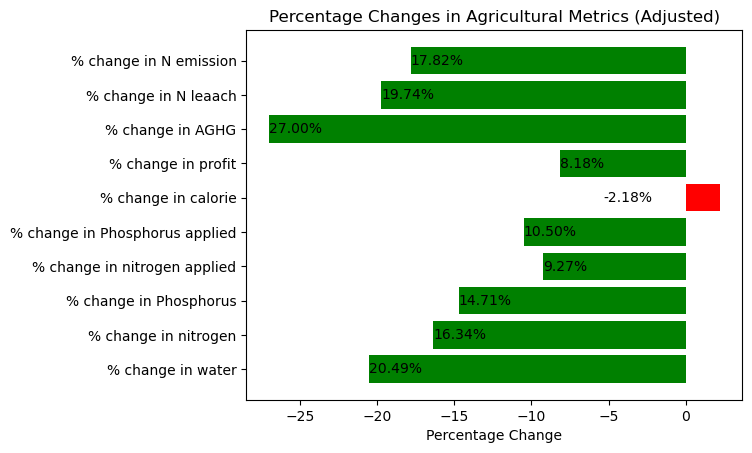

In [35]:
# Group by State and sum all numeric columns
grouped_data = merged_results_df.groupby(['State']).sum(numeric_only=True).reset_index()

# Percentage change calculations
grouped_data['% change in water'] = 100 * (grouped_data['Original water'] - grouped_data['Optimized water']) / grouped_data['Original water']
grouped_data['% change in nitrogen'] = 100 * (grouped_data['Original Total N surplus'] - grouped_data['Optimized Total N surplus']) / grouped_data['Original Total N surplus']
grouped_data['% change in Phosphorus'] = 100 * (grouped_data['Original Total P surplus'] - grouped_data['Optimized Total P surplus']) / grouped_data['Original Total P surplus']
grouped_data['% change in nitrogen applied'] = 100 * (grouped_data['Original Total N Applied'] - grouped_data['Optimized Total N Applied']) / grouped_data['Original Total N Applied']
grouped_data['% change in Phosphorus applied'] = 100 * (grouped_data['Original Total P Applied'] - grouped_data['Optimized Total P Applied']) / grouped_data['Original Total P Applied']
grouped_data['% change in calorie'] = 100 * (grouped_data['Original Calorie'] - grouped_data['Optimized Calorie']) / grouped_data['Original Calorie']
grouped_data['% change in profit'] = 100 * (grouped_data['Original profit'] - grouped_data['Optimized profit']) / grouped_data['Original profit']
grouped_data['% change in AGHG'] = 100 * (grouped_data['Original AGHG'] - grouped_data['Optimized AGHG']) / grouped_data['Original AGHG']
grouped_data['% change in N emission'] = 100 * (grouped_data['Original N_emission'] - grouped_data['Optimized N_emission']) / grouped_data['Original N_emission']
grouped_data['% change in N leaach'] = 100 * (grouped_data['Original N_leach'] - grouped_data['Optimized N_leach']) / grouped_data['Original N_leach']

# Total values and total percentage changes
total_data = merged_results_df.sum(numeric_only=True)
total_data['% change in water'] = 100 * (total_data['Original water'] - total_data['Optimized water']) / total_data['Original water']
total_data['% change in nitrogen'] = 100 * (total_data['Original Total N surplus'] - total_data['Optimized Total N surplus']) / total_data['Original Total N surplus']
total_data['% change in Phosphorus'] = 100 * (total_data['Original Total P surplus'] - total_data['Optimized Total P surplus']) / total_data['Original Total P surplus']
total_data['% change in nitrogen applied'] = 100 * (total_data['Original Total N Applied'] - total_data['Optimized Total N Applied']) / total_data['Original Total N Applied']
total_data['% change in Phosphorus applied'] = 100 * (total_data['Original Total P Applied'] - total_data['Optimized Total P Applied']) / total_data['Original Total P Applied']
total_data['% change in calorie'] = 100 * (total_data['Original Calorie'] - total_data['Optimized Calorie']) / total_data['Original Calorie']
total_data['% change in profit'] = 100 * (total_data['Original profit'] - total_data['Optimized profit']) / total_data['Original profit']
total_data['% change in AGHG'] = 100 * (total_data['Original AGHG'] - total_data['Optimized AGHG']) / total_data['Original AGHG']
total_data['% change in N emission'] = 100 * (total_data['Original N_emission'] - total_data['Optimized N_emission']) / total_data['Original N_emission']
total_data['% change in N leaach'] = 100 * (total_data['Original N_leach'] - total_data['Optimized N_leach']) / total_data['Original N_leach']

# Extracting the data for plotting directly from the total_data calculation results
percentage_changes = total_data[['% change in water', '% change in nitrogen', '% change in Phosphorus', 
            '% change in nitrogen applied', '% change in Phosphorus applied', 
            '% change in calorie', '% change in profit', '% change in AGHG','% change in N leaach','% change in N emission']]

# Converting Series to a dictionary for easier manipulation
percentage_changes_dict = percentage_changes.to_dict()

# Convert negative values to positive for plotting on the right side and determine color based on sign
values = [abs(value) for value in percentage_changes_dict.values()]
categories = list(percentage_changes_dict.keys())
colors = ['green' if value >= 0 else 'red' for value in percentage_changes_dict.values()]
# Adjusting the plot logic based on the new requirement:
# Positive values should be plotted on the negative side of the X-axis and vice versa.

# Determine the side of the bar based on the sign of the original value, reversing the logic
values_adjusted = [-abs(value) if value >= 0 else abs(value) for value in percentage_changes_dict.values()]

# Plotting with the adjusted logic
fig, ax = plt.subplots()
ax.barh(categories, values_adjusted, color=colors)
ax.set_xlabel('Percentage Change')
ax.set_title('Percentage Changes in Agricultural Metrics (Adjusted)')

# Annotating the bars with the actual percentage change values
for index, value in enumerate(percentage_changes_dict.values()):
    if value >= 0:
        ax.text(-value, index, f"{value:.2f}%", va='center', ha='left')
    else:
        ax.text(value, index, f"{value:.2f}%", va='center', ha='right')

plt.show()


In [50]:
#bootstrapping 

In [51]:
# ============================================
# BOOTSTRAP INTEGRATION (1000 iterations)
# Resamples N_applied and Manure N per (State,District,Crop) from 2009–2020
# ============================================

import numpy as np
import pandas as pd
import pulp
from collections import defaultdict

# ------------ CONFIG ------------
N_BOOT = 1000
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# Where to save results
OUT_DIR = r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\data"
TOTAL_OUT = OUT_DIR + r"\bootstrap_results_total.csv"
SUMMARY_OUT = OUT_DIR + r"\bootstrap_summary_total.csv"
# STATE_OUT = OUT_DIR + r"\bootstrap_results_state.csv"  # enable if you want state-level distro

# Metrics to record each iteration (total India level)
METRICS = [
    "N_surplus", "N_applied", "P_surplus", "P_applied",
    "Water", "Calories", "Profit", "AGHG", "N_leach", "N_emission",
    "Calorie_constraint_ok"
]

# ---------------------------------------------
# 1) Build bootstrap pools for 2009–2020 (S,D,C)
# ---------------------------------------------
panel_cols = ["state","district","crop","Year","N_applied(kg/ha)","Manure (N_kg/ha)"]
panel = rabi.loc[rabi["Year"].between(2009, 2020), panel_cols].copy()

# normalize keys to lower/strip to match df usage
for k in ["state","district","crop"]:
    panel[k] = panel[k].astype(str).str.lower().str.strip()

# dict: key -> arrays of historical values
pool_N = defaultdict(list)
pool_M = defaultdict(list)

for _, row in panel.iterrows():
    key = (row["state"], row["district"], row["crop"])
    nval = row["N_applied(kg/ha)"]
    mval = row["Manure (N_kg/ha)"]
    if pd.notna(nval): pool_N[key].append(float(nval))
    if pd.notna(mval): pool_M[key].append(float(mval))

# Fallback pools (state+crop) and (crop) when (S,D,C) has too few points
pool_N_state_crop = defaultdict(list)
pool_M_state_crop = defaultdict(list)
pool_N_crop = defaultdict(list)
pool_M_crop = defaultdict(list)

for _, row in panel.iterrows():
    sc = (row["state"], row["crop"])
    c  = row["crop"]
    nval = row["N_applied(kg/ha)"]
    mval = row["Manure (N_kg/ha)"]
    if pd.notna(nval):
        pool_N_state_crop[sc].append(float(nval))
        pool_N_crop[c].append(float(nval))
    if pd.notna(mval):
        pool_M_state_crop[sc].append(float(mval))
        pool_M_crop[c].append(float(mval))

def _sample_from_pools(key_sdc, key_sc, key_c):
    """Return (N_applied_sample, ManureN_sample) using hierarchical fallbacks."""
    # N_applied
    if len(pool_N[key_sdc])>0:
        n_samp = rng.choice(pool_N[key_sdc])
    elif len(pool_N_state_crop[key_sc])>0:
        n_samp = rng.choice(pool_N_state_crop[key_sc])
    elif len(pool_N_crop[key_c])>0:
        n_samp = rng.choice(pool_N_crop[key_c])
    else:
        n_samp = np.nan  # truly missing

    # Manure N
    if len(pool_M[key_sdc])>0:
        m_samp = rng.choice(pool_M[key_sdc])
    elif len(pool_M_state_crop[key_sc])>0:
        m_samp = rng.choice(pool_M_state_crop[key_sc])
    elif len(pool_M_crop[key_c])>0:
        m_samp = rng.choice(pool_M_crop[key_c])
    else:
        m_samp = 0.0  # assume zero if never observed (conservative)

    return n_samp, m_samp

# ---------------------------------------------
# 2) Helper: (re)build and solve the LP given a df_iter with updated net_N_applied
# ---------------------------------------------
def solve_once_with_df(df_iter):
    """
    df_iter is your 2017 dataframe (columns normalized) with updated:
      - N_applied(kg/ha) and Manure (N_kg/ha)
      - net_N_applied(kg/ha)
    Returns dict of total metrics at India level, and the optimized area dict.
    """
    # refresh key dicts that depend on N inputs
    nitrogen_rate_iter = df_iter.set_index(['State','District','Crop'])['net_N_applied(kg/ha)'].to_dict()
    # Keep using existing globals for other dicts:
    #  yield_data, nitrogen_removal_rate_perkg, P_rate, P_removal_rate_perkg,
    #  water_rate, calories_per_prod, MSP_per_prod, cost_per_area,
    #  nitrogen_leach_rate_perkg (fno3), nitrogen_emission_rate_perkg (fn2o)
    global nitrogen_rate
    nitrogen_rate = nitrogen_rate_iter  # so AGHG helpers see the new rates

    # LP
    prob_iter = pulp.LpProblem("OptimizeCerealArea_Bootstrap", pulp.LpMinimize)
    x_iter = pulp.LpVariable.dicts("Area (Hectare)", (states, districts, cereals), 0, None, pulp.LpContinuous)

    # Objective: minimize N surplus
    prob_iter += pulp.lpSum([
        x_iter[s][d][c] * (nitrogen_rate_iter.get((s,d,c),0.0) -
                           (yield_data.get((s,d,c),0.0) * nitrogen_removal_rate_perkg.get((s,d,c),0.0)))
        for s in states for d in districts for c in cereals
    ])

    # District area conservation
    for s in states:
        for d in districts:
            prob_iter += pulp.lpSum([x_iter[s][d][c] for c in cereals]) == current_area.get((s,d), 0.0)

    # Historical max per (S,D,C) — FIXED the keying bug
    for s in states:
        for d in districts:
            for c in cereals:
                key = (s,d,c)
                if key in max_area_constraints:
                    prob_iter += x_iter[s][d][c] <= max_area_constraints[key]

    # No new crops in districts without historical presence
    for s in states:
        for d in districts:
            for c in cereals:
                if historical_cereal_area.get((s,d,c), 0.0) == 0.0:
                    prob_iter += x_iter[s][d][c] == 0.0

    # State calorie constraints (>= baseline)
    for s in states:
        prob_iter += pulp.lpSum([
            x_iter[s][d][c] * yield_data.get((s,d,c),0.0) * calories_per_prod.get((s,d,c),0.0)
            for d in districts for c in cereals
        ]) >= initial_state_calories[s]

    status = prob_iter.solve(pulp.PULP_CBC_CMD(msg=False))
    status_ok = pulp.LpStatus[prob_iter.status] == "Optimal"

    # Build optimized area dict
    opt_area = {(s,d,c): float(pulp.value(x_iter[s][d][c]) or 0.0)
                for s in states for d in districts for c in cereals}

    # Totals (same formulas as your post-optimization block)
    # Original totals already computed above (outside) — we compare vs optimized here if needed,
    # but for bootstrap we store optimized totals (distribution), and you can compute deltas later.

    # Totals (optimized)
    # Nitrogen
    opt_N_surplus = sum(
        opt_area[(s,d,c)] * (nitrogen_rate_iter.get((s,d,c),0.0) -
                             (yield_data.get((s,d,c),0.0) * nitrogen_removal_rate_perkg.get((s,d,c),0.0)))
        for s in states for d in districts for c in cereals
    )
    opt_N_applied = sum(
        opt_area[(s,d,c)] * nitrogen_rate_iter.get((s,d,c),0.0)
        for s in states for d in districts for c in cereals
    )
    # Phosphorus (unchanged by N bootstrap, but area changes — keep for completeness)
    opt_P_surplus = sum(
        opt_area[(s,d,c)] * (P_rate.get((s,d,c),0.0) -
                             (yield_data.get((s,d,c),0.0) * P_removal_rate_perkg.get((s,d,c),0.0)))
        for s in states for d in districts for c in cereals
    )
    opt_P_applied = sum(
        opt_area[(s,d,c)] * P_rate.get((s,d,c),0.0)
        for s in states for d in districts for c in cereals
    )
    # Water
    opt_Water = sum(
        opt_area[(s,d,c)] * water_rate.get((s,d,c),0.0)
        for s in states for d in districts for c in cereals
    )
    # Calories
    opt_Cal = sum(
        opt_area[(s,d,c)] * yield_data.get((s,d,c),0.0) * calories_per_prod.get((s,d,c),0.0)
        for s in states for d in districts for c in cereals
    )
    # Profit (MSP - Cost), both in Rs; note your 0.01 factor (q/ha from kg/ha) via yield
    opt_Profit = sum(
        ((0.01 * opt_area[(s,d,c)] * yield_data.get((s,d,c),0.0) * MSP_per_prod.get((s,d,c),0.0)) -
         (0.01 * opt_area[(s,d,c)] * yield_data.get((s,d,c),0.0) * cost_per_area.get((s,d,c),0.0)))
        for s in states for d in districts for c in cereals
    )
    # AGHG (updated using aghg_from_area with new nitrogen_rate)
    _, comp = calculate_aghg_breakdown(opt_area)
    opt_AGHG = comp["Total"]

    # Leach / Emission (fractions of N surplus)
    opt_N_leach = sum(
        (nitrogen_leach_rate_perkg.get((s,d,c),0.0)) *
        (opt_area[(s,d,c)] * (nitrogen_rate_iter.get((s,d,c),0.0) -
                              (yield_data.get((s,d,c),0.0) * nitrogen_removal_rate_perkg.get((s,d,c),0.0))))
        for s in states for d in districts for c in cereals
    )
    opt_N_emis = sum(
        (nitrogen_emission_rate_perkg.get((s,d,c),0.0)) *
        (opt_area[(s,d,c)] * (nitrogen_rate_iter.get((s,d,c),0.0) -
                              (yield_data.get((s,d,c),0.0) * nitrogen_removal_rate_perkg.get((s,d,c),0.0))))
        for s in states for d in districts for c in cereals
    )

    # Sanity: calorie constraint meet?
    cal_ok = True
    for s in states:
        state_opt_cal = sum(
            opt_area[(s,d,c)] * yield_data.get((s,d,c),0.0) * calories_per_prod.get((s,d,c),0.0)
            for d in districts for c in cereals
        )
        if state_opt_cal + 1e-6 < initial_state_calories[s]:
            cal_ok = False
            break

    totals = {
        "N_surplus": opt_N_surplus,
        "N_applied": opt_N_applied,
        "P_surplus": opt_P_surplus,
        "P_applied": opt_P_applied,
        "Water": opt_Water,
        "Calories": opt_Cal,
        "Profit": opt_Profit,
        "AGHG": opt_AGHG,
        "N_leach": opt_N_leach,
        "N_emission": opt_N_emis,
        "Calorie_constraint_ok": int(cal_ok and status_ok)
    }
    return totals, opt_area

# ---------------------------------------------
# 3) Run bootstrap
# ---------------------------------------------
# Prepare a 2017 template with normalized keys and fixed columns
base_2017 = rabi_2017.copy()
base_2017.rename(columns={'state':'State','district':'District','crop':'Crop'}, inplace=True)
for k in ['State','District','Crop']:
    base_2017[k] = base_2017[k].astype(str).str.lower().str.strip()

results_total = []   # list of per-iteration totals (dicts)
# results_state = []   # enable if you want state-level distributions

for i in range(N_BOOT):
    # Start from base 2017
    df_iter = base_2017.copy()

    # Sample N_applied and Manure N per (S,D,C)
    samp_N = []
    samp_M = []
    for _, r in df_iter[['State','District','Crop']].iterrows():
        s, d, c = r['State'], r['District'], r['Crop']
        n_s, m_s = _sample_from_pools((s,d,c), (s,c), c)
        samp_N.append(n_s)
        samp_M.append(m_s)

    df_iter['N_applied(kg/ha)'] = samp_N
    df_iter['Manure (N_kg/ha)'] = samp_M

    # Fill remaining NaNs conservatively (use crop means from base_2017, then zeros)
    if df_iter['N_applied(kg/ha)'].isna().any():
        fillN = df_iter.groupby('Crop')['N_applied(kg/ha)'].transform('mean')
        df_iter['N_applied(kg/ha)'] = df_iter['N_applied(kg/ha)'].fillna(fillN).fillna(0.0)
    if df_iter['Manure (N_kg/ha)'].isna().any():
        fillM = df_iter.groupby('Crop')['Manure (N_kg/ha)'].transform('mean')
        df_iter['Manure (N_kg/ha)'] = df_iter['Manure (N_kg/ha)'].fillna(fillM).fillna(0.0)

    # Recompute net_N_applied(kg/ha) with atm_depo + BNF fixed from base
    df_iter['net_N_applied(kg/ha)'] = (
        df_iter['N_applied(kg/ha)'] + df_iter['Manure (N_kg/ha)'] +
        df_iter['atm_depo'] + df_iter['BNF_kg_per_hec']
    )

    # Solve LP and compute totals
    totals, opt_area = solve_once_with_df(df_iter)
    totals["iter"] = i+1
    results_total.append(totals)

    # # (Optional) state-level distributions
    # state_rows = []
    # for s in states:
    #     # sums per state using opt_area
    #     st_cal = sum(opt_area[(s,d,c)] * yield_data.get((s,d,c),0.0) * calories_per_prod.get((s,d,c),0.0)
    #                 for d in districts for c in cereals)
    #     st_Nsur = sum(opt_area[(s,d,c)] * (nitrogen_rate.get((s,d,c),0.0) -
    #                 (yield_data.get((s,d,c),0.0) * nitrogen_removal_rate_perkg.get((s,d,c),0.0)))
    #                 for d in districts for c in cereals)
    #     st_W = sum(opt_area[(s,d,c)] * water_rate.get((s,d,c),0.0)
    #                for d in districts for c in cereals)
    #     _, comp_st = calculate_aghg_breakdown({k: v for k,v in opt_area.items() if k[0]==s})
    #     state_rows.append({"iter": i+1, "State": s, "Calories": st_cal, "N_surplus": st_Nsur,
    #                        "Water": st_W, "AGHG": comp_st["Total"]})
    # results_state.extend(state_rows)

# ---------------------------------------------
# 4) Save distributions and compute error bars
# ---------------------------------------------
boot_df = pd.DataFrame(results_total)
boot_df.to_csv(TOTAL_OUT, index=False)

# Summary stats for total India-level metrics
summary = boot_df.drop(columns=["iter"]).agg(['mean','std','min','max']).T
summary['p2.5'] = boot_df.drop(columns=["iter"]).quantile(0.025)
summary['p97.5'] = boot_df.drop(columns=["iter"]).quantile(0.975)
summary = summary.reset_index().rename(columns={'index':'metric'})
summary.to_csv(SUMMARY_OUT, index=False)

print(f"✓ Bootstrapping complete ({N_BOOT} iters).")
print(f"Saved per-iteration totals -> {TOTAL_OUT}")
print(f"Saved summary (mean, sd, p2.5, p97.5, min, max) -> {SUMMARY_OUT}")

# # If you enabled state-level block above:
# state_df = pd.DataFrame(results_state)
# state_df.to_csv(STATE_OUT, index=False)
# print(f"Saved state-level distributions -> {STATE_OUT}")



KeyboardInterrupt



In [36]:
import pandas as pd
import pulp

# -------------------------------------------------------
# Load AGHG factor data (per‑kg CO2e for residue burning)
# -------------------------------------------------------
aghg_df = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv")

# Constants
N2O_GWP = 273  # IPCC AR6: 1 kg N2O = 273 kg CO2-eq
# If your fn2o yields N2O-N, set USE_N2O_N=True to apply 44/28 conversion.
USE_N2O_N = False
MOLAR_RATIO_N2O = 44/28

# Build lookup tables
# NOTE: These per‑kg factors are **residue burning** intensities per kg of grain
rice_burn_CO2eq_perkg    = aghg_df.set_index('State')['Rice_CO2eq_perkg'].to_dict()
wheat_burn_CO2eq_perkg   = aghg_df.set_index('State')['Wheat_CO2eq_perkg'].to_dict()
maize_burn_CO2eq_perkg   = aghg_df.set_index('State')['Maize_CO2eq_perkg'].to_dict()
millets_burn_CO2eq_perkg = aghg_df.set_index('State')['Millets_CO2eq_perkg'].to_dict()
# CH4 from flooded rice (already CO2e per ha)
rice_ch4_per_ha          = aghg_df.set_index('State')['rice_ch4_co2_eq_per_ha'].to_dict()


def calculate_aghg_breakdown(area_dict):
    """
    area_dict: {(state, district, crop): area_ha}
    Uses:
      - Residue burning: per-kg CO2e * production_kg (production_kg = area_ha * yield_kg_per_ha)
      - Rice CH4: per-ha CO2e * area_ha
      - Soils N2O: fn2o * N_surplus (with optional N2O-N→N2O) * GWP
    Returns: (total_aghg_kgCO2e, components_dict)
    """
    components = {
        "Rice_burning_CO2eq":   0.0,
        "Rice_CH4_CO2eq":       0.0,
        "Wheat_burning_CO2eq":  0.0,
        "Maize_burning_CO2eq":  0.0,
        "Millets_burning_CO2eq":0.0,
        "Soils_N2O_CO2eq":      0.0
    }
    total_aghg = 0.0

    # ---------- residue burning + rice CH4 ----------
    for (s, d, c), area in area_dict.items():
        area = float(area or 0.0)
        if area <= 0:
            continue

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))  # kg/ha
        prod_kg   = area * yld_kg_ha                       # kg grain
        rs = s.strip().lower()

        if c == 'rice':
            rice_burn = prod_kg * float(rice_burn_CO2eq_perkg.get(rs, 0.0))
            rice_ch4  = area    * float(rice_ch4_per_ha.get(rs, 0.0))
            components["Rice_burning_CO2eq"] += rice_burn
            components["Rice_CH4_CO2eq"]     += rice_ch4
            total_aghg += rice_burn + rice_ch4

        elif c == 'wheat':
            wheat_burn = prod_kg * float(wheat_burn_CO2eq_perkg.get(rs, 0.0))
            components["Wheat_burning_CO2eq"] += wheat_burn
            total_aghg += wheat_burn

        elif c == 'maize':
            maize_burn = prod_kg * float(maize_burn_CO2eq_perkg.get(rs, 0.0))
            components["Maize_burning_CO2eq"] += maize_burn
            total_aghg += maize_burn

        elif c in ['bajra', 'jowar', 'ragi']:
            millets_burn = prod_kg * float(millets_burn_CO2eq_perkg.get(rs, 0.0))
            components["Millets_burning_CO2eq"] += millets_burn
            total_aghg += millets_burn

    # ---------- soils N2O (from N surplus) ----------
    # N_surplus (kg N) = area_ha * N_applied_rate(kg/ha) - production_kg * N_removed_rate_perkg(kg N/kg grain)
    n2o_term = 0.0
    for (s, d, c), area in area_dict.items():
        area = float(area or 0.0)
        if area <= 0:
            continue

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))
        prod_kg   = area * yld_kg_ha

        n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))                 # kg N/ha
        n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0))   # kg N/kg grain
        fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))  # fraction of N surplus

        n_surplus = area * n_appl - prod_kg * n_rem_perkg  # kg N
        n2o_from_nsur = n_surplus * fn2o                   # If fn2o is N2O or N2O-N depends on your coeff.
        if USE_N2O_N:
            n2o_from_nsur *= MOLAR_RATIO_N2O  # convert N2O-N -> N2O

        n2o_term += n2o_from_nsur

    soils_n2o_co2eq = n2o_term * N2O_GWP
    components["Soils_N2O_CO2eq"] += soils_n2o_co2eq
    total_aghg += soils_n2o_co2eq

    components["Total"] = total_aghg
    return total_aghg, components


# ================
# Run both cases
# ================
# 1) ORIGINAL (current_cereal_area already defined upstream)
orig_total,  orig_comp  = calculate_aghg_breakdown(current_cereal_area)

# 2) OPTIMIZED (pull areas from decision vars x)
optimized_area_dict = {(s, d, c): (pulp.value(x[s][d][c]) or 0.0)
                       for s in states for d in districts for c in cereals}
opt_total,   opt_comp   = calculate_aghg_breakdown(optimized_area_dict)

# ==========================
# Comparison DataFrame
# ==========================
rows = list(orig_comp.keys())  # includes "Total" last
df_comp = pd.DataFrame({
    "Component": rows,
    "Original_kgCO2e": [orig_comp[k] for k in rows],
    "Optimized_kgCO2e":[opt_comp[k]  for k in rows]
})
df_comp["Reduction_kgCO2e"] = df_comp["Original_kgCO2e"] - df_comp["Optimized_kgCO2e"]
df_comp["Reduction_%"] = df_comp.apply(
    lambda r: 100.0 * r["Reduction_kgCO2e"] / r["Original_kgCO2e"] if r["Original_kgCO2e"] else 0.0,
    axis=1
)
df_comp["Share_of_Orig_%"] = df_comp.apply(
    lambda r: 100.0 * r["Original_kgCO2e"] / orig_total if orig_total else 0.0,
    axis=1
)

pd.options.display.float_format = '{:,.2f}'.format
print(df_comp)

print("\n✅ Totals match check")
print("Original total (from breakdown):", orig_total)
print("Optimized total (from breakdown):", opt_total)


               Component   Original_kgCO2e  Optimized_kgCO2e  \
0     Rice_burning_CO2eq  3,139,909,480.35  1,908,942,980.47   
1         Rice_CH4_CO2eq  8,725,471,551.25  9,218,681,425.71   
2    Wheat_burning_CO2eq 44,069,545,829.60 40,924,068,886.00   
3    Maize_burning_CO2eq  1,704,967,223.50  4,586,249,439.19   
4  Millets_burning_CO2eq    872,107,578.05  1,441,940,980.82   
5        Soils_N2O_CO2eq 28,316,204,449.08 23,235,652,501.98   
6                  Total 86,828,206,111.82 81,315,536,214.19   

   Reduction_kgCO2e  Reduction_%  Share_of_Orig_%  
0  1,230,966,499.88        39.20             3.62  
1   -493,209,874.47        -5.65            10.05  
2  3,145,476,943.59         7.14            50.75  
3 -2,881,282,215.69      -168.99             1.96  
4   -569,833,402.77       -65.34             1.00  
5  5,080,551,947.10        17.94            32.61  
6  5,512,669,897.63         6.35           100.00  

✅ Totals match check
Original total (from breakdown): 86828206111.8224

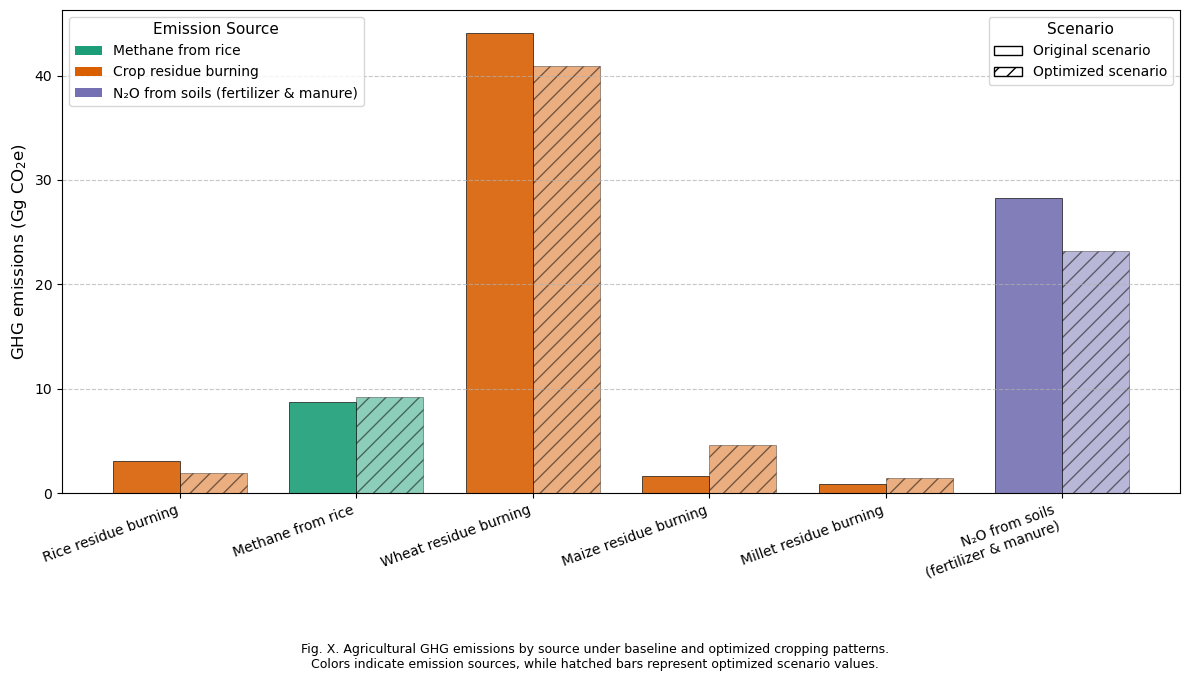

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Drop 'Total' row for plotting
df_plot = df_comp[df_comp["Component"] != "Total"].copy()

# Map each component to an emission source and color
source_colors = {
    "Rice_burning_CO2eq":     ("Crop residue burning", "#d95f02"),
    "Wheat_burning_CO2eq":    ("Crop residue burning", "#d95f02"),
    "Maize_burning_CO2eq":    ("Crop residue burning", "#d95f02"),
    "Millets_burning_CO2eq":  ("Crop residue burning", "#d95f02"),
    "Rice_CH4_CO2eq":         ("Methane from rice", "#1b9e77"),
    "Soils_N2O_CO2eq":        ("N₂O from soils (fertilizer & manure)", "#7570b3")
}

df_plot["Source"] = df_plot["Component"].map(lambda c: source_colors[c][0])
df_plot["Color"] = df_plot["Component"].map(lambda c: source_colors[c][1])

# Prepare data
components = df_plot["Component"].tolist()
orig_vals = df_plot["Original_kgCO2e"].values / 1e9  # to Gg
opt_vals  = df_plot["Optimized_kgCO2e"].values / 1e9
colors = df_plot["Color"].tolist()

x = np.arange(len(components))
width = 0.38

# Figure
fig, ax = plt.subplots(figsize=(12, 6))

# Original bars
bars1 = ax.bar(x - width/2, orig_vals, width, label='Original scenario',
               color=colors, alpha=0.9, edgecolor='black', linewidth=0.5)

# Optimized bars (hatched)
bars2 = ax.bar(x + width/2, opt_vals, width, label='Optimized scenario',
               color=colors, alpha=0.5, edgecolor='black', linewidth=0.5, hatch='//')

# Axis labels & ticks
ax.set_ylabel("GHG emissions (Gg CO$_2$e)", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(components, rotation=30, ha='right', fontsize=10)
ax.tick_params(axis='y', labelsize=10)

# Gridlines
ax.grid(axis='y', linestyle='--', alpha=0.7)
# Custom display names for x-axis
label_map = {
    "Rice_burning_CO2eq": "Rice residue burning",
    "Rice_CH4_CO2eq": "Methane from rice",
    "Wheat_burning_CO2eq": "Wheat residue burning",
    "Maize_burning_CO2eq": "Maize residue burning",
    "Millets_burning_CO2eq": "Millet residue burning",
    "Soils_N2O_CO2eq": "N₂O from soils\n(fertilizer & manure)"
}

# Apply readable labels
xtick_labels = [label_map.get(c, c) for c in components]

# In plotting section:
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=20, ha='right', fontsize=10)

# Legend: First for emission sources, then for scenario type
source_legend = [
    Patch(facecolor="#1b9e77", label="Methane from rice"),
    Patch(facecolor="#d95f02", label="Crop residue burning"),
    Patch(facecolor="#7570b3", label="N₂O from soils (fertilizer & manure)")
]
scenario_legend = [
    Patch(facecolor='white', edgecolor='black', label='Original scenario'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Optimized scenario')
]

# Combine legends
first_legend = ax.legend(handles=source_legend, title="Emission Source",
                         fontsize=10, title_fontsize=11, loc='upper left')
ax.add_artist(first_legend)  # Keep first legend on plot
ax.legend(handles=scenario_legend, title="Scenario",
          fontsize=10, title_fontsize=11, loc='upper right')

# Caption-like text
fig.text(0.5, -0.08,
         "Fig. X. Agricultural GHG emissions by source under baseline and optimized cropping patterns.\n"
         "Colors indicate emission sources, while hatched bars represent optimized scenario values.",
         ha='center', va='top', fontsize=9)
# Save high-res figure
save_path = r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\fig\GHG_components_comparison_n_rabi.png"
#os.makedirs(os.path.dirname(save_path), exist_ok=True)
plt.savefig(save_path, dpi=600, bbox_inches="tight")
plt.tight_layout()
plt.show()


In [21]:
# ------------------------------------------
# GHG Estimation using Area-based Method
# ------------------------------------------
#https://pmc.ncbi.nlm.nih.gov/articles/PMC5268357/#tbl0005
# Crop-wise GHG emission factors (kg CO2e / ha)
area_based_ghg_factor = {
    'rice': 8447.59,
    'wheat': 977.15,
    'maize': 707.32,
    'bajra': 707.32,
    'jowar': 707.32,
    'ragi': 707.32
}

# Calculate original total GHG
ghg_original_area_based = sum(
    current_cereal_area.get((s, d, c), 0) * area_based_ghg_factor.get(c, 0)
    for s in states for d in districts for c in cereals
)

# Calculate optimized total GHG
ghg_optimized_area_based = sum(
    (pulp.value(x[s][d][c]) or 0) * area_based_ghg_factor.get(c, 0)
    for s in states for d in districts for c in cereals
)

# Report
print("\n📌 GHG Estimation via Area-based Emission Factors:")
print(f"Original Total GHG (kg CO2e): {ghg_original_area_based:,.2f}")
print(f"Optimized Total GHG (kg CO2e): {ghg_optimized_area_based:,.2f}")
print(f"% Reduction: {((ghg_original_area_based - ghg_optimized_area_based) / ghg_original_area_based) * 100:.2f}%")



📌 GHG Estimation via Area-based Emission Factors:
Original Total GHG (kg CO2e): 71,770,335,822.24
Optimized Total GHG (kg CO2e): 65,965,837,652.46
% Reduction: 8.09%


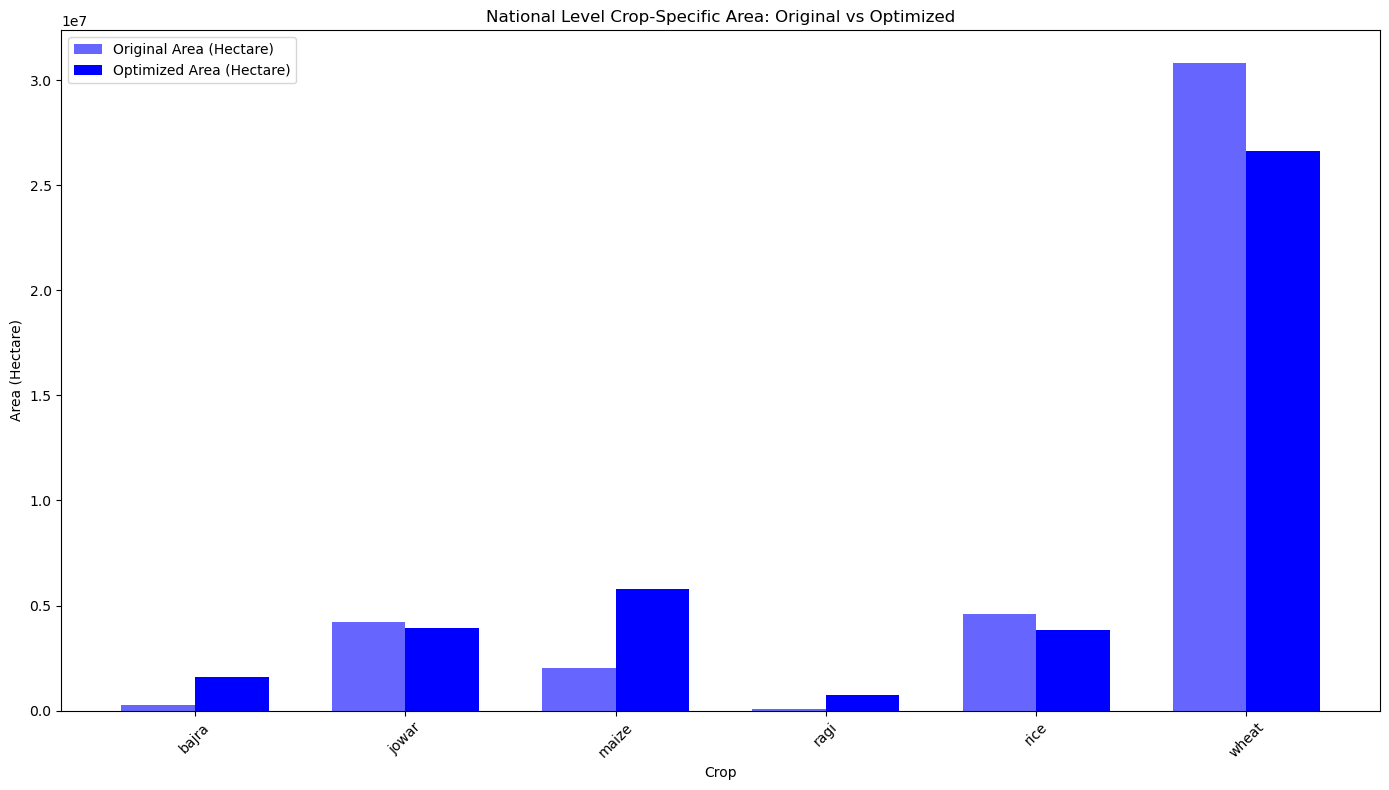

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Aggregate the data at the national level
national_aggregated = merged_results_df.groupby('Crop')[['Optimized Area (Hectare)', 'Original Area (Hectare)']].sum().reset_index()

# Define bar width and positions
bar_width = 0.35
index = np.arange(len(national_aggregated))

# Step 2: Plot the data
plt.figure(figsize=(14, 8))

# Plot original areas
plt.bar(index, national_aggregated['Original Area (Hectare)'], bar_width, label='Original Area (Hectare)', color='blue', alpha=0.6)

# Plot optimized areas
plt.bar(index + bar_width, national_aggregated['Optimized Area (Hectare)'], bar_width, label='Optimized Area (Hectare)', color='blue', alpha=1.0)

# Set labels and title
plt.xlabel('Crop')
plt.ylabel('Area (Hectare)')
plt.title('National Level Crop-Specific Area: Original vs Optimized')

# Set x-ticks with crop names
plt.xticks(index + bar_width / 2, national_aggregated['Crop'], rotation=45)

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


In [17]:
import pulp
import copy

# Helper function to adjust rates and solve the optimization problem
def solve_with_adjusted_rates(nitrogen_rate, water_rate, adjustment_factor):
    adjusted_nitrogen_rate = {k: v * adjustment_factor for k, v in nitrogen_rate.items()}
    adjusted_water_rate = {k: v * adjustment_factor for k, v in water_rate.items()}
    
    # Define the optimization problem
    prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    
    # Decision Variables
    x = pulp.LpVariable.dicts("Area (Hectare)", (states, districts, cereals), 0, None, pulp.LpContinuous)
    
    # Objective Function - Adjusted to use district & crop specific nitrogen rates
    prob += pulp.lpSum([x[s][d][c] * (adjusted_nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0)))
                        for s in states for d in districts for c in cereals])
    
    # Constraints
    for s in states:
        for d in districts:
            prob += pulp.lpSum([x[s][d][c] for c in cereals]) == current_area.get((s, d), 0)
    
    for s in states:
        for d in districts:
            for c in cereals:
                if c in max_area_constraints:
                    prob += x[s][d][c] <= max_area_constraints[c]
                    
                if historical_cereal_area.get((s, d, c), 0) == 0:
                    prob += x[s][d][c] == 0
    
    initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum(
            [x[s][d][c] * yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0) 
             for d in districts for c in cereals]
        ) >= initial_state_calories[s]
    
    #initial_state_profit = df.groupby('State')['Total initial profit'].sum().to_dict()
    #for s in states:
        #prob += pulp.lpSum([(x[s][d][c] * yield_data.get((s, d, c), 0) * 0.01 * MSP_per_prod.get((s, d, c), 0)) -
         #                   (x[s][d][c] * yield_data.get((s, d, c), 0) * 0.01 * cost_per_area.get((s, d, c), 0)) 
          #                  for d in districts if district_to_state.get(d) == s for c in cereals]) >= initial_state_profit[s]

    # Solve the problem
    solver = pulp.PULP_CBC_CMD()
    #solver = pulp.GLPK_CMD()
    prob.solve(solver)

    # Gather results
    optimized_total_nitrogen_surplus = sum((pulp.value(x[s][d][c])) * (adjusted_nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0)))
                                           for s in states for d in districts for c in cereals)
    optimized_total_water = sum((pulp.value(x[s][d][c])) * adjusted_water_rate.get((s, d, c), 0)
                                for s in states for d in districts for c in cereals)
    
    # Print results
    print(f"Adjusted by factor {adjustment_factor}:")
    print("Optimized Total Nitrogen Surplus:", optimized_total_nitrogen_surplus)
    print("Optimized Total Water:", optimized_total_water)
    print("Status:", pulp.LpStatus[prob.status])
    print("\n")

# Perform parametric uncertainty analysis
adjustment_factors = [0.9, 1.1]
for factor in adjustment_factors:
    solve_with_adjusted_rates(nitrogen_rate, water_rate, factor)


Adjusted by factor 0.9:
Optimized Total Nitrogen Surplus: 1964646591.4670901
Optimized Total Water: 76203813055.5678
Status: Optimal


Adjusted by factor 1.1:
Optimized Total Nitrogen Surplus: 2991703870.506503
Optimized Total Water: 92982722759.39992
Status: Optimal




Results: {'Adjusted by factor 1.0': {'maize': 5576761.795416968, 'bajra': 1576923.452499946, 'jowar': 3926854.006621, 'ragi': 759967.2320000137, 'rice': 3799923.1744949995, 'wheat': 26086698.659129996}, 'Adjusted by factor 0.9': {'maize': 5561028.6334169675, 'bajra': 1555285.696499946, 'jowar': 3926810.0047, 'ragi': 797369.5357740137, 'rice': 3799935.7905949997, 'wheat': 26086698.659129996}, 'Adjusted by factor 1.1': {'maize': 5693585.438716967, 'bajra': 1576923.452499946, 'jowar': 3935349.006621, 'ragi': 737493.8310000136, 'rice': 3800788.3086949997, 'wheat': 25982988.28183}}
Results DataFrame:                                maize         bajra         jowar  \
Adjusted by factor 1.0  5.576762e+06  1.576923e+06  3.926854e+06   
Adjusted by factor 0.9  5.561029e+06  1.555286e+06  3.926810e+06   
Adjusted by factor 1.1  5.693585e+06  1.576923e+06  3.935349e+06   

                                 ragi          rice         wheat  
Adjusted by factor 1.0  759967.232000  3.799923e+06  2.6

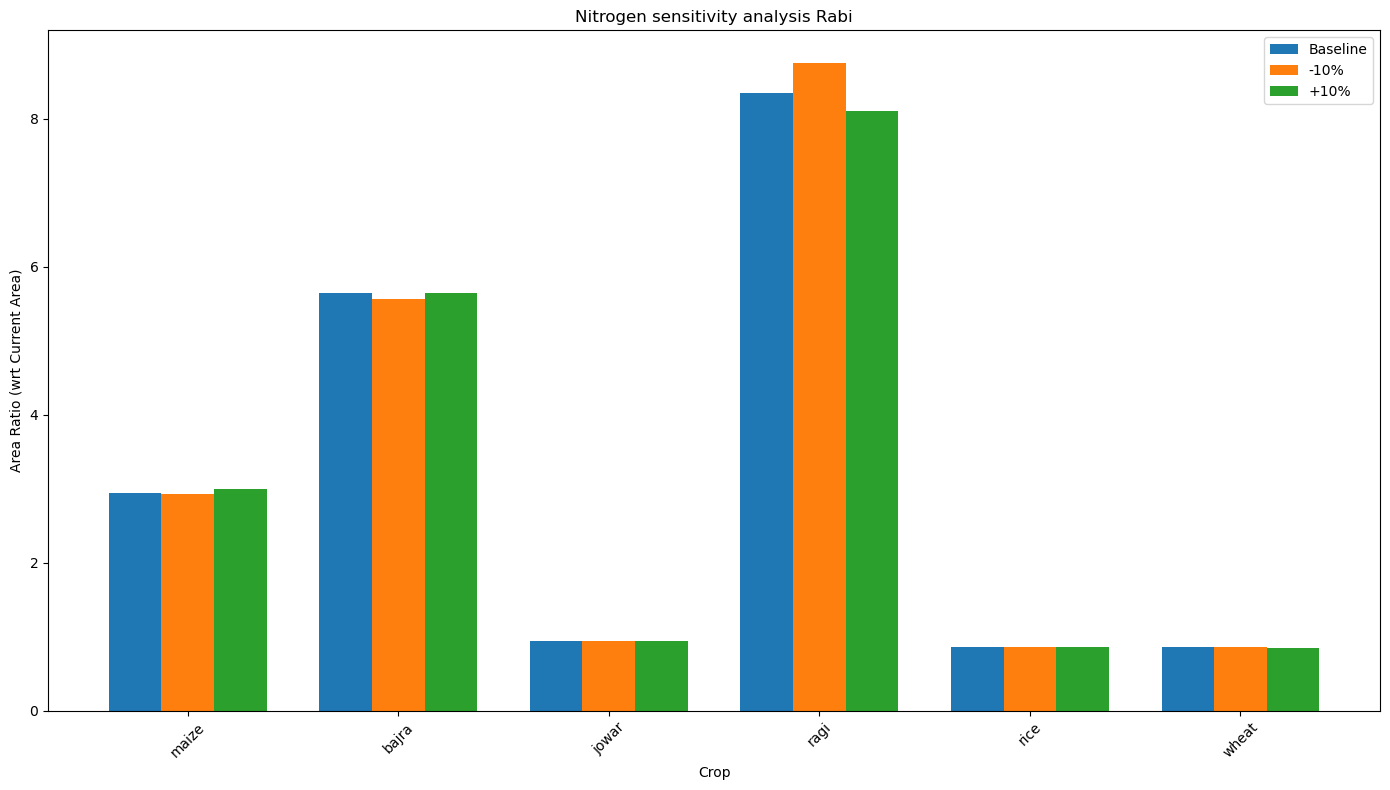

In [18]:
import pulp
import pandas as pd
import matplotlib.pyplot as plt

# Helper function to adjust nitrogen rates and solve the optimization problem
def solve_with_adjusted_nitrogen_rates(nitrogen_rate, adjustment_factor=1.0):
    adjusted_nitrogen_rate = {k: v * adjustment_factor for k, v in nitrogen_rate.items()}
    
    # Define the optimization problem
    prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)
    
    # Decision Variables
    x = pulp.LpVariable.dicts("Area (Hectare)", (states, districts, cereals), 0, None, pulp.LpContinuous)
    
    # Objective Function - Adjusted to use district & crop specific nitrogen rates
    prob += pulp.lpSum([x[s][d][c] * (adjusted_nitrogen_rate.get((s, d, c), 0) - (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0)))
                        for s in states for d in districts for c in cereals])
    
    # Constraints
    for s in states:
        for d in districts:
            prob += pulp.lpSum([x[s][d][c] for c in cereals]) == current_area.get((s, d), 0)
    
    for s in states:
        for d in districts:
            for c in cereals:
                if c in max_area_constraints:
                    prob += x[s][d][c] <= max_area_constraints[c]
                    
                if historical_cereal_area.get((s, d, c), 0) == 0:
                    prob += x[s][d][c] == 0
    
    initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum(
            [x[s][d][c] * yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0) 
             for d in districts for c in cereals]
        ) >= initial_state_calories[s]
    
    #initial_state_profit = df.groupby('State')['Total initial profit'].sum().to_dict()
    #for s in states:
     #   prob += pulp.lpSum([(x[s][d][c] * yield_data.get((s, d, c), 0) * 0.01 * MSP_per_prod.get((s, d, c), 0)) -
      #                      (x[s][d][c] * yield_data.get((s, d, c), 0) * 0.01 * cost_per_area.get((s, d, c), 0)) 
       #                     for d in districts if district_to_state.get(d) == s for c in cereals]) >= initial_state_profit[s]

    # Solve the problem
    #solver = pulp.GLPK_CMD(path=r"C:\Users\shekh\anaconda3\envs\opt_agri\Library\bin\glpsol.exe")
    solver = pulp.PULP_CBC_CMD()
    #solver = pulp.GLPK_CMD()
    prob.solve(solver)

    # Gather results
    if pulp.LpStatus[prob.status] == 'Optimal':
        total_area = {c: sum(pulp.value(x[s][d][c]) for s in states for d in districts) for c in cereals}
        return total_area, pulp.LpStatus[prob.status]
    else:
        print(f"Optimization not feasible for adjustment factor {adjustment_factor}")
        return None, pulp.LpStatus[prob.status]

# Perform parametric uncertainty analysis for nitrogen
adjustment_factors = [1.0, 0.9, 1.1]  # Baseline, -10%, +10%
results = {}

for factor in adjustment_factors:
    total_area, status = solve_with_adjusted_nitrogen_rates(nitrogen_rate, factor)
    if total_area is not None:
        results[f'Adjusted by factor {factor}'] = total_area

# Debugging: Print results to ensure correctness
print("Results:", results)

# Convert results to DataFrame for plotting if results are not empty
if results:
    results_df = pd.DataFrame(results).T
    
    # Debugging: Print results_df to ensure correctness
    print("Results DataFrame:", results_df)
    
    # Original non-optimized crop areas
    original_areas = {c: sum(current_cereal_area.get((s,d,c), 0) for s in states for d in districts) for c in cereals}
    original_areas_series = pd.Series(original_areas, name='Original Areas')
    
    # Calculate area ratios with respect to original non-optimized crop areas
    area_ratios = results_df.div(original_areas_series, axis=1)
    
    # Debugging: Print area_ratios to ensure correctness
    print("Area Ratios DataFrame:", area_ratios)
    
    # Ensure the DataFrame index matches the number of scenarios
    area_ratios.index = ['Baseline', '-10%', '+10%']
    
    # Prepare data for plotting
    scenarios = ['Baseline', '-10%', '+10%']
    bar_width = 0.25
    index = range(len(cereals))
    
    # Plotting the results
    fig, ax = plt.subplots(figsize=(14, 8))
    
    for i, scenario in enumerate(scenarios):
        ax.bar([p + bar_width * i for p in index], area_ratios.iloc[i], bar_width, label=scenario)
    
    ax.set_xlabel('Crop')
    ax.set_ylabel('Area Ratio (wrt Current Area)')
    ax.set_title('Nitrogen sensitivity analysis Rabi')
    ax.set_xticks([p + bar_width for p in index])
    ax.set_xticklabels(cereals)
    ax.legend(scenarios)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    #plt.savefig(r'E:\crop_switchning\parametric uncertainity\national_crop_areas_rabi_nitrogen.png', format='png')

    plt.show()
else:
    print("No optimal solutions found for any scenarios.")


In [45]:
import pandas as pd
import pulp
import copy

# ========================================================
# AGHG factors (burning per-kg CO2e + rice CH4 per-ha)
# ========================================================
AGHG_FACTORS_PATH = r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv"

aghg_df = pd.read_csv(AGHG_FACTORS_PATH)
aghg_df["state_key"] = aghg_df["State"].astype(str).str.strip().str.lower()

# Residue burning per-kg factors
rice_burn_CO2eq_perkg    = dict(zip(aghg_df["state_key"], aghg_df["Rice_CO2eq_perkg"]))
wheat_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Wheat_CO2eq_perkg"]))
maize_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Maize_CO2eq_perkg"]))
millets_burn_CO2eq_perkg = dict(zip(aghg_df["state_key"], aghg_df["Millets_CO2eq_perkg"]))
# Rice CH4 per ha (already CO2e/ha)
rice_ch4_per_ha          = dict(zip(aghg_df["state_key"], aghg_df["rice_ch4_co2_eq_per_ha"]))

# N2O constants
N2O_GWP = 273                 # AR6
USE_N2O_N = False             # Flip to True if fn2o is N2O-N fraction
MOLAR_RATIO_N2O = 44/28       # N2O-N -> N2O

# ========================================================
# RABI OPTIMIZATION (N-surplus minimization) + AGHG
# ========================================================
def run_optimization_rabi(rabi_2017, rabi_max, rabi, historical_cereal_area_dict, use_max_area_constraints=True):
    # Work on a copy
    df = rabi_2017.copy()

    # ---------- PREPROCESSING ----------
    # Standardize names
    df.rename(columns={'district': 'District', 'state': 'State', 'crop': 'Crop'}, inplace=True)

    # Calculate net N and net P applied
    df['net_N_applied(kg/ha)'] = df['N_applied(kg/ha)'] + df['Manure (N_kg/ha)'] + df['atm_depo'] + df['BNF_kg_per_hec']
    df['net_P_applied(kg/ha)'] = df['P_applied(kg/ha)'] + df['Manure (P_kg/ha)']

    # rabi_max prep
    rabi_max = rabi_max.rename(columns={'district': 'District', 'state': 'State', 'crop': 'Crop'})
    rabi_max['Crop'] = rabi_max['Crop'].str.lower().str.strip()

    # Rabi cereals to consider (as per your earlier list)
    selected_crops = ['bajra', 'jowar', 'ragi', 'rice', 'maize', 'wheat']
    df = df[df['Crop'].isin(selected_crops)]
    rabi_max = rabi_max[rabi_max['Crop'].isin(selected_crops)]

    # Max area constraints (tuple-keyed)
    max_area_constraints = rabi_max.set_index(['State', 'District', 'Crop'])['Area (Hectare)'].to_dict()

    # Lowercase keys for matching
    df['District'] = df['District'].astype(str).str.lower().str.strip()
    df['State']    = df['State'].astype(str).str.lower().str.strip()
    df['Crop']     = df['Crop'].astype(str).str.lower().str.strip()

    # Fill missing N applied
    avg_N_applied = df.groupby(['Crop'])['net_N_applied(kg/ha)'].transform('mean')
    global_avg_N  = rabi.groupby(['crop'])['net_N_applied(kg/ha)'].transform('mean')
    df['net_N_applied(kg/ha)'].fillna(avg_N_applied, inplace=True)
    df['net_N_applied(kg/ha)'].fillna(global_avg_N, inplace=True)

    # Fill missing P applied
    avg_P_applied = df.groupby(['Crop'])['net_P_applied(kg/ha)'].transform('mean')
    global_avg_P  = rabi.groupby(['crop'])['net_P_applied(kg/ha)'].transform('mean')
    df['net_P_applied(kg/ha)'].fillna(avg_P_applied, inplace=True)
    df['net_P_applied(kg/ha)'].fillna(global_avg_P, inplace=True)

    # Fill missing cost of production
    avg_cost_cult = df.groupby('Crop')['Cost_of_Production_rs_Quintal'].transform('mean')
    df['Cost_of_Production_rs_Quintal'].fillna(avg_cost_cult, inplace=True)
    global_avg_cost_cult = rabi.groupby('crop')['Cost_of_Production_rs_Quintal'].transform('mean')
    df['Cost_of_Production_rs_Quintal'].fillna(global_avg_cost_cult, inplace=True)

    # Replace -1 with zero & yield (kg/ha)
    df['Area (Hectare)']      = df['Area (Hectare)'].replace(-1, 0)
    df['Production (Tonnes)'] = df['Production (Tonnes)'].replace(-1, 0)
    df['YIELD (Kg per ha)']   = 1000 * df['Yield (Tonnes/Hectare)'].replace(-1, 0)

    # Fill missing CWR
    avg_applied_CWR = df.groupby(['Crop'])['CWR m3/ha'].transform('mean')
    global_avg_cwr  = rabi.groupby(['crop'])['CWR m3/ha'].transform('mean')
    df['CWR m3/ha'].fillna(avg_applied_CWR, inplace=True)
    df['CWR m3/ha'].fillna(global_avg_cwr, inplace=True)
    df['CWR m3/ha'] = df['CWR m3/ha'].fillna(0)

    # ---------- CALORIE / MSP / COST ----------
    calorie_per_100g = {'ragi': 321, 'bajra': 348, 'rice': 356, 'jowar': 334, 'wheat': 322, 'maize': 342}
    calorie_per_kg   = {cereal: value * 10 for cereal, value in calorie_per_100g.items()}  # kcal per kg

    df['Calorie Supply (per KG)'] = df['Crop'].map(calorie_per_kg)
    df['Total Calorie Supply']    = 1000 * df['Production (Tonnes)'] * df['Calorie Supply (per KG)']
    df['Total Farmer Cost']       = 10 * df['Production (Tonnes)'] * df['Cost_of_Production_rs_Quintal']  # tonnes->quintal
    df['Total MSP Supply']        = 10 * df['Production (Tonnes)'] * df['MSP_RsperQntl']
    df['Total initial profit']    = df['Total MSP Supply'] - df['Total Farmer Cost']

    # ---------- DICTIONARIES ----------
    states    = df['State'].unique().tolist()
    districts = df['District'].unique().tolist()
    cereals   = df['Crop'].unique().tolist()

    current_area = df.groupby(['State', 'District'])['Area (Hectare)'].sum().to_dict()
    yield_data   = df.set_index(['State', 'District', 'Crop'])['YIELD (Kg per ha)'].to_dict()

    nitrogen_rate                = df.set_index(['State', 'District', 'Crop'])['net_N_applied(kg/ha)'].to_dict()
    nitrogen_removal_rate_perkg  = df.set_index(['State', 'District', 'Crop'])['n_removed_rate'].to_dict()
    nitrogen_leach_rate_perkg    = df.set_index(['State', 'District', 'Crop'])['fno3'].to_dict()
    nitrogen_emission_rate_perkg = df.set_index(['State', 'District', 'Crop'])['fn2o'].to_dict()

    P_rate               = df.set_index(['State', 'District', 'Crop'])['net_P_applied(kg/ha)'].to_dict()
    P_removal_rate_perkg = df.set_index(['State', 'District', 'Crop'])['p_removed_rate'].to_dict()

    water_rate        = df.set_index(['State', 'District', 'Crop'])['CWR m3/ha'].to_dict()
    calories_per_prod = df.set_index(['State', 'District', 'Crop'])['Calorie Supply (per KG)'].to_dict()
    district_to_state = df.set_index('District')['State'].to_dict()
    cost_per_area     = df.set_index(['State', 'District', 'Crop'])['Cost_of_Production_rs_Quintal'].to_dict()
    MSP_per_prod      = df.set_index(['State', 'District', 'Crop'])['MSP_RsperQntl'].to_dict()

    # ---------- AGHG CALCULATOR ----------
    def aghg_from_area(s, d, c, area_ha):
        """Total AGHG (kg CO2e) from residue burning + rice CH4 + soil N2O (from N surplus)."""
        area_ha = float(area_ha or 0.0)
        if area_ha <= 0:
            return 0.0

        c_key = str(c).strip().lower()
        s_key = str(s).strip().lower()

        yld_kg_ha = float(yield_data.get((s, d, c), 0.0))
        prod_kg   = area_ha * yld_kg_ha

        total = 0.0
        # Residue burning + rice CH4
        if c_key == "rice":
            total += prod_kg * float(rice_burn_CO2eq_perkg.get(s_key, 0.0))
            total += area_ha * float(rice_ch4_per_ha.get(s_key, 0.0))
        elif c_key == "wheat":
            total += prod_kg * float(wheat_burn_CO2eq_perkg.get(s_key, 0.0))
        elif c_key == "maize":
            total += prod_kg * float(maize_burn_CO2eq_perkg.get(s_key, 0.0))
        elif c_key in ["bajra", "jowar", "ragi"]:
            total += prod_kg * float(millets_burn_CO2eq_perkg.get(s_key, 0.0))

        # Soils N2O from N surplus
        n_appl      = float(nitrogen_rate.get((s, d, c), 0.0))
        n_rem_perkg = float(nitrogen_removal_rate_perkg.get((s, d, c), 0.0))
        fn2o        = float(nitrogen_emission_rate_perkg.get((s, d, c), 0.0))

        n_surplus     = area_ha * n_appl - prod_kg * n_rem_perkg   # kg N
        n2o_from_nsur = n_surplus * fn2o                           # N2O or N2O-N
        if USE_N2O_N:
            n2o_from_nsur *= MOLAR_RATIO_N2O                       # N2O-N -> N2O
        total += n2o_from_nsur * N2O_GWP                           # kg CO2e

        return total

    # ---------- OPTIMIZATION ----------
    prob = pulp.LpProblem("OptimizeCerealArea_Rabi", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("Area (Hectare)", (states, districts, cereals), 0, None, pulp.LpContinuous)

    # Objective: minimize N surplus
    prob += pulp.lpSum([
        x[s][d][c] * (
            nitrogen_rate.get((s, d, c), 0) -
            (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0))
        )
        for s in states for d in districts for c in cereals
    ])

    # District area balance
    for s in states:
        for d in districts:
            prob += pulp.lpSum([x[s][d][c] for c in cereals]) == current_area.get((s, d), 0)

    # Historical feasibility (no new crops in new districts)
    for s in states:
        for d in districts:
            for c in cereals:
                if historical_cereal_area_dict.get((s, d, c), 0) == 0:
                    prob += x[s][d][c] == 0

    # Max historical area per (s,d,c) (optional)
    if use_max_area_constraints:
        for s in states:
            for d in districts:
                for c in cereals:
                    key = (s, d, c)
                    if key in max_area_constraints:
                        prob += x[s][d][c] <= max_area_constraints[key]

    # State-wise calorie must be >= baseline
    initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum([
            x[s][d][c] * yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0)
            for d in districts for c in cereals
        ]) >= initial_state_calories[s]

    # State-wise profit must be >= baseline
    initial_state_profit = df.groupby('State')['Total initial profit'].sum().to_dict()
    for s in states:
        prob += pulp.lpSum([
            (x[s][d][c] * yield_data.get((s, d, c), 0) * 0.01 * MSP_per_prod.get((s, d, c), 0)) -
            (x[s][d][c] * yield_data.get((s, d, c), 0) * 0.01 * cost_per_area.get((s, d, c), 0))
            for d in districts if district_to_state.get(d) == s for c in cereals
        ]) >= initial_state_profit[s]

    # Solve
    solver = pulp.PULP_CBC_CMD(msg=False)
    prob.solve(solver)

    # ---------- RESULTS ----------
    optimized_total_nitrogen_surplus = sum(
        (pulp.value(x[s][d][c])) * (
            nitrogen_rate.get((s, d, c), 0) -
            (yield_data.get((s, d, c), 0) * nitrogen_removal_rate_perkg.get((s, d, c), 0))
        )
        for s in states for d in districts for c in cereals
    )

    optimal_water = sum(
        (pulp.value(x[s][d][c])) * water_rate.get((s, d, c), 0)
        for s in states for d in districts for c in cereals
    )

    optimal_profit = sum(
        ((0.01 * pulp.value(x[s][d][c])) * yield_data.get((s, d, c), 0) * MSP_per_prod.get((s, d, c), 0)) -
        ((0.01 * pulp.value(x[s][d][c])) * yield_data.get((s, d, c), 0) * cost_per_area.get((s, d, c), 0))
        for s in states for d in districts for c in cereals
    )

    optimal_calorie = sum(
        (pulp.value(x[s][d][c])) * yield_data.get((s, d, c), 0) * calories_per_prod.get((s, d, c), 0)
        for s in states for d in districts for c in cereals
    )

    # Total AGHG via updated method
    optimal_aghg = sum(
        aghg_from_area(s, d, c, pulp.value(x[s][d][c]))
        for s in states for d in districts for c in cereals
    )

    return {
        "N_surplus": optimized_total_nitrogen_surplus,
        "water": optimal_water,
        "profit": optimal_profit,
        "calorie": optimal_calorie,
        "aghg": optimal_aghg
    }

# ========================================================
# SENSITIVITY ANALYSIS LOOP (Rabi) — adds AGHG + Calorie
# ========================================================
components = ['N_applied(kg/ha)', 'Manure (N_kg/ha)', 'atm_depo', 'BNF_kg_per_hec']
perturbations = [-0.2, -0.1, 0.1, 0.2]  # -20%, -10%, +10%, +20%

# Baseline (Rabi)
base_results = run_optimization_rabi(rabi_2017, rabi_max, rabi, historical_cereal_area_dict)

def pct_change(new, base):
    return 0.0 if (base is None or base == 0) else ((new - base) / base) * 100.0

results_list = []
for comp in components:
    for p in perturbations:
        df_test = copy.deepcopy(rabi_2017)
        df_test[comp] *= (1 + p)

        opt_results = run_optimization_rabi(df_test, rabi_max, rabi, historical_cereal_area_dict)

        results_list.append({
            "component": comp,
            "perturbation_%": p * 100,

            # core outcomes
            "N_surplus": opt_results["N_surplus"],
            "water":     opt_results["water"],
            "profit":    opt_results["profit"],
            "calorie":   opt_results["calorie"],
            "aghg":      opt_results["aghg"],

            # percent changes vs baseline
            "change_in_N_surplus_%": pct_change(opt_results["N_surplus"], base_results["N_surplus"]),
            "change_in_water_%":     pct_change(opt_results["water"],     base_results["water"]),
            "change_in_profit_%":    pct_change(opt_results["profit"],    base_results["profit"]),
            "change_in_calorie_%":   pct_change(opt_results["calorie"],   base_results["calorie"]),
            "change_in_aghg_%":      pct_change(opt_results["aghg"],      base_results["aghg"]),
        })

sensitivity_df = pd.DataFrame(results_list)
print(sensitivity_df)
# sensitivity_df.to_csv("sensitivity_analysis_results_rabi.csv", index=False)


C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2859218661.py:61: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['net_N_applied(kg/ha)'].fillna(avg_N_applied, inplace=True)
C:\Users\goyal\AppData\Local\Temp\5\ipykernel_34224\2859218661.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

           component  perturbation_%        N_surplus             water  \
0   N_applied(kg/ha)          -20.00 1,994,041,552.56 97,649,600,180.90   
1   N_applied(kg/ha)          -10.00 2,410,843,434.30 97,608,402,710.16   
2   N_applied(kg/ha)           10.00 3,242,085,826.13 97,125,269,712.42   
3   N_applied(kg/ha)           20.00 3,656,715,002.95 97,159,336,315.40   
4   Manure (N_kg/ha)          -20.00 2,814,923,067.94 97,423,494,579.82   
5   Manure (N_kg/ha)          -10.00 2,820,623,623.81 97,486,391,726.35   
6   Manure (N_kg/ha)           10.00 2,832,315,243.59 97,590,687,799.15   
7   Manure (N_kg/ha)           20.00 2,838,105,423.50 97,590,991,201.91   
8           atm_depo          -20.00 2,814,387,932.86 97,489,722,160.34   
9           atm_depo          -10.00 2,820,463,668.50 97,489,722,160.34   
10          atm_depo           10.00 2,832,615,139.79 97,489,722,160.34   
11          atm_depo           20.00 2,838,690,875.43 97,489,722,160.34   
12    BNF_kg_per_hec     

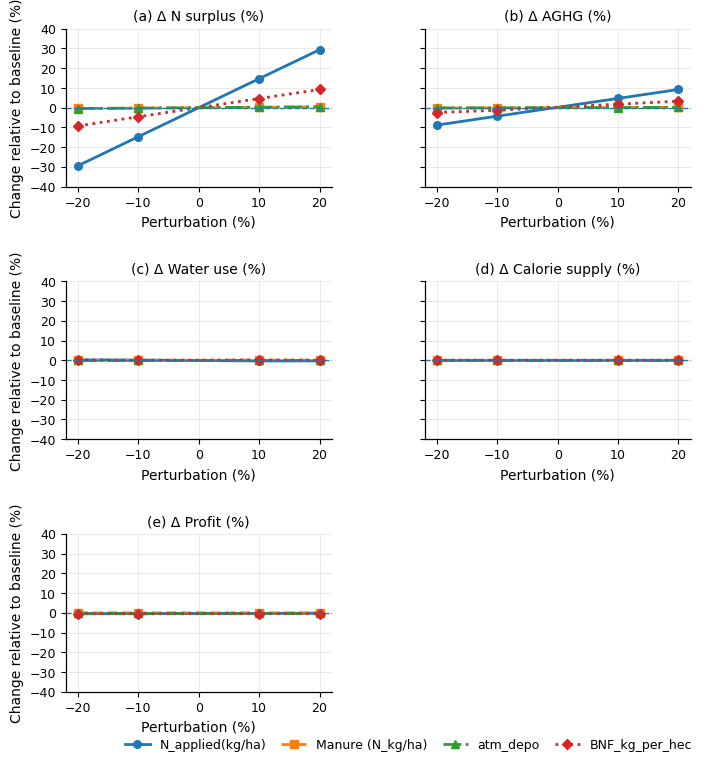

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import math

df = sensitivity_df.copy()

# ----- What to plot (reordered for readability) -----
metrics = [
    "change_in_N_surplus_%",
    "change_in_aghg_%",
    "change_in_water_%",
    "change_in_calorie_%",
    "change_in_profit_%"
]
titles = {
    "change_in_N_surplus_%": "Δ N surplus (%)",
    "change_in_aghg_%":      "Δ AGHG (%)",
    "change_in_water_%":     "Δ Water use (%)",
    "change_in_calorie_%":   "Δ Calorie supply (%)",
    "change_in_profit_%":    "Δ Profit (%)",
}
panel_letters = ["a", "b", "c", "d", "e"]

# ----- Matplotlib styling (publication-friendly) -----
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 9,            # base font
    "axes.titlesize": 10,      # panel title
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.9,
    "lines.linewidth": 2.0,
})

# Grid: 2 columns x 3 rows (two-column layout ~7.1 in wide)
cols = 2
rows = 3
fig, axes = plt.subplots(rows, cols, figsize=(7.1, 8.5), sharey=True)
axes = np.array(axes).reshape(-1)

components = list(df["component"].unique())
marker_cycle    = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyle_cycle = ["-", "--", "-.", ":"]

# X placement
df["perturbation_%"] = df["perturbation_%"].astype(float)
x_ticks = [-20, -10, 0, 10, 20]

# Fixed symmetric y-axis across ALL panels
YMAX = 40
y_ticks = np.arange(-40, 41, 10)

handles_for_legend = labels_for_legend = None

for i, metric in enumerate(metrics):
    ax = axes[i]
    for j, comp in enumerate(components):
        subset = df[df["component"] == comp].sort_values("perturbation_%")
        ax.plot(
            subset["perturbation_%"],
            subset[metric],
            marker=marker_cycle[j % len(marker_cycle)],
            linestyle=linestyle_cycle[j % len(linestyle_cycle)],
            markersize=5.5,
            label=comp
        )

    ax.axhline(0, linewidth=1, linestyle="--")
    ax.set_title(f"({panel_letters[i]}) {titles[metric]}")
    ax.set_xlabel("Perturbation (%)")
    if i % cols == 0:
        ax.set_ylabel("Change relative to baseline (%)")

    ax.set_xticks(x_ticks)
    ax.set_ylim(-YMAX, YMAX)
    ax.set_yticks(y_ticks)
    ax.grid(True, linewidth=0.6, alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if handles_for_legend is None:
        handles_for_legend, labels_for_legend = ax.get_legend_handles_labels()

# Hide any unused subplot (6th slot)
if len(metrics) < rows * cols:
    for j in range(len(metrics), rows * cols):
        fig.delaxes(axes[j])

# --- Shared legend in the LOWER RIGHT ---
fig.subplots_adjust(top=0.88, bottom=0.10, left=0.10, right=0.98, wspace=0.35, hspace=0.6)

if handles_for_legend:
    fig.legend(
        handles_for_legend,
        labels_for_legend,
        loc="lower right",                 # <-- lower-right placement
        bbox_to_anchor=(0.995, 0.02),      # nudge inside the corner
        ncol=len(labels_for_legend),       # one row (your 4 items fit)
        frameon=False,
        columnspacing=1.2,
        handlelength=2.0,
        borderaxespad=0.3
    )


# Save high-quality outputs
outdir = r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\sensitivity"
fname  = "sensitivity_n_componnet_n_rabi"
#plt.savefig(fr"{outdir}\{fname}.png", dpi=600, bbox_inches="tight")

plt.show()


In [59]:
import pandas as pd
import numpy as np
import pulp
from collections import defaultdict

# =========================
# Config / constants
# =========================
N_BOOT   = 1000
RSEED    = 42
THREADS  = 8
USE_N2O_N = False
N2O_GWP   = 273
MOLAR_RATIO_N2O = 44/28
rng = np.random.default_rng(RSEED)

OUT_DIR = r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\data"
TOTAL_OUT       = OUT_DIR + r"\bootstrap_results_total.csv"
SUMMARY_OUT     = OUT_DIR + r"\bootstrap_summary_total.csv"
PCT_TOTAL_OUT   = OUT_DIR + r"\bootstrap_pct_results_total.csv"
PCT_SUMMARY_OUT = OUT_DIR + r"\bootstrap_pct_summary_total.csv"

# =========================
# Helpers
# =========================
def safe_float(x, default=0.0):
    try:
        v = float(x)
        if not np.isfinite(v):
            return default
        return v
    except Exception:
        return default

def nan_to_num_arr(a, default=0.0):
    return np.nan_to_num(a, nan=default, posinf=default, neginf=default)

# =========================
# Load data
# =========================
kharif = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\kharif_waterdemand.csv")
rabi   = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\rabi_waterdemand.csv")
CoP    = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\cost_of_production.csv")
bnf_applied = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\bnf\bnf_app.csv")

CoP['State'] = CoP['State'].str.strip().str.lower()
CoP['Crop']  = CoP['Crop'].str.strip().str.lower()
CoP_renamed = CoP.rename(columns={"Crop":"crop","State":"state",
                                  "CostofProduction_rs_Quintal":"Cost_of_Production_rs_Quintal"})
rabi = pd.merge(rabi, CoP_renamed, how='left', on=['state','Year','crop'])

atm_df = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\crop_switchning\fig2\code_final\atmospheric_depo_isimip_2a.csv")
state_name_mapping = {
    'Andaman and Nicobar':'andaman and nicobar',
    'Andhra Pradesh':'andhra pradesh','Arunachal Pradesh':'arunachal pradesh',
    'Assam':'assam','Bihar':'bihar','Chandigarh':'chandigarh','Chhattisgarh':'chhattisgarh',
    'Dadra and Nagar Haveli':'dadra and nagar haveli',
    'Daman and Diu':'the dadra and nagar haveli and daman and diu',
    'Delhi':'delhi','Goa':'goa','Gujarat':'gujarat','Haryana':'haryana',
    'Himachal Pradesh':'himachal pradesh','Jammu and Kashmir':'jammu and kashmir',
    'Jharkhand':'jharkhand','Karnataka':'karnataka','Kerala':'kerala','Lakshadweep':'lakshadweep',
    'Madhya Pradesh':'madhya pradesh','Maharashtra':'maharashtra','Manipur':'manipur',
    'Meghalaya':'meghalaya','Mizoram':'mizoram','Nagaland':'nagaland','Orissa':'odisha',
    'Puducherry':'puducherry','Punjab':'punjab','Rajasthan':'rajasthan','Sikkim':'sikkim',
    'Tamil Nadu':'tamil nadu','Telangana':'telangana','Tripura':'tripura',
    'Uttar Pradesh':'uttar pradesh','Uttaranchal':'uttarakhand','West Bengal':'west bengal',
}
atm_df['State'] = atm_df['State'].map(state_name_mapping).str.lower().str.strip()
atm_df.rename(columns={'State':'state'}, inplace=True)
rabi = pd.merge(rabi, atm_df, on=['state','Year'], how='left')

rabi = pd.merge(rabi, bnf_applied, on=['Year'], how='left')

image_coeff = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\trial_analysis\image_coeff.csv")
image_coeff.rename(columns={'fN2O[% of Nsurplus]':'fn2o',
                            'fNO3_leaching_to_GW[% of Nsurplus]':'fno3'}, inplace=True)
image_coeff['State'] = image_coeff['State'].str.lower().str.strip()
image_coeff['fn2o'] /= 100.0
image_coeff['fno3'] /= 100.0
image_coeff['State'] = image_coeff['State'].replace({
    'the dadra and nagar haveli and daman and diu':'dadra and nagar haveli',
    'andaman and nicobar islands':'andaman and nicobar'
})
image_coeff.rename(columns={'State':'state'}, inplace=True)
rabi = pd.merge(rabi, image_coeff, on=['state'], how='left')

for df_del, col in ((kharif,'Unnamed: 0'), (rabi,'Unnamed: 0')):
    if col in df_del.columns:
        del df_del[col]

rabi['Manure (N_kg/ha)'] = rabi['Manure (kg/ha)'] * 0.005
rabi['Manure (P_kg/ha)'] = rabi['Manure (kg/ha)'] * 0.002

rabi_max = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\data_set_new\crop\rabi_max.csv")

# =========================
# Types / NaNs
# =========================
num_cols = ['N_applied(kg/ha)','Manure (N_kg/ha)','P_applied(kg/ha)','Manure (P_kg/ha)',
            'CWR m3/ha','CWU green m3/ha','CWU blue m3/ha']
for c in num_cols:
    rabi[c] = pd.to_numeric(rabi[c], errors='coerce')
for c in num_cols:
    rabi[c] = rabi[c].where(rabi[c] != 0, np.nan)

# Net N/P (panel)
rabi['net_N_applied(kg/ha)'] = rabi['N_applied(kg/ha)'] + rabi['Manure (N_kg/ha)'] + rabi['atm_depo'] + rabi['BNF_kg_per_hec']
rabi['net_P_applied(kg/ha)'] = rabi['P_applied(kg/ha)'] + rabi['Manure (P_kg/ha)']

# =========================
# 2017 slice
# =========================
rabi_2017 = rabi[rabi['Year']==2017].copy()
for col in ['N_applied(kg/ha)','P_applied(kg/ha)','K_applied(kg/ha)','Manure (kg/ha)','Cost_of_Production_rs_Quintal']:
    if col in rabi_2017.columns:
        rabi_2017[col] = rabi_2017[col].fillna(rabi_2017.groupby('crop')[col].transform('mean'))

rabi_2017[['CWR m3/ha','CWU green m3/ha','CWU blue m3/ha']] = \
    rabi_2017[['CWR m3/ha','CWU green m3/ha','CWU blue m3/ha']].fillna(
        rabi_2017.groupby(['state','crop'])[['CWR m3/ha','CWU green m3/ha','CWU blue m3/ha']].transform('mean')
    )
rabi_2017['Manure (N_kg/ha)'] = rabi_2017['Manure (N_kg/ha)'].fillna(0)
rabi_2017['Manure (P_kg/ha)'] = rabi_2017['Manure (P_kg/ha)'].fillna(0)

# Recompute nets for 2017
rabi_2017['net_N_applied(kg/ha)'] = rabi_2017['N_applied(kg/ha)'] + rabi_2017['Manure (N_kg/ha)'] + rabi_2017['atm_depo'] + rabi_2017['BNF_kg_per_hec']
rabi_2017['net_P_applied(kg/ha)'] = rabi_2017['P_applied(kg/ha)'] + rabi_2017['Manure (P_kg/ha)']

# =========================
# Historical feasibility
# =========================
historical_cereal_area = rabi.groupby(['state','district','crop'])['Area (Hectare)'].mean()
historical_cereal_area_dict = {(s.strip().lower(), d.strip().lower(), c.strip().lower()): safe_float(v)
                               for (s,d,c), v in historical_cereal_area.items()}

rabi_max = rabi_max.rename(columns={'state':'State','district':'District','crop':'Crop'})
for k in ['State','District','Crop']:
    rabi_max[k] = rabi_max[k].astype(str).str.lower().str.strip()
rabi_max['Area (Hectare)'] = pd.to_numeric(rabi_max['Area (Hectare)'], errors='coerce').fillna(0).clip(lower=0)

selected_crops = ['bajra','jowar','ragi','rice','maize','wheat']
rabi_max = rabi_max[rabi_max['Crop'].isin(selected_crops)].copy()
max_area_constraints_raw = rabi_max.set_index(['State','District','Crop'])['Area (Hectare)'].to_dict()

# =========================
# 2017 DF normalized
# =========================
df = rabi_2017.copy()
df.rename(columns={'state':'State','district':'District','crop':'Crop'}, inplace=True)
for k in ['State','District','Crop']:
    df[k] = df[k].astype(str).str.lower().str.strip()

df = df[df['Crop'].isin(selected_crops)].copy()

df['Area (Hectare)']      = df['Area (Hectare)'].replace(-1, 0)
df['Production (Tonnes)'] = df['Production (Tonnes)'].replace(-1, 0)
df['YIELD (Kg per ha)']   = 1000.0 * df['Yield (Tonnes/Hectare)'].replace(-1, 0)

calorie_per_100g = {'ragi':321,'bajra':348,'rice':356,'jowar':334,'wheat':322,'maize':342}
calorie_per_kg   = {k:v*10 for k,v in calorie_per_100g.items()}
crop_nitrogen_content     = {'rice':.0129,'jowar':.0146,'bajra':.0204,'maize':.0124,'ragi':.0204,'wheat':.0209}
crop_phosphorous_content  = {'rice':.0028,'jowar':.0045,'bajra':.0042,'maize':.0034,'ragi':.0042,'wheat':.0042}

df['n_removed_rate'] = df['Crop'].map(crop_nitrogen_content).fillna(0.0)
df['p_removed_rate'] = df['Crop'].map(crop_phosphorous_content).fillna(0.0)
df['Calorie Supply (per KG)'] = df['Crop'].map(calorie_per_kg).fillna(0.0)

yield_data   = df.set_index(['State','District','Crop'])['YIELD (Kg per ha)'].apply(safe_float).to_dict()
nitrogen_rate= df.set_index(['State','District','Crop'])['net_N_applied(kg/ha)'].apply(safe_float).to_dict()
nitrogen_removal_rate_perkg = df.set_index(['State','District','Crop'])['n_removed_rate'].apply(safe_float).to_dict()
P_rate      = df.set_index(['State','District','Crop'])['net_P_applied(kg/ha)'].apply(safe_float).to_dict()
P_removal_rate_perkg = df.set_index(['State','District','Crop'])['p_removed_rate'].apply(safe_float).to_dict()
water_rate  = df.set_index(['State','District','Crop'])['CWR m3/ha'].apply(safe_float).to_dict()
calories_per_prod = df.set_index(['State','District','Crop'])['Calorie Supply (per KG)'].apply(safe_float).to_dict()
cost_per_area = df.set_index(['State','District','Crop'])['Cost_of_Production_rs_Quintal'].apply(safe_float).to_dict()
MSP_per_prod  = df.set_index(['State','District','Crop'])['MSP_RsperQntl'].apply(safe_float).to_dict()
nitrogen_leach_rate_perkg    = df.set_index(['State','District','Crop'])['fno3'].apply(safe_float).to_dict()
nitrogen_emission_rate_perkg = df.set_index(['State','District','Crop'])['fn2o'].apply(safe_float).to_dict()

current_cereal_area = df.set_index(['State','District','Crop'])['Area (Hectare)'].apply(safe_float).to_dict()
current_area_sd = df.groupby(['State','District'])['Area (Hectare)'].sum().to_dict()
for k,v in list(current_area_sd.items()):
    if v < 0 or not np.isfinite(v):
        current_area_sd[k] = 0.0

df['Total Calorie Supply'] = 1000.0 * df['Production (Tonnes)'] * df['Calorie Supply (per KG)']
initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()

# =========================
# AGHG factors
# =========================
aghg_df = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv")
aghg_df['state_key'] = aghg_df['State'].astype(str).str.strip().str.lower()
rice_burn_CO2eq_perkg    = dict(zip(aghg_df["state_key"], aghg_df["Rice_CO2eq_perkg"]))
wheat_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Wheat_CO2eq_perkg"]))
maize_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Maize_CO2eq_perkg"]))
millets_burn_CO2eq_perkg = dict(zip(aghg_df["state_key"], aghg_df["Millets_CO2eq_perkg"]))
rice_ch4_per_ha          = dict(zip(aghg_df["state_key"], aghg_df["rice_ch4_co2_eq_per_ha"]))

# =========================
# Feasible keys & arrays
# =========================
df_keys = df[['State','District','Crop']].drop_duplicates()
feasible = []
for _, r0 in df_keys.iterrows():
    key = (r0['State'], r0['District'], r0['Crop'])
    if historical_cereal_area_dict.get(key, 0.0) > 0.0:
        feasible.append(key)

crops_by_sd = defaultdict(list)
for s,d,c in feasible:
    crops_by_sd[(s,d)].append(c)

key_order = feasible[:]

def arr_from_dict(dct, default=0.0):
    return nan_to_num_arr(np.array([dct.get(k, default) for k in key_order], dtype=float), default=default)

yld_vec    = arr_from_dict(yield_data)
cal_vec    = arr_from_dict(calories_per_prod)
p_rate_vec = arr_from_dict(P_rate)
p_rem_vec  = arr_from_dict(P_removal_rate_perkg)
wtr_vec    = arr_from_dict(water_rate)
msp_vec    = arr_from_dict(MSP_per_prod)
cost_vec   = arr_from_dict(cost_per_area)
fno3_vec   = arr_from_dict(nitrogen_leach_rate_perkg)
fn2o_vec   = arr_from_dict(nitrogen_emission_rate_perkg)
nrate0_vec = arr_from_dict(nitrogen_rate)

nrem_const_vec   = nan_to_num_arr(yld_vec * arr_from_dict(nitrogen_removal_rate_perkg))
p_const_vec      = nan_to_num_arr(yld_vec * p_rem_vec)
profit_coeff_vec = nan_to_num_arr(0.01 * yld_vec * (msp_vec - cost_vec))

burn_perkg_vec = np.zeros(len(key_order), dtype=float)
ch4_per_ha_vec = np.zeros(len(key_order), dtype=float)
for i, (s,d,c) in enumerate(key_order):
    s_key = s
    if c == 'rice':
        burn_perkg_vec[i] = safe_float(rice_burn_CO2eq_perkg.get(s_key, 0.0)) * yld_vec[i]
        ch4_per_ha_vec[i] = safe_float(rice_ch4_per_ha.get(s_key, 0.0))
    elif c == 'wheat':
        burn_perkg_vec[i] = safe_float(wheat_burn_CO2eq_perkg.get(s_key, 0.0)) * yld_vec[i]
    elif c == 'maize':
        burn_perkg_vec[i] = safe_float(maize_burn_CO2eq_perkg.get(s_key, 0.0)) * yld_vec[i]
    elif c in ['bajra','jowar','ragi']:
        burn_perkg_vec[i] = safe_float(millets_burn_CO2eq_perkg.get(s_key, 0.0)) * yld_vec[i]

area0_vec = np.array([safe_float(current_cereal_area.get(k, 0.0)) for k in key_order], dtype=float)

def totals_from(area_vec, nrate_vec):
    delta = nan_to_num_arr(nrate_vec - nrem_const_vec)
    N_surplus  = float(np.dot(area_vec, delta))
    N_applied  = float(np.dot(area_vec, nrate_vec))
    P_applied  = float(np.dot(area_vec, p_rate_vec))
    P_surplus  = float(np.dot(area_vec, p_rate_vec - p_const_vec))
    Water      = float(np.dot(area_vec, wtr_vec))
    Calories   = float(np.dot(area_vec, yld_vec * cal_vec))
    Profit     = float(np.dot(area_vec, profit_coeff_vec))
    N_leach    = float(np.dot(area_vec, fno3_vec * delta))
    N_emission = float(np.dot(area_vec, fn2o_vec * delta))
    n2o_conv   = MOLAR_RATIO_N2O if USE_N2O_N else 1.0
    soils_n2o_co2eq = (N_emission * n2o_conv) * N2O_GWP
    burn_total = float(np.dot(area_vec, burn_perkg_vec))
    ch4_total  = float(np.dot(area_vec, ch4_per_ha_vec))
    AGHG       = burn_total + ch4_total + soils_n2o_co2eq
    return {"N_surplus":N_surplus,"N_applied":N_applied,"P_surplus":P_surplus,"P_applied":P_applied,
            "Water":Water,"Calories":Calories,"Profit":Profit,"AGHG":AGHG,"N_leach":N_leach,"N_emission":N_emission}

orig_totals = totals_from(area0_vec, nrate0_vec)

# =========================
# Build max caps safely
# =========================
# Start with: cap >= observed 2017 area for that (S,D,C)
max_cap = {}
for key in key_order:
    cap_raw = safe_float(max_area_constraints_raw.get(key, 0.0))
    obs     = safe_float(current_cereal_area.get(key, 0.0))
    max_cap[key] = max(cap_raw, obs)  # never below observed

# For any district, if sum(cap) < district area, top up the largest-cap crop by the deficit
for (s,d), crops in crops_by_sd.items():
    need = safe_float(current_area_sd.get((s,d), 0.0))
    total_cap = sum(max_cap[(s,d,c)] for c in crops)
    if total_cap + 1e-6 < need:
        # pick crop with largest cap (or obs) and add deficit
        c_star = max(crops, key=lambda c: max_cap[(s,d,c)])
        deficit = need - total_cap
        max_cap[(s,d,c_star)] += deficit

# =========================
# Build LP once
# =========================
x = pulp.LpVariable.dicts("Area(Ha)", key_order, lowBound=0, cat=pulp.LpContinuous)
prob = pulp.LpProblem("OptimizeCerealArea", pulp.LpMinimize)

# District area conservation
for (s,d), crops in crops_by_sd.items():
    prob += pulp.lpSum(x[(s,d,c)] for c in crops) == safe_float(current_area_sd.get((s,d), 0.0))

# Max caps
for key in key_order:
    prob += x[key] <= max_cap[key]

# State calorie constraints (>= baseline)
states_unique = sorted(df['State'].unique())
for s in states_unique:
    keys_s = [key for key in key_order if key[0]==s]
    if not keys_s:  # nothing feasible in this state; skip to avoid infeasible empty-sum >= baseline
        continue
    prob += pulp.lpSum(x[key] * safe_float(yield_data.get(key,0.0)) * safe_float(calories_per_prod.get(key,0.0))
                       for key in keys_s) >= safe_float(initial_state_calories.get(s, 0.0))


# --- State farmer profit constraint (>= baseline from observed 2017 areas) ---
state_baseline_profit = {}
for s in states_unique:
    keys_s = [key for key in key_order if key[0] == s]
    if not keys_s:
        continue

    # Baseline profit using observed areas
    baseline = sum(
        safe_float(current_cereal_area.get(key, 0.0)) *
        0.01 *
        safe_float(yield_data.get(key, 0.0)) *
        (safe_float(MSP_per_prod.get(key, 0.0)) - safe_float(cost_per_area.get(key, 0.0)))
        for key in keys_s
    )
    state_baseline_profit[s] = baseline

    # Constraint: optimized state profit >= baseline
    prob += pulp.lpSum(
        x[key] *
        0.01 *
        safe_float(yield_data.get(key, 0.0)) *
        (safe_float(MSP_per_prod.get(key, 0.0)) - safe_float(cost_per_area.get(key, 0.0)))
        for key in keys_s
    ) >= baseline

nsurplus_const = {key: safe_float(yield_data.get(key,0.0)) * safe_float(nitrogen_removal_rate_perkg.get(key,0.0))
                  for key in key_order}

def set_objective_from(nrate_dict):
    # sanitize all coefficients
    coeff = {key: safe_float(nrate_dict.get(key,0.0)) - safe_float(nsurplus_const.get(key,0.0))
             for key in key_order}
    obj = pulp.lpSum(x[key] * coeff[key] for key in key_order)
    try:
        prob.setObjective(obj)
    except AttributeError:
        prob.objective = obj

def _safe_set_init(var, val):
    var.setInitialValue(float(0.0 if (val is None or not np.isfinite(val) or val < 0) else val))

solver = pulp.PULP_CBC_CMD(msg=False, threads=THREADS, warmStart=True, presolve=True)

# Seed first solve from observed areas (capped)
for key in key_order:
    obs = min(max(0.0, safe_float(current_cereal_area.get(key,0.0))), max_cap[key])
    _safe_set_init(x[key], obs)

set_objective_from(nitrogen_rate)
status0 = prob.solve(solver)
print("Initial solve status:", pulp.LpStatus[prob.status])

# =========================
# Bootstrap pools for N, Manure N
# =========================
panel = rabi.loc[rabi["Year"].between(2009, 2020),
                 ["state","district","crop","Year","N_applied(kg/ha)","Manure (N_kg/ha)"]].copy()
for k in ["state","district","crop"]:
    panel[k] = panel[k].astype(str).str.lower().str.strip()

pool_N = defaultdict(list); pool_M = defaultdict(list)
for _, row in panel.iterrows():
    key = (row["state"], row["district"], row["crop"])
    if pd.notna(row["N_applied(kg/ha)"]): pool_N[key].append(safe_float(row["N_applied(kg/ha)"]))
    if pd.notna(row["Manure (N_kg/ha)"]): pool_M[key].append(safe_float(row["Manure (N_kg/ha)"]))

pool_N_state_crop = defaultdict(list); pool_M_state_crop = defaultdict(list)
pool_N_crop = defaultdict(list); pool_M_crop = defaultdict(list)
for _, row in panel.iterrows():
    sc = (row["state"], row["crop"]); c = row["crop"]
    if pd.notna(row["N_applied(kg/ha)"]):
        pool_N_state_crop[sc].append(safe_float(row["N_applied(kg/ha)"]))
        pool_N_crop[c].append(safe_float(row["N_applied(kg/ha)"]))
    if pd.notna(row["Manure (N_kg/ha)"]):
        pool_M_state_crop[sc].append(safe_float(row["Manure (N_kg/ha)"]))
        pool_M_crop[c].append(safe_float(row["Manure (N_kg/ha)"]))

def sample_N_and_M(key):
    s,d,c = key
    if len(pool_N[key])>0: n_s = rng.choice(pool_N[key])
    elif len(pool_N_state_crop[(s,c)])>0: n_s = rng.choice(pool_N_state_crop[(s,c)])
    elif len(pool_N_crop[c])>0: n_s = rng.choice(pool_N_crop[c])
    else: n_s = np.nan
    if len(pool_M[key])>0: m_s = rng.choice(pool_M[key])
    elif len(pool_M_state_crop[(s,c)])>0: m_s = rng.choice(pool_M_state_crop[(s,c)])
    elif len(pool_M_crop[c])>0: m_s = rng.choice(pool_M_crop[c])
    else: m_s = 0.0
    return safe_float(n_s, 0.0), safe_float(m_s, 0.0)

# (atm + BNF) per key (fill NaN->0)
atm_bnfs = {}
tmp = df[['State','District','Crop','atm_depo','BNF_kg_per_hec']].drop_duplicates()
for _, r0 in tmp.iterrows():
    atm_bnfs[(r0['State'], r0['District'], r0['Crop'])] = (safe_float(r0['atm_depo'],0.0),
                                                           safe_float(r0['BNF_kg_per_hec'],0.0))

# =========================
# Bootstrap run
# =========================
results_total = []
results_pct   = []

print(f"Bootstrapping {N_BOOT} iterations with CBC(threads={THREADS}, warmStart=True)…")
for i in range(1, N_BOOT+1):
    nrate_iter_dict = {}
    for key in key_order:
        n_s, m_s = sample_N_and_M(key)
        s_atm, s_bnf = atm_bnfs.get(key, (0.0,0.0))
        nrate_iter_dict[key] = safe_float(n_s + m_s + s_atm + s_bnf, 0.0)

    set_objective_from(nrate_iter_dict)
    prob.solve(solver)

    stat = pulp.LpStatus[prob.status]
    if stat not in ("Optimal","Not Solved"):
        # Try a neutral warm start and re-solve once
        for key in key_order:
            _safe_set_init(x[key], min(max_cap[key], safe_float(current_cereal_area.get(key,0.0))))
        prob.solve(solver)
        stat = pulp.LpStatus[prob.status]
        if stat not in ("Optimal","Not Solved"):
            print(f"⚠️ Iter {i}: solver status {stat}. Proceeding with incumbent if any.")

    area_vec = np.array([safe_float(pulp.value(x[key]), 0.0) for key in key_order], dtype=float)
    for j,key in enumerate(key_order):
        _safe_set_init(x[key], area_vec[j])

    nrate_iter_vec = np.array([safe_float(nrate_iter_dict.get(key,0.0),0.0) for key in key_order], dtype=float)
    tot = totals_from(area_vec, nrate_iter_vec); tot['iter'] = i
    results_total.append(tot)

    pct = {
        'iter': i,
        '%_Water':       100.0*(orig_totals['Water']      - tot['Water'])      / orig_totals['Water']      if orig_totals['Water']      else 0.0,
        '%_N_surplus':   100.0*(orig_totals['N_surplus']  - tot['N_surplus'])  / orig_totals['N_surplus']  if orig_totals['N_surplus']  else 0.0,
        '%_P_surplus':   100.0*(orig_totals['P_surplus']  - tot['P_surplus'])  / orig_totals['P_surplus']  if orig_totals['P_surplus']  else 0.0,
        '%_N_applied':   100.0*(orig_totals['N_applied']  - tot['N_applied'])  / orig_totals['N_applied']  if orig_totals['N_applied']  else 0.0,
        '%_P_applied':   100.0*(orig_totals['P_applied']  - tot['P_applied'])  / orig_totals['P_applied']  if orig_totals['P_applied']  else 0.0,
        '%_Calories':    100.0*(orig_totals['Calories']   - tot['Calories'])   / orig_totals['Calories']   if orig_totals['Calories']   else 0.0,
        '%_Profit':      100.0*(orig_totals['Profit']     - tot['Profit'])     / orig_totals['Profit']     if orig_totals['Profit']     else 0.0,
        '%_AGHG':        100.0*(orig_totals['AGHG']       - tot['AGHG'])       / orig_totals['AGHG']       if orig_totals['AGHG']       else 0.0,
        '%_N_leach':     100.0*(orig_totals['N_leach']    - tot['N_leach'])    / orig_totals['N_leach']    if orig_totals['N_leach']    else 0.0,
        '%_N_emission':  100.0*(orig_totals['N_emission'] - tot['N_emission']) / orig_totals['N_emission'] if orig_totals['N_emission'] else 0.0,
    }
    results_pct.append(pct)

    if i % 50 == 0:
        print(f"  … iter {i} done.")

# =========================
# Save outputs + summaries
# =========================
boot_df = pd.DataFrame(results_total)
boot_df.to_csv(TOTAL_OUT, index=False)

boot_pct_df = pd.DataFrame(results_pct)
boot_pct_df.to_csv(PCT_TOTAL_OUT, index=False)

def summarize(df, exclude_cols=('iter',)):
    cols = [c for c in df.columns if c not in exclude_cols]
    sm = df[cols].agg(['mean','std','min','max']).T
    sm['p2.5']  = df[cols].quantile(0.025)
    sm['p97.5'] = df[cols].quantile(0.975)
    sm = sm.reset_index().rename(columns={'index':'metric'})
    return sm

summ_total = summarize(boot_df);     summ_total.to_csv(SUMMARY_OUT, index=False)
summ_pct   = summarize(boot_pct_df); summ_pct.to_csv(PCT_SUMMARY_OUT, index=False)

print("\n✓ Bootstrapping complete.")
print(f"→ Per-iter totals:          {TOTAL_OUT}")
print(f"→ Summary of totals:        {SUMMARY_OUT}")
print(f"→ Per-iter % reductions:    {PCT_TOTAL_OUT}")
print(f"→ Summary of % reductions:  {PCT_SUMMARY_OUT}")


Initial solve status: Infeasible
Bootstrapping 1000 iterations with CBC(threads=8, warmStart=True)…
⚠️ Iter 1: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 2: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 3: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 4: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 5: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 6: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 7: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 8: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 9: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 10: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 11: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 12: solver status Infeasible. Proceeding with incumbent if any.
⚠️ Iter 13: solver status Infeasible. Proceed

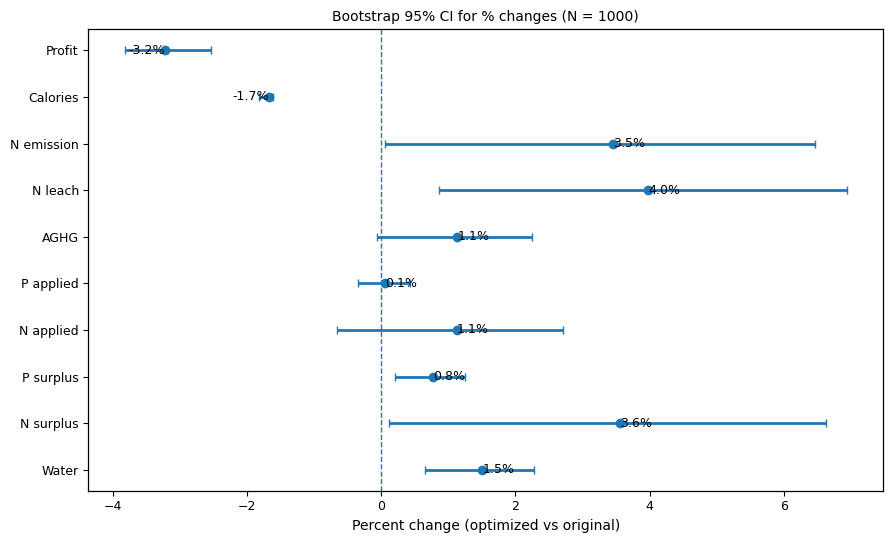

Saved figure as bootstrap_pct_reductions_ci.png


In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load summary of % reductions (from memory if available; else from CSV) ---
try:
    df = summ_pct.copy()   # from your script’s last block
except NameError:
    # If running in a fresh session, point this to the file path you saved:
    PCT_SUMMARY_OUT = r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\data\bootstrap_pct_summary_total.csv"
    df = pd.read_csv(PCT_SUMMARY_OUT)

# Metrics (order shown on the plot)
order = [
    '%_Water', '%_N_surplus', '%_P_surplus',
    '%_N_applied', '%_P_applied',
    '%_AGHG', '%_N_leach', '%_N_emission',
    '%_Calories', '%_Profit'
]

# Keep + order the rows we’ll plot
plot_df = df[df['metric'].isin(order)].copy()
plot_df['metric'] = pd.Categorical(plot_df['metric'], categories=order, ordered=True)
plot_df.sort_values('metric', inplace=True)

# Error bars: we’ll show mean ± (p97.5 - mean)/(mean - p2.5)
means = plot_df['mean'].values
xerr = [
    (means - plot_df['p2.5'].values),   # left error
    (plot_df['p97.5'].values - means)   # right error
]

# Prettier labels
label_map = {
    '%_Water':'Water',
    '%_N_surplus':'N surplus',
    '%_P_surplus':'P surplus',
    '%_N_applied':'N applied',
    '%_P_applied':'P applied',
    '%_AGHG':'AGHG',
    '%_N_leach':'N leach',
    '%_N_emission':'N emission',
    '%_Calories':'Calories',
    '%_Profit':'Profit'
}
y_labels = [label_map[m] for m in plot_df['metric']]

# --- Make the figure (single plot, no seaborn, no custom colors) ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(means, y_labels, xerr=xerr, fmt='o', capsize=3)
ax.axvline(0, linestyle='--', linewidth=1)
ax.set_xlabel('Percent change (optimized vs original)')
ax.set_title('Bootstrap 95% CI for % changes (N = 1000)')

# Annotate each point with the mean value
for y, m in enumerate(means):
    ax.text(m, y, f"{m:.1f}%", va='center', ha='left' if m >= 0 else 'right')

plt.tight_layout()
plt.savefig('bootstrap_pct_reductions_ci.png', dpi=300)
plt.show()

print("Saved figure as bootstrap_pct_reductions_ci.png")


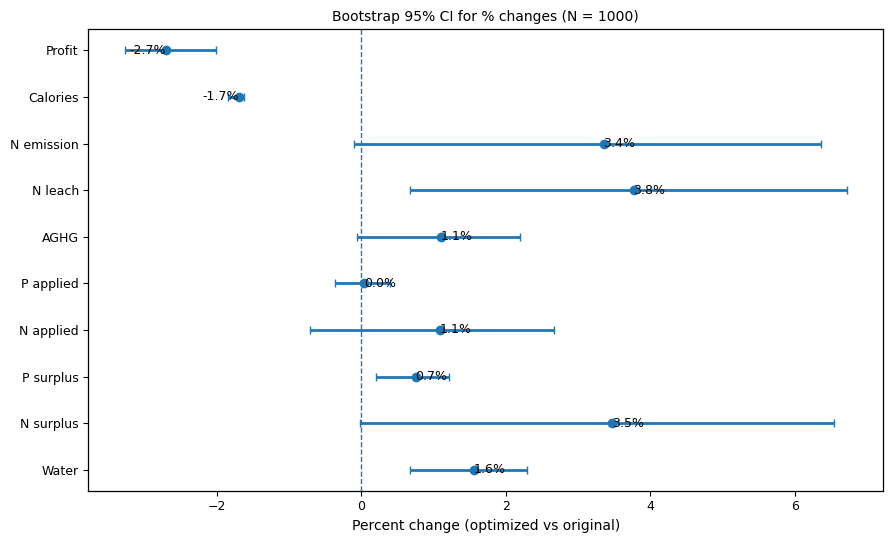

Saved figure as bootstrap_pct_reductions_ci.png


In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load summary of % reductions (from memory if available; else from CSV) ---
try:
    df = summ_pct.copy()   # from your script’s last block
except NameError:
    # If running in a fresh session, point this to the file path you saved:
    PCT_SUMMARY_OUT = r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\data\bootstrap_pct_summary_total.csv"
    df = pd.read_csv(PCT_SUMMARY_OUT)

# Metrics (order shown on the plot)
order = [
    '%_Water', '%_N_surplus', '%_P_surplus',
    '%_N_applied', '%_P_applied',
    '%_AGHG', '%_N_leach', '%_N_emission',
    '%_Calories', '%_Profit'
]

# Keep + order the rows we’ll plot
plot_df = df[df['metric'].isin(order)].copy()
plot_df['metric'] = pd.Categorical(plot_df['metric'], categories=order, ordered=True)
plot_df.sort_values('metric', inplace=True)

# Error bars: we’ll show mean ± (p97.5 - mean)/(mean - p2.5)
means = plot_df['mean'].values
xerr = [
    (means - plot_df['p2.5'].values),   # left error
    (plot_df['p97.5'].values - means)   # right error
]

# Prettier labels
label_map = {
    '%_Water':'Water',
    '%_N_surplus':'N surplus',
    '%_P_surplus':'P surplus',
    '%_N_applied':'N applied',
    '%_P_applied':'P applied',
    '%_AGHG':'AGHG',
    '%_N_leach':'N leach',
    '%_N_emission':'N emission',
    '%_Calories':'Calories',
    '%_Profit':'Profit'
}
y_labels = [label_map[m] for m in plot_df['metric']]

# --- Make the figure (single plot, no seaborn, no custom colors) ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(means, y_labels, xerr=xerr, fmt='o', capsize=3)
ax.axvline(0, linestyle='--', linewidth=1)
ax.set_xlabel('Percent change (optimized vs original)')
ax.set_title('Bootstrap 95% CI for % changes (N = 1000)')

# Annotate each point with the mean value
for y, m in enumerate(means):
    ax.text(m, y, f"{m:.1f}%", va='center', ha='left' if m >= 0 else 'right')

plt.tight_layout()
plt.savefig('bootstrap_pct_reductions_ci.png', dpi=300)
plt.show()

print("Saved figure as bootstrap_pct_reductions_ci.png")


In [61]:
# =========================
# Kharif pipeline (same structure as Rabi)
# =========================
import pandas as pd
import numpy as np
import pulp
from collections import defaultdict

# --- Reuse your global config ---
# N_BOOT, RSEED, THREADS, USE_N2O_N, N2O_GWP, MOLAR_RATIO_N2O, rng
# OUT_DIR already defined above; we’ll suffix outputs with season name.

def run_season_bootstrap(
    season_df_raw: pd.DataFrame,
    max_df_raw: pd.DataFrame,
    season_name: str,
    OUT_DIR: str,
    selected_crops: list,
    years_boot=(2009, 2020),
    # Optional: pass preloaded merges; if None, the function will expect these columns already present
    CoP_renamed: pd.DataFrame = None,
    atm_df: pd.DataFrame = None,
    bnf_applied: pd.DataFrame = None,
    image_coeff: pd.DataFrame = None,
    aghg_factor_csv: str = r"F:\goyal_shekhar\collaboration\2024\paper2\reburtal_doc\data\aghg_factor.csv"
):
    # ---------- Helpers ----------
    def safe_float(x, default=0.0):
        try:
            v = float(x)
            return v if np.isfinite(v) else default
        except Exception:
            return default

    def nan_to_num_arr(a, default=0.0):
        return np.nan_to_num(a, nan=default, posinf=default, neginf=default)

    def summarize(df, exclude_cols=('iter',)):
        cols = [c for c in df.columns if c not in exclude_cols]
        sm = df[cols].agg(['mean','std','min','max']).T
        sm['p2.5']  = df[cols].quantile(0.025)
        sm['p97.5'] = df[cols].quantile(0.975)
        sm = sm.reset_index().rename(columns={'index':'metric'})
        return sm

    # ---------- Output paths for this season ----------
    pre = season_name.lower()
    TOTAL_OUT       = fr"{OUT_DIR}\{pre}_bootstrap_results_total.csv"
    SUMMARY_OUT     = fr"{OUT_DIR}\{pre}_bootstrap_summary_total.csv"
    PCT_TOTAL_OUT   = fr"{OUT_DIR}\{pre}_bootstrap_pct_results_total.csv"
    PCT_SUMMARY_OUT = fr"{OUT_DIR}\{pre}_bootstrap_pct_summary_total.csv"

    # ---------- 1) Build season_df with all merges ----------
    df_season = season_df_raw.copy()

    # If CoP/atm/BNF/image_coeff provided, (re)merge to be safe
    if CoP_renamed is not None:
        # normalize keys
        df_season['state'] = df_season['state'].astype(str).str.lower().str.strip()
        df_season['crop']  = df_season['crop'].astype(str).str.lower().str.strip()
        df_season = pd.merge(df_season, CoP_renamed, how='left', on=['state', 'Year', 'crop'])

    if atm_df is not None:
        df_season = pd.merge(df_season, atm_df, on=['state', 'Year'], how='left')

    if bnf_applied is not None:
        df_season = pd.merge(df_season, bnf_applied, on=['Year'], how='left')

    if image_coeff is not None:
        df_season = pd.merge(df_season, image_coeff.rename(columns={'state':'state'}), on=['state'], how='left')

    # clean strays
    if 'Unnamed: 0' in df_season.columns:
        del df_season['Unnamed: 0']

    # manure
    df_season['Manure (N_kg/ha)'] = df_season['Manure (kg/ha)'] * 0.005
    df_season['Manure (P_kg/ha)'] = df_season['Manure (kg/ha)'] * 0.002

    # types / NaNs
    for c in ['N_applied(kg/ha)','Manure (N_kg/ha)','P_applied(kg/ha)','Manure (P_kg/ha)',
              'CWR m3/ha','CWU green m3/ha','CWU blue m3/ha']:
        if c in df_season.columns:
            df_season[c] = pd.to_numeric(df_season[c], errors='coerce')
            df_season[c] = df_season[c].where(df_season[c] != 0, np.nan)

    # nets over the panel
    df_season['net_N_applied(kg/ha)'] = df_season['N_applied(kg/ha)'] + df_season['Manure (N_kg/ha)'] + df_season['atm_depo'] + df_season['BNF_kg_per_hec']
    df_season['net_P_applied(kg/ha)'] = df_season['P_applied(kg/ha)'] + df_season['Manure (P_kg/ha)']

    # ---------- 2) Year slice (2017) ----------
    df17 = df_season[df_season['Year'] == 2017].copy()
    for col in ['N_applied(kg/ha)','P_applied(kg/ha)','K_applied(kg/ha)',
                'Manure (kg/ha)','Cost_of_Production_rs_Quintal']:
        if col in df17.columns:
            df17[col] = df17[col].fillna(df17.groupby('crop')[col].transform('mean'))

    df17[['CWR m3/ha','CWU green m3/ha','CWU blue m3/ha']] = \
        df17[['CWR m3/ha','CWU green m3/ha','CWU blue m3/ha']].fillna(
            df17.groupby(['state','crop'])[['CWR m3/ha','CWU green m3/ha','CWU blue m3/ha']].transform('mean')
        )
    df17['Manure (N_kg/ha)'] = df17['Manure (N_kg/ha)'].fillna(0)
    df17['Manure (P_kg/ha)'] = df17['Manure (P_kg/ha)'].fillna(0)

    # recompute nets for 2017
    df17['net_N_applied(kg/ha)'] = df17['N_applied(kg/ha)'] + df17['Manure (N_kg/ha)'] + df17['atm_depo'] + df17['BNF_kg_per_hec']
    df17['net_P_applied(kg/ha)'] = df17['P_applied(kg/ha)'] + df17['Manure (P_kg/ha)']

    # ---------- 3) Historical feasibility ----------
    hist = df_season.groupby(['state','district','crop'])['Area (Hectare)'].mean()
    hist_dict = {(s.strip().lower(), d.strip().lower(), c.strip().lower()): safe_float(v) for (s,d,c), v in hist.items()}

    # ---------- 4) Normalize DF17 ----------
    df = df17.copy()
    df.rename(columns={'state':'State','district':'District','crop':'Crop'}, inplace=True)
    for k in ['State','District','Crop']:
        df[k] = df[k].astype(str).str.lower().str.strip()

    df = df[df['Crop'].isin(selected_crops)].copy()

    df['Area (Hectare)']      = df['Area (Hectare)'].replace(-1, 0)
    df['Production (Tonnes)'] = df['Production (Tonnes)'].replace(-1, 0)
    df['YIELD (Kg per ha)']   = 1000.0 * df['Yield (Tonnes/Hectare)'].replace(-1, 0)

    # nutrition + calories
    calorie_per_100g = {'ragi':321,'bajra':348,'rice':356,'jowar':334,'wheat':322,'maize':342}
    calorie_per_kg   = {k:v*10 for k,v in calorie_per_100g.items()}
    crop_nitrogen_content     = {'rice':.0129,'jowar':.0146,'bajra':.0204,'maize':.0124,'ragi':.0204,'wheat':.0209}
    crop_phosphorous_content  = {'rice':.0028,'jowar':.0045,'bajra':.0042,'maize':.0034,'ragi':.0042,'wheat':.0042}

    df['n_removed_rate'] = df['Crop'].map(crop_nitrogen_content).fillna(0.0)
    df['p_removed_rate'] = df['Crop'].map(crop_phosphorous_content).fillna(0.0)
    df['Calorie Supply (per KG)'] = df['Crop'].map(calorie_per_kg).fillna(0.0)

    # dicts
    yield_data   = df.set_index(['State','District','Crop'])['YIELD (Kg per ha)'].to_dict()
    nitrogen_rate= df.set_index(['State','District','Crop'])['net_N_applied(kg/ha)'].to_dict()
    nrem_ratekg  = df.set_index(['State','District','Crop'])['n_removed_rate'].to_dict()
    P_rate       = df.set_index(['State','District','Crop'])['net_P_applied(kg/ha)'].to_dict()
    P_rem_kg     = df.set_index(['State','District','Crop'])['p_removed_rate'].to_dict()
    water_rate   = df.set_index(['State','District','Crop'])['CWR m3/ha'].to_dict()
    cal_per_prod = df.set_index(['State','District','Crop'])['Calorie Supply (per KG)'].to_dict()
    cost_per_area= df.set_index(['State','District','Crop'])['Cost_of_Production_rs_Quintal'].to_dict()
    MSP_per_prod = df.set_index(['State','District','Crop'])['MSP_RsperQntl'].to_dict()
    fno3         = df.set_index(['State','District','Crop'])['fno3'].to_dict()
    fn2o         = df.set_index(['State','District','Crop'])['fn2o'].to_dict()

    current_area_c = df.set_index(['State','District','Crop'])['Area (Hectare)'].to_dict()
    current_area_sd = df.groupby(['State','District'])['Area (Hectare)'].sum().to_dict()
    for k,v in list(current_area_sd.items()):
        if v < 0 or not np.isfinite(v):
            current_area_sd[k] = 0.0

    df['Total Calorie Supply'] = 1000.0 * df['Production (Tonnes)'] * df['Calorie Supply (per KG)']
    initial_state_calories = df.groupby('State')['Total Calorie Supply'].sum().to_dict()

    # ---------- 5) AGHG factors ----------
    aghg_df = pd.read_csv(aghg_factor_csv)
    aghg_df['state_key'] = aghg_df['State'].astype(str).str.strip().str.lower()
    rice_burn_CO2eq_perkg    = dict(zip(aghg_df["state_key"], aghg_df["Rice_CO2eq_perkg"]))
    wheat_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Wheat_CO2eq_perkg"]))
    maize_burn_CO2eq_perkg   = dict(zip(aghg_df["state_key"], aghg_df["Maize_CO2eq_perkg"]))
    millets_burn_CO2eq_perkg = dict(zip(aghg_df["state_key"], aghg_df["Millets_CO2eq_perkg"]))
    rice_ch4_per_ha          = dict(zip(aghg_df["state_key"], aghg_df["rice_ch4_co2_eq_per_ha"]))

    # ---------- 6) Feasible keys & arrays ----------
    df_keys = df[['State','District','Crop']].drop_duplicates()
    feasible = []
    for _, r0 in df_keys.iterrows():
        key = (r0['State'], r0['District'], r0['Crop'])
        if hist_dict.get(key, 0.0) > 0.0:
            feasible.append(key)

    crops_by_sd = defaultdict(list)
    for s,d,c in feasible:
        crops_by_sd[(s,d)].append(c)

    key_order = feasible[:]

    def arr_from_dict(dct, default=0.0):
        return nan_to_num_arr(np.array([dct.get(k, default) for k in key_order], dtype=float), default=default)

    yld_vec    = arr_from_dict(yield_data)
    cal_vec    = arr_from_dict(cal_per_prod)
    p_rate_vec = arr_from_dict(P_rate)
    p_rem_vec  = arr_from_dict(P_rem_kg)
    wtr_vec    = arr_from_dict(water_rate)
    msp_vec    = arr_from_dict(MSP_per_prod)
    cost_vec   = arr_from_dict(cost_per_area)
    fno3_vec   = arr_from_dict(fno3)
    fn2o_vec   = arr_from_dict(fn2o)
    nrate0_vec = arr_from_dict(nitrogen_rate)

    nrem_const_vec   = nan_to_num_arr(yld_vec * arr_from_dict(nrem_ratekg))
    p_const_vec      = nan_to_num_arr(yld_vec * p_rem_vec)
    profit_coeff_vec = nan_to_num_arr(0.01 * yld_vec * (msp_vec - cost_vec))

    burn_perkg_vec = np.zeros(len(key_order), dtype=float)
    ch4_per_ha_vec = np.zeros(len(key_order), dtype=float)
    for i, (s,d,c) in enumerate(key_order):
        s_key = s
        if c == 'rice':
            burn_perkg_vec[i] = safe_float(rice_burn_CO2eq_perkg.get(s_key, 0.0)) * yld_vec[i]
            ch4_per_ha_vec[i] = safe_float(rice_ch4_per_ha.get(s_key, 0.0))
        elif c == 'wheat':
            burn_perkg_vec[i] = safe_float(wheat_burn_CO2eq_perkg.get(s_key, 0.0)) * yld_vec[i]
        elif c == 'maize':
            burn_perkg_vec[i] = safe_float(maize_burn_CO2eq_perkg.get(s_key, 0.0)) * yld_vec[i]
        elif c in ['bajra','jowar','ragi']:
            burn_perkg_vec[i] = safe_float(millets_burn_CO2eq_perkg.get(s_key, 0.0)) * yld_vec[i]

    area0_vec = np.array([safe_float(current_area_c.get(k, 0.0)) for k in key_order], dtype=float)

    def totals_from(area_vec, nrate_vec):
        delta = nan_to_num_arr(nrate_vec - nrem_const_vec)
        N_surplus  = float(np.dot(area_vec, delta))
        N_applied  = float(np.dot(area_vec, nrate_vec))
        P_applied  = float(np.dot(area_vec, p_rate_vec))
        P_surplus  = float(np.dot(area_vec, p_rate_vec - p_const_vec))
        Water      = float(np.dot(area_vec, wtr_vec))
        Calories   = float(np.dot(area_vec, yld_vec * cal_vec))
        Profit     = float(np.dot(area_vec, profit_coeff_vec))
        N_leach    = float(np.dot(area_vec, fno3_vec * delta))
        N_emission = float(np.dot(area_vec, fn2o_vec * delta))
        n2o_conv   = MOLAR_RATIO_N2O if USE_N2O_N else 1.0
        soils_n2o_co2eq = (N_emission * n2o_conv) * N2O_GWP
        burn_total = float(np.dot(area_vec, burn_perkg_vec))
        ch4_total  = float(np.dot(area_vec, ch4_per_ha_vec))
        AGHG       = burn_total + ch4_total + soils_n2o_co2eq
        return {"N_surplus":N_surplus,"N_applied":N_applied,"P_surplus":P_surplus,"P_applied":P_applied,
                "Water":Water,"Calories":Calories,"Profit":Profit,"AGHG":AGHG,"N_leach":N_leach,"N_emission":N_emission}

    orig_totals = totals_from(area0_vec, nrate0_vec)

    # ---------- 7) Safe max caps ----------
    # Clean kharif_max and build caps keyed by (S,D,C)
    max_raw = max_df_raw.copy()
    # allow missing Unnamed
    if 'Unnamed: 0' in max_raw.columns:
        max_raw.drop(columns=['Unnamed: 0'], inplace=True)
    max_raw = max_raw.rename(columns={'state':'State','district':'District','crop':'Crop'})
    for k in ['State','District','Crop']:
        max_raw[k] = max_raw[k].astype(str).str.lower().str.strip()
    max_raw['Area (Hectare)'] = pd.to_numeric(max_raw['Area (Hectare)'], errors='coerce').fillna(0).clip(lower=0)
    max_raw = max_raw[max_raw['Crop'].isin(selected_crops)]
    max_area_constraints_raw = max_raw.set_index(['State','District','Crop'])['Area (Hectare)'].to_dict()

    # cap >= observed 2017 area; district sum(cap) >= district area
    max_cap = {}
    for key in key_order:
        cap_raw = safe_float(max_area_constraints_raw.get(key, 0.0))
        obs     = safe_float(current_area_c.get(key, 0.0))
        max_cap[key] = max(cap_raw, obs)

    for (s,d), crops in crops_by_sd.items():
        need = safe_float(current_area_sd.get((s,d), 0.0))
        total_cap = sum(max_cap[(s,d,c)] for c in crops)
        if total_cap + 1e-6 < need:
            c_star = max(crops, key=lambda c: max_cap[(s,d,c)])
            deficit = need - total_cap
            max_cap[(s,d,c_star)] += deficit

    # ---------- 8) Build LP once ----------
    x = pulp.LpVariable.dicts(f"{season_name}_Area(Ha)", key_order, lowBound=0, cat=pulp.LpContinuous)
    prob = pulp.LpProblem(f"{season_name}_OptimizeCerealArea", pulp.LpMinimize)

    # district area conservation
    for (s,d), crops in crops_by_sd.items():
        prob += pulp.lpSum(x[(s,d,c)] for c in crops) == safe_float(current_area_sd.get((s,d), 0.0))

    # max caps
    for key in key_order:
        prob += x[key] <= max_cap[key]

    # state calorie >= baseline
    states_unique = sorted(df['State'].unique())
    for s in states_unique:
        keys_s = [key for key in key_order if key[0]==s]
        if not keys_s:
            continue
        prob += pulp.lpSum(x[key] * safe_float(yield_data.get(key,0.0)) * safe_float(cal_per_prod.get(key,0.0))
                           for key in keys_s) >= safe_float(initial_state_calories.get(s, 0.0))

# --- State farmer profit constraint (>= baseline from observed 2017 areas) ---
    state_baseline_profit = {}
    for s in states_unique:
        keys_s = [key for key in key_order if key[0] == s]
        if not keys_s:
            continue

        baseline = sum(
            safe_float(current_area_c.get(key, 0.0)) *
            0.01 *
            safe_float(yield_data.get(key, 0.0)) *
            (safe_float(MSP_per_prod.get(key, 0.0)) - safe_float(cost_per_area.get(key, 0.0)))
            for key in keys_s
        )
        state_baseline_profit[s] = baseline

        prob += pulp.lpSum(
            x[key] *
        0.01 *
        safe_float(yield_data.get(key, 0.0)) *
            (safe_float(MSP_per_prod.get(key, 0.0)) - safe_float(cost_per_area.get(key, 0.0)))
            for key in keys_s
        ) >= baseline

    nsurplus_const = {key: safe_float(yield_data.get(key,0.0)) * safe_float(nrem_ratekg.get(key,0.0))
                      for key in key_order}

    def set_objective_from(nrate_dict):
        coeff = {key: safe_float(nrate_dict.get(key,0.0)) - safe_float(nsurplus_const.get(key,0.0))
                 for key in key_order}
        obj = pulp.lpSum(x[key] * coeff[key] for key in key_order)
        try:
            prob.setObjective(obj)
        except AttributeError:
            prob.objective = obj

    def _safe_set_init(var, val):
        var.setInitialValue(float(0.0 if (val is None or not np.isfinite(val) or val < 0) else val))

    solver = pulp.PULP_CBC_CMD(msg=False, threads=THREADS, warmStart=True, presolve=True)

    # warm-start from observed (capped)
    for key in key_order:
        obs = min(max(0.0, safe_float(current_area_c.get(key,0.0))), max_cap[key])
        _safe_set_init(x[key], obs)

    set_objective_from(nitrogen_rate)
    status0 = prob.solve(solver)
    print(f"[{season_name}] Initial solve status:", pulp.LpStatus[prob.status])

    # ---------- 9) Bootstrap pools ----------
    y0, y1 = years_boot
    panel = df_season.loc[df_season["Year"].between(y0, y1),
                          ["state","district","crop","Year","N_applied(kg/ha)","Manure (N_kg/ha)"]].copy()
    for k in ["state","district","crop"]:
        panel[k] = panel[k].astype(str).str.lower().str.strip()

    pool_N = defaultdict(list); pool_M = defaultdict(list)
    for _, row in panel.iterrows():
        key = (row["state"], row["district"], row["crop"])
        if pd.notna(row["N_applied(kg/ha)"]): pool_N[key].append(safe_float(row["N_applied(kg/ha)"]))
        if pd.notna(row["Manure (N_kg/ha)"]): pool_M[key].append(safe_float(row["Manure (N_kg/ha)"]))

    pool_N_state_crop = defaultdict(list); pool_M_state_crop = defaultdict(list)
    pool_N_crop = defaultdict(list); pool_M_crop = defaultdict(list)
    for _, row in panel.iterrows():
        sc = (row["state"], row["crop"]); c = row["crop"]
        if pd.notna(row["N_applied(kg/ha)"]):
            pool_N_state_crop[sc].append(safe_float(row["N_applied(kg/ha)"]))
            pool_N_crop[c].append(safe_float(row["N_applied(kg/ha)"]))
        if pd.notna(row["Manure (N_kg/ha)"]):
            pool_M_state_crop[sc].append(safe_float(row["Manure (N_kg/ha)"]))
            pool_M_crop[c].append(safe_float(row["Manure (N_kg/ha)"]))

    def sample_N_and_M(key):
        s,d,c = key
        if len(pool_N[key])>0: n_s = rng.choice(pool_N[key])
        elif len(pool_N_state_crop[(s,c)])>0: n_s = rng.choice(pool_N_state_crop[(s,c)])
        elif len(pool_N_crop[c])>0: n_s = rng.choice(pool_N_crop[c])
        else: n_s = np.nan
        if len(pool_M[key])>0: m_s = rng.choice(pool_M[key])
        elif len(pool_M_state_crop[(s,c)])>0: m_s = rng.choice(pool_M_state_crop[(s,c)])
        elif len(pool_M_crop[c])>0: m_s = rng.choice(pool_M_crop[c])
        else: m_s = 0.0
        return safe_float(n_s, 0.0), safe_float(m_s, 0.0)

    # (atm + BNF) per key (from df; fill NaN->0)
    atm_bnfs = {}
    tmp = df[['State','District','Crop','atm_depo','BNF_kg_per_hec']].drop_duplicates()
    for _, r0 in tmp.iterrows():
        atm_bnfs[(r0['State'], r0['District'], r0['Crop'])] = (safe_float(r0['atm_depo'],0.0),
                                                               safe_float(r0['BNF_kg_per_hec'],0.0))

    # ---------- 10) Bootstrap run ----------
    results_total = []
    results_pct   = []

    print(f"[{season_name}] Bootstrapping {N_BOOT} iterations with CBC(threads={THREADS}, warmStart=True)…")
    for i in range(1, N_BOOT+1):
        nrate_iter_dict = {}
        for key in key_order:
            n_s, m_s = sample_N_and_M(key)
            s_atm, s_bnf = atm_bnfs.get(key, (0.0,0.0))
            nrate_iter_dict[key] = safe_float(n_s + m_s + s_atm + s_bnf, 0.0)

        set_objective_from(nrate_iter_dict)
        prob.solve(solver)

        stat = pulp.LpStatus[prob.status]
        if stat not in ("Optimal","Not Solved"):
            for key in key_order:
                _safe_set_init(x[key], min(max_cap[key], safe_float(current_area_c.get(key,0.0))))
            prob.solve(solver)
            stat = pulp.LpStatus[prob.status]
            if stat not in ("Optimal","Not Solved"):
                print(f"  ⚠️ [{season_name}] Iter {i}: solver status {stat}. Proceeding with incumbent.")

        area_vec = np.array([safe_float(pulp.value(x[key]), 0.0) for key in key_order], dtype=float)
        for j,key in enumerate(key_order):
            _safe_set_init(x[key], area_vec[j])

        nrate_iter_vec = np.array([safe_float(nrate_iter_dict.get(key,0.0),0.0) for key in key_order], dtype=float)
        tot = totals_from(area_vec, nrate_iter_vec); tot['iter'] = i
        results_total.append(tot)

        pct = {
            'iter': i,
            '%_Water':       100.0*(orig_totals['Water']      - tot['Water'])      / orig_totals['Water']      if orig_totals['Water']      else 0.0,
            '%_N_surplus':   100.0*(orig_totals['N_surplus']  - tot['N_surplus'])  / orig_totals['N_surplus']  if orig_totals['N_surplus']  else 0.0,
            '%_P_surplus':   100.0*(orig_totals['P_surplus']  - tot['P_surplus'])  / orig_totals['P_surplus']  if orig_totals['P_surplus']  else 0.0,
            '%_N_applied':   100.0*(orig_totals['N_applied']  - tot['N_applied'])  / orig_totals['N_applied']  if orig_totals['N_applied']  else 0.0,
            '%_P_applied':   100.0*(orig_totals['P_applied']  - tot['P_applied'])  / orig_totals['P_applied']  if orig_totals['P_applied']  else 0.0,
            '%_Calories':    100.0*(orig_totals['Calories']   - tot['Calories'])   / orig_totals['Calories']   if orig_totals['Calories']   else 0.0,
            '%_Profit':      100.0*(orig_totals['Profit']     - tot['Profit'])     / orig_totals['Profit']     if orig_totals['Profit']     else 0.0,
            '%_AGHG':        100.0*(orig_totals['AGHG']       - tot['AGHG'])       / orig_totals['AGHG']       if orig_totals['AGHG']       else 0.0,
            '%_N_leach':     100.0*(orig_totals['N_leach']    - tot['N_leach'])    / orig_totals['N_leach']    if orig_totals['N_leach']    else 0.0,
            '%_N_emission':  100.0*(orig_totals['N_emission'] - tot['N_emission']) / orig_totals['N_emission'] if orig_totals['N_emission'] else 0.0,
        }
        results_pct.append(pct)

        if i % 50 == 0:
            print(f"  … [{season_name}] iter {i} done.")

    # ---------- 11) Save ----------
    boot_df = pd.DataFrame(results_total);  boot_df.to_csv(TOTAL_OUT, index=False)
    boot_pct_df = pd.DataFrame(results_pct); boot_pct_df.to_csv(PCT_TOTAL_OUT, index=False)

    summ_total = summarize(boot_df);     summ_total.to_csv(SUMMARY_OUT, index=False)
    summ_pct   = summarize(boot_pct_df); summ_pct.to_csv(PCT_SUMMARY_OUT, index=False)

    print(f"\n✓ [{season_name}] Bootstrapping complete.")
    print(f"→ Per-iter totals:          {TOTAL_OUT}")
    print(f"→ Summary of totals:        {SUMMARY_OUT}")
    print(f"→ Per-iter % reductions:    {PCT_TOTAL_OUT}")
    print(f"→ Summary of % reductions:  {PCT_SUMMARY_OUT}")

    # Return in-memory DataFrames too (handy for plotting without reloading)
    return boot_df, boot_pct_df, summ_total, summ_pct


# =========================
# Call it for KHARIF
# =========================
# You said you already have kharif loaded and want to use kharif_max:
kharif_max = pd.read_csv(r"F:\goyal_shekhar\collaboration\2024\paper2\network restructurong\data_set_new\crop\correct_crop_dacnet\kharif_max.csv")
kharif_max.drop(columns=['Unnamed: 0'], errors='ignore', inplace=True)

# For Kharif, typical cereals = rice, maize, jowar, bajra, ragi (no wheat)
kharif_crops = ['bajra','jowar','ragi','rice','maize']

# IMPORTANT: merge the common inputs exactly like you did for rabi BEFORE calling,
# or pass them here if they’re already in scope.
boot_df_k, boot_pct_df_k, summ_total_k, summ_pct_k = run_season_bootstrap(
    season_df_raw=kharif,                 # your kharif dataframe loaded earlier
    max_df_raw=kharif_max,                # kharif max caps
    season_name='Kharif',
    OUT_DIR=OUT_DIR,
    selected_crops=kharif_crops,
    years_boot=(2009, 2020),
    CoP_renamed=CoP_renamed,              # reuse the cleaned CoP table you built for rabi
    atm_df=atm_df,                        # reuse the normalized atm df
    bnf_applied=bnf_applied,
    image_coeff=image_coeff               # reuse the IMAGE coeffs (fn2o, fno3)
)

# Now you can reuse the same plotting code, but point it at `summ_pct_k`
# (or the season-specific CSV at OUT_DIR\kharif_bootstrap_pct_summary_total.csv)


[Kharif] Initial solve status: Infeasible
[Kharif] Bootstrapping 1000 iterations with CBC(threads=8, warmStart=True)…
  ⚠️ [Kharif] Iter 1: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 2: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 3: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 4: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 5: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 6: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 7: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 8: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 9: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 10: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 11: solver status Infeasible. Proceeding with incumbent.
  ⚠️ [Kharif] Iter 12: solver status Infeasible. Procee

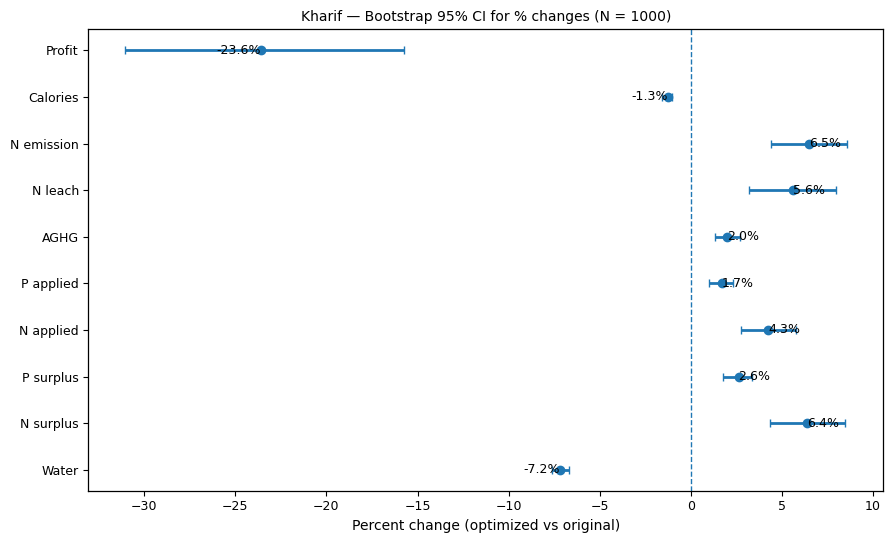

Saved: kharif_bootstrap_pct_reductions_ci.png


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Try in-memory; else load from disk
try:
    df = summ_pct_k.copy()
except NameError:
    OUT_DIR = r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\data"
    df = pd.read_csv(Path(OUT_DIR) / "kharif_bootstrap_pct_summary_total.csv")

# Order & nice labels
order = [
    '%_Water', '%_N_surplus', '%_P_surplus',
    '%_N_applied', '%_P_applied',
    '%_AGHG', '%_N_leach', '%_N_emission',
    '%_Calories', '%_Profit'
]
label_map = {
    '%_Water':'Water',
    '%_N_surplus':'N surplus',
    '%_P_surplus':'P surplus',
    '%_N_applied':'N applied',
    '%_P_applied':'P applied',
    '%_AGHG':'AGHG',
    '%_N_leach':'N leach',
    '%_N_emission':'N emission',
    '%_Calories':'Calories',
    '%_Profit':'Profit'
}

plot_df = df[df['metric'].isin(order)].copy()
plot_df['metric'] = pd.Categorical(plot_df['metric'], categories=order, ordered=True)
plot_df.sort_values('metric', inplace=True)

means = plot_df['mean'].values
xerr = [
    (means - plot_df['p2.5'].values),      # left error
    (plot_df['p97.5'].values - means)      # right error
]
y_labels = [label_map[m] for m in plot_df['metric']]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(means, y_labels, xerr=xerr, fmt='o', capsize=3)
ax.axvline(0, linestyle='--', linewidth=1)
ax.set_xlabel('Percent change (optimized vs original)')
ax.set_title('Kharif — Bootstrap 95% CI for % changes (N = 1000)')

# annotate means
for y, m in enumerate(means):
    ax.text(m, y, f"{m:.1f}%", va='center', ha='left' if m >= 0 else 'right')

plt.tight_layout()
plt.savefig('kharif_bootstrap_pct_reductions_ci.png', dpi=300)
plt.show()

print("Saved: kharif_bootstrap_pct_reductions_ci.png")


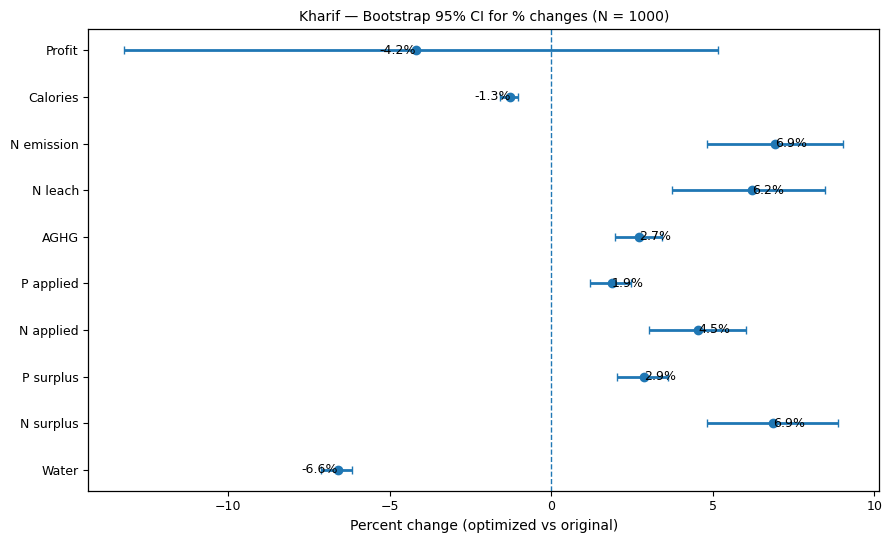

Saved: kharif_bootstrap_pct_reductions_ci.png


In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Try in-memory; else load from disk
try:
    df = summ_pct_k.copy()
except NameError:
    OUT_DIR = r"Y:\Home\goyal\collaboration\2024\paper_3_restructuring\reburtal\fig\data"
    df = pd.read_csv(Path(OUT_DIR) / "kharif_bootstrap_pct_summary_total.csv")

# Order & nice labels
order = [
    '%_Water', '%_N_surplus', '%_P_surplus',
    '%_N_applied', '%_P_applied',
    '%_AGHG', '%_N_leach', '%_N_emission',
    '%_Calories', '%_Profit'
]
label_map = {
    '%_Water':'Water',
    '%_N_surplus':'N surplus',
    '%_P_surplus':'P surplus',
    '%_N_applied':'N applied',
    '%_P_applied':'P applied',
    '%_AGHG':'AGHG',
    '%_N_leach':'N leach',
    '%_N_emission':'N emission',
    '%_Calories':'Calories',
    '%_Profit':'Profit'
}

plot_df = df[df['metric'].isin(order)].copy()
plot_df['metric'] = pd.Categorical(plot_df['metric'], categories=order, ordered=True)
plot_df.sort_values('metric', inplace=True)

means = plot_df['mean'].values
xerr = [
    (means - plot_df['p2.5'].values),      # left error
    (plot_df['p97.5'].values - means)      # right error
]
y_labels = [label_map[m] for m in plot_df['metric']]

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.errorbar(means, y_labels, xerr=xerr, fmt='o', capsize=3)
ax.axvline(0, linestyle='--', linewidth=1)
ax.set_xlabel('Percent change (optimized vs original)')
ax.set_title('Kharif — Bootstrap 95% CI for % changes (N = 1000)')

# annotate means
for y, m in enumerate(means):
    ax.text(m, y, f"{m:.1f}%", va='center', ha='left' if m >= 0 else 'right')

plt.tight_layout()
plt.savefig('kharif_bootstrap_pct_reductions_ci.png', dpi=300)
plt.show()

print("Saved: kharif_bootstrap_pct_reductions_ci.png")
